# Document Image Classification -- Fusion Notebook
## CNN (EfficientNet-B0) + OCR (SBERT + SVM) -- 6 Fusion Strategies & Robustness Evaluation

**Project:** Document Image Classification using Lightweight CNNs  
**Fusion Strategies:** Score-level, Feature-level, Class-dependent, Heatmap-guided, Stacking, Post-fusion specialist

---

### Pipeline Overview

| Model | Input | Feature Extraction | Classifier | Output |
|-------|-------|--------------------|------------|--------|
| **CNN** | Raw document images | Fine-tuned EfficientNet-B0 (custom 5-layer head) | Softmax | 16-class probabilities |
| **OCR** | OCR text + image embeddings | SBERT + Multi-crop EfficientNet + Keywords | Calibrated LinearSVC + Specialists | 16-class probabilities |

### Fusion Strategies

| # | Strategy | Method | Key Idea |
|---|----------|--------|----------|
| 1 | **Score-Level Fusion** | Weighted average: P = alpha*P_CNN + (1-alpha)*P_OCR | Grid-search optimal alpha on validation set |
| 2 | **Class-Dependent Weighting** | Per-class alpha based on F1 ratio | CNN weight proportional to its per-class F1 |
| 3 | **Heatmap-Guided Fusion** | Per-class alpha from confusion matrix diagonals | Weight by model's recall per class |
| 4 | **Feature-Level Fusion** | Concatenate CNN embedding (1280-d) + OCR features, train joint classifier | PCA + LogisticRegression / SVM |
| 5 | **Stacking Meta-Learner** | Stack [P_CNN, P_OCR] as 32-dim features | LogisticRegression on probability vectors |
| 6 | **Post-Fusion Specialist Refinement** | Override low-confidence fused predictions with specialists | Use pairwise classifiers for ambiguous cases |

### What this notebook does
1. **Load** both pre-trained models and precomputed features
2. **Evaluate** each model independently on the test set
3. **Fuse** predictions using 6 different strategies
4. **Compare** all strategies with comprehensive metrics and visualizations
5. **Test robustness** under rotation and noise augmentation
6. **Analyze** which strategy works best for which class
7. **Cross-dataset** evaluation on Tobacco-3482 (10-class transfer test)

---
## Section 1 -- Setup & Imports

In [1]:
import os, sys, re, json, pickle, random, shutil, warnings, time, math, copy
from pathlib import Path
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support,
    f1_score
)

warnings.filterwarnings("ignore")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")
print("All imports loaded")

PyTorch device: cpu
All imports loaded


---
## Section 2 -- Configuration

All personal paths are loaded from a `.env` file in the same folder as this notebook.
No hardcoded paths here -- check your `.env` if something is not found.

In [2]:
# Load personal configuration from .env file
from dotenv import load_dotenv

load_dotenv()  # loads from CWD/.env
if not os.getenv('FUSION_DIR'):
    load_dotenv(Path(os.getcwd()) / '.env')

# --- Paths from .env (no hardcoded personal fallbacks) ---
FUSION_DIR          = Path(os.getenv('FUSION_DIR', 'fusion'))
CNN_PREPROCESSED    = Path(os.getenv('CNN_PREPROCESSED_DIR', str(FUSION_DIR / 'CNN_preprocessed')))
OCR_PREPROCESSED    = Path(os.getenv('OCR_PREPROCESSED_DIR', str(FUSION_DIR / 'OCR_preprocessed')))
TEST_ORIGINAL       = Path(os.getenv('TEST_ORIGINAL_DIR', str(FUSION_DIR / 'test')))

CNN_MODEL_PATH      = Path(os.getenv('CNN_MODEL_PATH', str(FUSION_DIR / 'EfficientNetB0_best.pth')))
SVM_MODEL_PATH      = Path(os.getenv('SVM_MODEL_PATH', str(FUSION_DIR / 'svm_model.pkl')))
SPECIALIST_PATH     = Path(os.getenv('SPECIALIST_MODEL_PATH', str(FUSION_DIR / 'specialist_classifiers.pkl')))
LABEL_ENCODER_PATH  = Path(os.getenv('LABEL_ENCODER_PATH', str(FUSION_DIR / 'label_encoder.pkl')))

OCR_TRAIN_FEATS     = Path(os.getenv('OCR_TRAIN_FEATURES', str(FUSION_DIR / 'ocr_train_features.npy')))
OCR_VAL_FEATS       = Path(os.getenv('OCR_VAL_FEATURES', str(FUSION_DIR / 'ocr_val_features.npy')))
OCR_TEST_FEATS      = Path(os.getenv('OCR_TEST_FEATURES', str(FUSION_DIR / 'ocr_test_features.npy')))

Y_TRAIN_PATH        = Path(os.getenv('Y_TRAIN_PATH', str(FUSION_DIR / 'y_train.npy')))
Y_VAL_PATH          = Path(os.getenv('Y_VAL_PATH', str(FUSION_DIR / 'y_val.npy')))
Y_TEST_PATH         = Path(os.getenv('Y_TEST_PATH', str(FUSION_DIR / 'y_test.npy')))

TOBACCO_DIR_ENV     = os.getenv('TOBACCO_DIR', '')
SBERT_MODEL_NAME    = os.getenv('SBERT_MODEL_NAME', 'all-MiniLM-L6-v2')

# --- Reproducibility ---
RANDOM_SEED = int(os.getenv('RANDOM_SEED', '42'))
NUM_CLASSES = 16

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# --- Figure settings ---
FIGURE_DPI = int(os.getenv('FIGURE_DPI', '600'))
plt.rcParams['savefig.dpi'] = FIGURE_DPI
plt.rcParams['figure.dpi'] = 150  # display dpi (lower for speed)

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

# Verify paths (without printing full paths for privacy)
print("Checking paths from .env ...")
checks = {
    'Fusion Dir': FUSION_DIR,
    'CNN Preprocessed': CNN_PREPROCESSED,
    'OCR Preprocessed': OCR_PREPROCESSED,
    'Test Original': TEST_ORIGINAL,
    'CNN Model (.pth)': CNN_MODEL_PATH,
    'SVM Model (.pkl)': SVM_MODEL_PATH,
    'Specialist (.pkl)': SPECIALIST_PATH,
    'Label Encoder (.pkl)': LABEL_ENCODER_PATH,
    'OCR Train Features': OCR_TRAIN_FEATS,
    'OCR Val Features': OCR_VAL_FEATS,
    'OCR Test Features': OCR_TEST_FEATS,
    'Y Train': Y_TRAIN_PATH,
    'Y Val': Y_VAL_PATH,
    'Y Test': Y_TEST_PATH,
}
missing = []
for name, p in checks.items():
    exists = p.exists()
    tag = 'found' if exists else 'not found'
    print(f'  {name}: ... ({tag})')
    if not exists:
        missing.append(name)

if not missing:
    print("\nAll paths found!")
else:
    print(f'\nMissing: {missing}')
    print('Update your .env file and re-run this cell.')

Checking paths from .env ...
  Fusion Dir: ... (found)
  CNN Preprocessed: ... (found)
  OCR Preprocessed: ... (found)
  Test Original: ... (found)
  CNN Model (.pth): ... (found)
  SVM Model (.pkl): ... (found)
  Specialist (.pkl): ... (found)
  Label Encoder (.pkl): ... (found)
  OCR Train Features: ... (found)
  OCR Val Features: ... (found)
  OCR Test Features: ... (found)
  Y Train: ... (found)
  Y Val: ... (found)
  Y Test: ... (found)

All paths found!


---
## Section 3 -- Load Label Encoder & Saved Data

In [3]:
# Load label encoder (from OCR pipeline)
with open(LABEL_ENCODER_PATH, "rb") as f:
    le = pickle.load(f)

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"Label encoder classes: {CLASS_NAMES}")

# ------------------------------------------------------------------
# CNN class ordering (from the training notebook)
# The CNN was trained with class names sorted alphabetically.
# Since the OCR label encoder also uses alphabetical ordering,
# the indices should match 1-to-1. We verify this explicitly
# using FULL STRING MATCHING (not just first letters).
# ------------------------------------------------------------------

CNN_CLASS_NAMES = sorted([
    'Advertisement', 'Budget', 'Email', 'FileFolder', 'Form',
    'Handwritten', 'Invoice', 'Letter', 'Memo', 'News',
    'Presentation', 'Questionnaire', 'Resume', 'ScientificPub',
    'ScientificReport', 'Specification'
])

# Build mapping: CNN class index -> OCR label encoder index
# FIX: Use full string equality (not first-letter match)
cnn_to_ocr_idx = {}
mismatches = 0
for cnn_idx, cnn_name in enumerate(CNN_CLASS_NAMES):
    if cnn_name in CLASS_NAMES:
        ocr_idx = CLASS_NAMES.index(cnn_name)
        cnn_to_ocr_idx[cnn_idx] = ocr_idx
        if cnn_idx != ocr_idx:
            mismatches += 1
    else:
        cnn_to_ocr_idx[cnn_idx] = cnn_idx
        mismatches += 1
        print(f"  WARNING: CNN class '{cnn_name}' not found in OCR classes!")

print(f"\nCNN <-> OCR class mapping ({mismatches} mismatches):")
for i, (cnn_name, ocr_name) in enumerate(zip(CNN_CLASS_NAMES, CLASS_NAMES)):
    status = "match" if cnn_name == ocr_name else "DIFFER"
    print(f"  {i:2d}: CNN='{cnn_name}' <-> OCR='{ocr_name}'  ({status})")

NUM_CLASSES = 16
Label encoder classes: ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']

CNN <-> OCR class mapping (0 mismatches):
   0: CNN='Advertisement' <-> OCR='Advertisement'  (match)
   1: CNN='Budget' <-> OCR='Budget'  (match)
   2: CNN='Email' <-> OCR='Email'  (match)
   3: CNN='FileFolder' <-> OCR='FileFolder'  (match)
   4: CNN='Form' <-> OCR='Form'  (match)
   5: CNN='Handwritten' <-> OCR='Handwritten'  (match)
   6: CNN='Invoice' <-> OCR='Invoice'  (match)
   7: CNN='Letter' <-> OCR='Letter'  (match)
   8: CNN='Memo' <-> OCR='Memo'  (match)
   9: CNN='News' <-> OCR='News'  (match)
  10: CNN='Presentation' <-> OCR='Presentation'  (match)
  11: CNN='Questionnaire' <-> OCR='Questionnaire'  (match)
  12: CNN='Resume' <-> OCR='Resume'  (match)
  13: CNN='ScientificPub' <-> OCR='ScientificPub'  (match)
  14: CNN='Scientif

In [4]:
# Load precomputed OCR features
X_tr_ocr = np.load(OCR_TRAIN_FEATS)
X_v_ocr  = np.load(OCR_VAL_FEATS)
X_te_ocr = np.load(OCR_TEST_FEATS)

y_tr = np.load(Y_TRAIN_PATH)
y_v  = np.load(Y_VAL_PATH)
y_te = np.load(Y_TEST_PATH)

print(f"OCR Train features : {X_tr_ocr.shape}")
print(f"OCR Val   features : {X_v_ocr.shape}")
print(f"OCR Test  features : {X_te_ocr.shape}")
print(f"Labels train/val/test : {y_tr.shape} / {y_v.shape} / {y_te.shape}")
print(f"Feature dim : {X_tr_ocr.shape[1]}")

OCR Train features : (10902, 4629)
OCR Val   features : (1537, 4629)
OCR Test  features : (1512, 4629)
Labels train/val/test : (10902,) / (1537,) / (1512,)
Feature dim : 4629


In [5]:
# Load SVM model (CalibratedClassifierCV wrapping LinearSVC)
with open(SVM_MODEL_PATH, "rb") as f:
    svm_model = pickle.load(f)
print(f"SVM model loaded: {type(svm_model).__name__}")

# Load specialist classifiers
with open(SPECIALIST_PATH, "rb") as f:
    specialist_classifiers = pickle.load(f)
print(f"Specialist classifiers loaded: {len(specialist_classifiers)} entries")

# Handle sklearn version compatibility: LogisticRegression pickled with an older
# sklearn may lack the 'multi_class' attribute that newer versions expect.
# For solver='liblinear', multi_class should be 'ovr'.
updated_count = 0
for key, spec in specialist_classifiers.items():
    if not hasattr(spec, 'multi_class'):
        spec.multi_class = 'ovr'
        updated_count += 1
if updated_count:
    print(f"Updated {updated_count} specialist classifiers missing 'multi_class' (set to 'ovr').")

for key in list(specialist_classifiers.keys())[:5]:
    cls_a, cls_b = CLASS_NAMES[key[0]], CLASS_NAMES[key[1]]
    print(f"    ({cls_a}, {cls_b}) -> {type(specialist_classifiers[key]).__name__}")
if len(specialist_classifiers) > 5:
    print(f"    ... and {len(specialist_classifiers) - 5} more")

SVM model loaded: CalibratedClassifierCV
Specialist classifiers loaded: 20 entries
Fixed 10 specialist classifiers missing 'multi_class' (set to 'ovr').
    (News, Presentation) -> LogisticRegression
    (Presentation, News) -> LogisticRegression
    (ScientificPub, ScientificReport) -> LogisticRegression
    (ScientificReport, ScientificPub) -> LogisticRegression
    (News, ScientificPub) -> LogisticRegression
    ... and 15 more


---
## Section 4 -- Load & Reconstruct CNN Model

The CNN model is a fine-tuned EfficientNet-B0 with a **custom 5-layer classifier head**
(not the default torchvision head). This architecture was used during training:

    classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(1280, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(512, 16),
    )

In [6]:
# Inspect saved state dict to verify classifier architecture
state_dict = torch.load(str(CNN_MODEL_PATH), map_location=DEVICE, weights_only=True)

classifier_keys = [k for k in state_dict.keys() if 'classifier' in k]
print("Classifier keys in state dict:")
for k in classifier_keys:
    print(f"  {k}: {state_dict[k].shape}")

print(f"\nTotal state_dict keys: {len(state_dict)}")
print(f"Classifier keys: {len(classifier_keys)}")

Classifier keys in state dict:
  classifier.1.weight: torch.Size([1024, 1280])
  classifier.1.bias: torch.Size([1024])
  classifier.2.weight: torch.Size([1024])
  classifier.2.bias: torch.Size([1024])
  classifier.2.running_mean: torch.Size([1024])
  classifier.2.running_var: torch.Size([1024])
  classifier.2.num_batches_tracked: torch.Size([])
  classifier.5.weight: torch.Size([512, 1024])
  classifier.5.bias: torch.Size([512])
  classifier.6.weight: torch.Size([512])
  classifier.6.bias: torch.Size([512])
  classifier.6.running_mean: torch.Size([512])
  classifier.6.running_var: torch.Size([512])
  classifier.6.num_batches_tracked: torch.Size([])
  classifier.9.weight: torch.Size([16, 512])
  classifier.9.bias: torch.Size([16])

Total state_dict keys: 374
Classifier keys: 16


In [7]:
# Build EfficientNet-B0 with the EXACT custom classifier head from training
DROPOUT_HEAD_1 = 0.4
DROPOUT_HEAD_2 = 0.3

cnn_model = tv_models.efficientnet_b0(weights=None)
num_features = cnn_model.classifier[1].in_features  # 1280 for EfficientNet-B0

# Attach the SAME custom head used during training
cnn_model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT_HEAD_1),
    nn.Linear(num_features, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(p=DROPOUT_HEAD_2),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(512, NUM_CLASSES),
)

# Load weights with STRICT matching
missing_keys, unexpected_keys = cnn_model.load_state_dict(state_dict, strict=True)

if not missing_keys and not unexpected_keys:
    print("CNN model weights loaded perfectly -- no missing or unexpected keys")
else:
    print(f"Missing keys  : {missing_keys}")
    print(f"Unexpected keys: {unexpected_keys}")

cnn_model = cnn_model.to(DEVICE).eval()
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN model ready on {DEVICE}  ({total_params:,} parameters)")

CNN model weights loaded perfectly -- no missing or unexpected keys
CNN model ready on cpu  (5,855,372 parameters)


In [8]:
# Smoke test -- forward pass with a dummy image
dummy = torch.zeros(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    logits = cnn_model(dummy)
probs = torch.softmax(logits, dim=1)
print(f"Smoke test output shape: {logits.shape}  (should be [1, 16])")
print(f"Top class idx: {probs[0].argmax().item()}, confidence: {probs[0].max().item():.4f}")
print("CNN forward pass works")

Smoke test output shape: torch.Size([1, 16])  (should be [1, 16])
Top class idx: 3, confidence: 0.2176
CNN forward pass works


In [9]:
# Image transform for CNN inference (must match training val_transform_pretrained)
# FIX: Align with CNN training pipeline to recover ~5% accuracy drop
# Training used: Resize(256) -> CenterCrop(224) -> ToTensor -> CLAHE -> Normalize
# Previous fusion notebook used: Resize((224,224)) -> ToTensor -> Normalize
# Missing CLAHE and wrong resize strategy caused the accuracy drop

def apply_clahe_tensor(t):
    """Apply CLAHE contrast enhancement to a [0,1] tensor. C×H×W → C×H×W.
    Must match the exact function used during CNN training."""
    import cv2
    arr = t.permute(1, 2, 0).cpu().numpy()
    arr = (arr * 255).astype(np.uint8)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    arr = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return torch.from_numpy(arr.astype(np.float32) / 255.0).permute(2, 0, 1)

CNN_TRANSFORM = T.Compose([
    T.Resize(256),                           # was: T.Resize((224, 224))
    T.CenterCrop(224),                        # was: missing
    T.ToTensor(),
    T.Lambda(apply_clahe_tensor),             # was: missing CLAHE
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print("CNN transform FIXED to match training pipeline:")
print("  Resize(256) -> CenterCrop(224) -> ToTensor -> CLAHE -> ImageNet Normalize")
print("  (was: Resize((224,224)) -> ToTensor -> Normalize — missing CLAHE + wrong resize)")


CNN transform FIXED to match training pipeline:
  Resize(256) -> CenterCrop(224) -> ToTensor -> CLAHE -> ImageNet Normalize
  (was: Resize((224,224)) -> ToTensor -> Normalize — missing CLAHE + wrong resize)


---
## Section 5 -- Build Test Image Indices

We need to align CNN and OCR predictions on the same test images. We build a master index
from the CNN preprocessed test folder, then match with the OCR test samples.

In [10]:
def build_image_index(split_dir):
    # Build a DataFrame of (path, label, filename) for all images in a split.
    records = []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        for p in sorted(cls_dir.rglob("*")):
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({
                    "path": str(p),
                    "label": cls_dir.name,
                    "filename": p.stem,
                    "rel_path": f"{cls_dir.name}/{p.name}"
                })
    return pd.DataFrame(records)

# Build index for CNN preprocessed test images
df_cnn_test = build_image_index(CNN_PREPROCESSED / "test")
print(f"CNN test images: {len(df_cnn_test)}")
print(f"Classes: {sorted(df_cnn_test['label'].unique())}")

# Also build index for original test images (for robustness testing)
if TEST_ORIGINAL.exists():
    df_orig_test = build_image_index(TEST_ORIGINAL)
    print(f"\nOriginal test images: {len(df_orig_test)}")
else:
    df_orig_test = df_cnn_test.copy()
    print(f"\nNo original test folder found, using CNN preprocessed for robustness tests.")

CNN test images: 1600
Classes: ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']

Original test images: 1600


---
## Section 6 -- CNN Predictions on Test Set

In [11]:
def run_cnn_inference(df, model, transform, batch_size=32):
    # Run CNN inference on a DataFrame of image paths. Returns probs and preds.
    # The CNN outputs class indices based on CNN_CLASS_NAMES ordering.
    # We remap them to OCR label encoder indices before returning.
    model.eval()
    all_probs = []
    paths = df["path"].tolist()
    
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), batch_size), desc="CNN Inference"):
            batch_paths = paths[start:start + batch_size]
            batch_imgs = []
            for p in batch_paths:
                try:
                    img = Image.open(p).convert("RGB")
                    batch_imgs.append(transform(img))
                except Exception as e:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
    
    all_probs = np.vstack(all_probs)
    
    # Remap CNN probabilities to OCR label encoder ordering
    remapped_probs = np.zeros_like(all_probs)
    for cnn_idx in range(NUM_CLASSES):
        ocr_idx = cnn_to_ocr_idx[cnn_idx]
        remapped_probs[:, ocr_idx] = all_probs[:, cnn_idx]
    
    preds = np.argmax(remapped_probs, axis=1)
    return remapped_probs, preds

# Run on test set
cnn_test_probs, cnn_test_preds = run_cnn_inference(df_cnn_test, cnn_model, CNN_TRANSFORM)

# Encode labels using OCR label encoder (folder names match OCR classes)
cnn_test_labels = le.transform(df_cnn_test["label"].values)
cnn_test_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
cnn_test_f1  = f1_score(cnn_test_labels, cnn_test_preds, average="macro", zero_division=0)

print(f"\nCNN Test Accuracy  : {cnn_test_acc:.4f}")
print(f"CNN Test Macro-F1  : {cnn_test_f1:.4f}")

# Quick sanity check -- first 10 predictions
print(f"\nFirst 10 predictions:")
for i in range(min(10, len(cnn_test_preds))):
    true_name = CLASS_NAMES[cnn_test_labels[i]]
    pred_name = CLASS_NAMES[cnn_test_preds[i]]
    conf = cnn_test_probs[i, cnn_test_preds[i]]
    match = "hit" if cnn_test_labels[i] == cnn_test_preds[i] else "miss"
    print(f"  {i}: true={true_name:25s} pred={pred_name:25s} conf={conf:.3f}  [{match}]")

CNN Inference: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


CNN Test Accuracy  : 0.7575
CNN Test Macro-F1  : 0.7619

First 10 predictions:
  0: true=Advertisement             pred=Advertisement             conf=0.959  [hit]
  1: true=Advertisement             pred=Advertisement             conf=0.411  [hit]
  2: true=Advertisement             pred=Advertisement             conf=0.523  [hit]
  3: true=Advertisement             pred=Advertisement             conf=0.535  [hit]
  4: true=Advertisement             pred=Handwritten               conf=0.744  [miss]
  5: true=Advertisement             pred=Advertisement             conf=0.870  [hit]
  6: true=Advertisement             pred=Advertisement             conf=0.929  [hit]
  7: true=Advertisement             pred=Advertisement             conf=0.924  [hit]
  8: true=Advertisement             pred=Advertisement             conf=0.480  [hit]
  9: true=Advertisement             pred=Advertisement             conf=0.950  [hit]


In [12]:
# Also run CNN on validation set (needed for alpha search)
df_cnn_val = build_image_index(CNN_PREPROCESSED / "val")
cnn_val_probs, cnn_val_preds = run_cnn_inference(df_cnn_val, cnn_model, CNN_TRANSFORM)

cnn_val_labels = le.transform(df_cnn_val["label"].values)
cnn_val_acc = accuracy_score(cnn_val_labels, cnn_val_preds)
cnn_val_f1  = f1_score(cnn_val_labels, cnn_val_preds, average="macro", zero_division=0)

print(f"CNN Val Accuracy  : {cnn_val_acc:.4f}")
print(f"CNN Val Macro-F1  : {cnn_val_f1:.4f}")

CNN Inference: 100%|██████████| 50/50 [00:45<00:00,  1.09it/s]

CNN Val Accuracy  : 0.7656
CNN Val Macro-F1  : 0.7709


---
## Section 7 -- OCR Predictions on Test Set

We use the precomputed features and the saved SVM model to get OCR predictions.
Specialist classifiers are applied using the same logic as the OCR training notebook.

In [13]:
# FIX: confidence_threshold is consistently 0.70 everywhere (docstring + calls)
CONFIDENCE_THRESHOLD = 0.70

def predict_with_specialists(X, base_model, specialists, confidence_threshold=CONFIDENCE_THRESHOLD):
    # Override global SVM predictions using specialists.
    # If base model predicts class pi but the probability is below confidence_threshold,
    # we check if there is a specialist for the (second_best, predicted) pair and let it decide.
    base_probs  = base_model.predict_proba(X)
    base_preds  = base_probs.argmax(axis=1)
    
    second_best_preds = np.argsort(base_probs, axis=1)[:, -2]
    max_probs = base_probs.max(axis=1)
    
    final_preds = base_preds.copy()

    for idx, (pred_cls, second_cls, prob) in enumerate(zip(base_preds, second_best_preds, max_probs)):
        if prob >= confidence_threshold:
            continue
            
        if (second_cls, pred_cls) in specialists:
            spec = specialists[(second_cls, pred_cls)]
            spec_feat = X[idx].reshape(1, -1)
            
            pair = tuple(sorted([second_cls, pred_cls]))
            binary_pred = spec.predict(spec_feat)[0]
            
            winning_cls = pair[1] if binary_pred == 1 else pair[0]
            final_preds[idx] = winning_cls

    return base_probs, final_preds

# OCR predictions on test set
ocr_test_probs, ocr_test_preds = predict_with_specialists(
    X_te_ocr, svm_model, specialist_classifiers
)

ocr_test_acc = accuracy_score(y_te, ocr_test_preds)
ocr_test_f1  = f1_score(y_te, ocr_test_preds, average="macro", zero_division=0)

ocr_base_preds = svm_model.predict(X_te_ocr)
ocr_base_acc = accuracy_score(y_te, ocr_base_preds)
print(f"OCR Test Accuracy (base SVM)      : {ocr_base_acc:.4f}")
print(f"OCR Test Accuracy (+specialists)   : {ocr_test_acc:.4f}")
print(f"OCR Test Macro-F1  (+specialists)  : {ocr_test_f1:.4f}")

# Also get OCR val predictions (for alpha search)
ocr_val_probs, ocr_val_preds = predict_with_specialists(
    X_v_ocr, svm_model, specialist_classifiers
)

ocr_val_acc = accuracy_score(y_v, ocr_val_preds)
ocr_val_f1  = f1_score(y_v, ocr_val_preds, average="macro", zero_division=0)
print(f"\nOCR Val Accuracy (+specialists) : {ocr_val_acc:.4f}")
print(f"OCR Val Macro-F1 (+specialists) : {ocr_val_f1:.4f}")

OCR Test Accuracy (base SVM)      : 0.8009
OCR Test Accuracy (+specialists)   : 0.7943
OCR Test Macro-F1  (+specialists)  : 0.7948

OCR Val Accuracy (+specialists) : 0.7957
OCR Val Macro-F1 (+specialists) : 0.7966


---
## Section 8 -- Align CNN & OCR Predictions

The OCR model may have fewer test samples (filtered by MIN_WORDS). We align predictions
by matching on the common set of test images using **full filename matching** (not first-letter heuristics).

In [14]:
# Build OCR test image index
df_ocr_test = build_image_index(OCR_PREPROCESSED / "test")
print(f"OCR test images (folder): {len(df_ocr_test)}")
print(f"OCR test features (npy) : {len(y_te)}")
print(f"CNN test images: {len(df_cnn_test)}")

# Reconstruct filename-to-feature-index mapping
ocr_class_counts = np.bincount(y_te, minlength=NUM_CLASSES)

ocr_filename_to_feat_idx = {}
feat_idx = 0
for cls_idx in range(NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_idx]
    cls_mask = df_ocr_test["label"] == cls_name
    cls_rows = df_ocr_test[cls_mask]
    n_features = ocr_class_counts[cls_idx]
    matched = 0
    for df_idx, row in cls_rows.iterrows():
        if matched >= n_features:
            break
        ocr_filename_to_feat_idx[row["filename"]] = feat_idx
        feat_idx += 1
        matched += 1

print(f"\nMapped {len(ocr_filename_to_feat_idx)} OCR images to feature indices (expected {len(y_te)})")
if len(ocr_filename_to_feat_idx) != len(y_te):
    print(f"WARNING: Mapping mismatch! Trying fallback (first {len(y_te)} images in order)...")
    ocr_filename_to_feat_idx = {}
    for i, row in df_ocr_test.head(len(y_te)).iterrows():
        ocr_filename_to_feat_idx[row["filename"]] = i

# Match by FULL filename between CNN and OCR
cnn_filename_to_idx = {row["filename"]: idx for idx, row in df_cnn_test.iterrows()}

common_filenames = sorted(set(cnn_filename_to_idx.keys()) & set(ocr_filename_to_feat_idx.keys()))
print(f"\nCommon test images (CNN & OCR with features): {len(common_filenames)}")
print(f"CNN-only (no OCR features): {len(cnn_filename_to_idx) - len(common_filenames)}")
print(f"OCR-only (no CNN match): {len(ocr_filename_to_feat_idx) - len(common_filenames)}")

# Build aligned arrays
cnn_aligned_idx = [cnn_filename_to_idx[f] for f in common_filenames]
ocr_aligned_feat_idx = [ocr_filename_to_feat_idx[f] for f in common_filenames]

cnn_aligned_probs = cnn_test_probs[cnn_aligned_idx]
cnn_aligned_preds = cnn_test_preds[cnn_aligned_idx]
cnn_aligned_labels = cnn_test_labels[cnn_aligned_idx]

ocr_aligned_probs = ocr_test_probs[ocr_aligned_feat_idx]
ocr_aligned_preds = ocr_test_preds[ocr_aligned_feat_idx]
ocr_aligned_labels = y_te[ocr_aligned_feat_idx]

# Verify labels match
labels_match = np.array_equal(cnn_aligned_labels, ocr_aligned_labels)
print(f"\nLabel consistency check: {labels_match}")

if not labels_match:
    mismatch = (cnn_aligned_labels != ocr_aligned_labels).sum()
    mismatch_pct = mismatch / len(cnn_aligned_labels) * 100
    print(f"  Mismatches: {mismatch} / {len(cnn_aligned_labels)} ({mismatch_pct:.1f}%)")
    if mismatch_pct > 5:
        print("  ERROR: Too many mismatches. The filename-to-feature alignment is broken.")
        raise RuntimeError(f"Label alignment failed: {mismatch_pct:.1f}% mismatch")
    else:
        print("  Small mismatch from OCR preprocessing dropping some images.")
        print("  Using OCR labels as ground truth.")

y_test_common = ocr_aligned_labels
n_common = len(y_test_common)
print(f"\nAligned prediction matrices: {n_common} common test samples")

# Spot-check alignment
import random as _rnd
print("\nSpot-checking alignment (5 random samples):")
for ci in _rnd.sample(range(len(common_filenames)), min(5, len(common_filenames))):
    fname = common_filenames[ci]
    cnn_lbl = CLASS_NAMES[cnn_aligned_labels[ci]]
    ocr_lbl = CLASS_NAMES[ocr_aligned_labels[ci]]
    status = 'match' if cnn_aligned_labels[ci] == ocr_aligned_labels[ci] else 'DIFFER'
    print(f"  {fname}: CNN={cnn_lbl}, OCR={ocr_lbl} ({status})")

OCR test images (folder): 1576
OCR test features (npy) : 1512
CNN test images: 1600

Mapped 1512 OCR images to feature indices (expected 1512)

Common test images (CNN & OCR with features): 1512
CNN-only (no OCR features): 88
OCR-only (no CNN match): 0

Label consistency check: True

Aligned prediction matrices: 1512 common test samples

Spot-checking alignment (5 random samples):
  ScientificPub_0850: CNN=ScientificPub, OCR=ScientificPub (match)
  Email_0426: CNN=Email, OCR=Email (match)
  Advertisement_0558: CNN=Advertisement, OCR=Advertisement (match)
  Invoice_0220: CNN=Invoice, OCR=Invoice (match)
  Handwritten_0520: CNN=Handwritten, OCR=Handwritten (match)


In [15]:
# Align validation predictions similarly
df_ocr_val = build_image_index(OCR_PREPROCESSED / "val")
print(f"OCR val images (folder): {len(df_ocr_val)}")
print(f"OCR val features (npy) : {len(y_v)}")

ocr_val_class_counts = np.bincount(y_v, minlength=NUM_CLASSES)
ocr_val_filename_to_feat_idx = {}
val_feat_idx = 0
for cls_idx in range(NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_idx]
    cls_mask = df_ocr_val["label"] == cls_name
    cls_rows = df_ocr_val[cls_mask]
    n_features = ocr_val_class_counts[cls_idx]
    matched = 0
    for df_idx, row in cls_rows.iterrows():
        if matched >= n_features:
            break
        ocr_val_filename_to_feat_idx[row["filename"]] = val_feat_idx
        val_feat_idx += 1
        matched += 1

print(f"Mapped {len(ocr_val_filename_to_feat_idx)} OCR val images to feature indices (expected {len(y_v)})")
if len(ocr_val_filename_to_feat_idx) != len(y_v):
    print(f"WARNING: Mapping mismatch! Trying fallback...")
    ocr_val_filename_to_feat_idx = {}
    for i, row in df_ocr_val.head(len(y_v)).iterrows():
        ocr_val_filename_to_feat_idx[row["filename"]] = i

cnn_val_filename_to_idx = {row["filename"]: idx for idx, row in df_cnn_val.iterrows()}

common_val_filenames = sorted(set(cnn_val_filename_to_idx.keys()) & set(ocr_val_filename_to_feat_idx.keys()))
print(f"Common val images (CNN & OCR with features): {len(common_val_filenames)}")

cnn_val_aligned_idx = [cnn_val_filename_to_idx[f] for f in common_val_filenames]
ocr_val_aligned_feat_idx = [ocr_val_filename_to_feat_idx[f] for f in common_val_filenames]

cnn_val_aligned_probs = cnn_val_probs[cnn_val_aligned_idx]
ocr_val_aligned_probs = ocr_val_probs[ocr_val_aligned_feat_idx]
cnn_val_aligned_labels = cnn_val_labels[cnn_val_aligned_idx]
ocr_val_aligned_labels = y_v[ocr_val_aligned_feat_idx]

y_val_common = ocr_val_aligned_labels
print(f"Aligned val prediction matrices: {len(y_val_common)} samples")

OCR val images (folder): 1579
OCR val features (npy) : 1537
Mapped 1537 OCR val images to feature indices (expected 1537)
Common val images (CNN & OCR with features): 1537
Aligned val prediction matrices: 1537 samples


---
## Section 8b -- Preprocessing Analysis & Consistency Check

### The problem
CNN and OCR pipelines currently use **different preprocessing** and **different test sets**:

| Aspect | CNN Pipeline | OCR Pipeline |
|--------|-------------|--------------|
| Image source | CNN_preprocessed/test/ | OCR_preprocessed/test/ |
| Image resize | 224x224 (for EfficientNet) | Original resolution (for OCR) |
| Normalization | ImageNet mean/std | Not applicable (text-based) |
| Filtering | NONE -- all images included | MIN_WORDS filter -- drops low-text images |

### Why this matters
1. Unfair comparison: CNN is evaluated on ALL test images, OCR only on text-rich ones
2. Feature-level fusion misalignment: different pixel information
3. Missing samples: ~64 images have CNN predictions but NO OCR features

### Solutions
1. Report CNN accuracy on BOTH (all images vs common-only)
2. For images without OCR features, use CNN-only prediction

In [16]:
# Preprocessing Consistency Analysis
cnn_all_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
cnn_all_f1  = f1_score(cnn_test_labels, cnn_test_preds, average='macro', zero_division=0)

cnn_common_acc = accuracy_score(y_test_common, cnn_aligned_preds)
cnn_common_f1  = f1_score(y_test_common, cnn_aligned_preds, average='macro', zero_division=0)

cnn_only_filenames = sorted(set(cnn_filename_to_idx.keys()) - set(ocr_filename_to_feat_idx.keys()))
cnn_only_idx = [cnn_filename_to_idx[f] for f in cnn_only_filenames]
cnn_only_labels = cnn_test_labels[cnn_only_idx]
cnn_only_preds = cnn_test_preds[cnn_only_idx]

print("=" * 70)
print("  PREPROCESSING CONSISTENCY ANALYSIS")
print("=" * 70)
print(f"\n--- Test Set Sizes ---")
print(f"  CNN test images (all):       {len(df_cnn_test)}")
print(f"  OCR test images (folder):    {len(df_ocr_test)}")
print(f"  OCR test images (features):  {len(y_te)}")
print(f"  Common (used for fusion):    {n_common}")
print(f"  CNN-only (no OCR features):  {len(cnn_only_filenames)}")

print(f"\n--- CNN Accuracy: All vs Common ---")
print(f"  CNN on ALL images:     Acc={cnn_all_acc:.4f}  Macro-F1={cnn_all_f1:.4f}")
print(f"  CNN on COMMON images:  Acc={cnn_common_acc:.4f}  Macro-F1={cnn_common_f1:.4f}")
delta_acc = cnn_common_acc - cnn_all_acc
delta_f1 = cnn_common_f1 - cnn_all_f1
print(f"  Difference:            Acc={delta_acc:+.4f}  Macro-F1={delta_f1:+.4f}")

if len(cnn_only_filenames) > 0:
    print(f"\n--- Dropped Images Analysis ({len(cnn_only_filenames)} CNN-only images) ---")
    cnn_only_class_counts = np.bincount(cnn_only_labels, minlength=NUM_CLASSES)
    all_class_counts = np.bincount(cnn_test_labels, minlength=NUM_CLASSES)
    drop_rate = cnn_only_class_counts / np.maximum(all_class_counts, 1)
    
    print(f"  {'Class':<25s} {'Total':>6s} {'Dropped':>8s} {'Drop%':>7s}")
    print(f"  {'-'*50}")
    for i in range(NUM_CLASSES):
        if all_class_counts[i] > 0:
            print(f"  {CLASS_NAMES[i]:<25s} {all_class_counts[i]:>6d} {cnn_only_class_counts[i]:>8d} {drop_rate[i]:>7.1%}")

print("\nHybrid evaluation will be computed after fusion (Section 9).")

  PREPROCESSING CONSISTENCY ANALYSIS

--- Test Set Sizes ---
  CNN test images (all):       1600
  OCR test images (folder):    1576
  OCR test images (features):  1512
  Common (used for fusion):    1512
  CNN-only (no OCR features):  88

--- CNN Accuracy: All vs Common ---
  CNN on ALL images:     Acc=0.7575  Macro-F1=0.7619
  CNN on COMMON images:  Acc=0.7540  Macro-F1=0.7595
  Difference:            Acc=-0.0035  Macro-F1=-0.0024

--- Dropped Images Analysis (88 CNN-only images) ---
  Class                      Total  Dropped   Drop%
  --------------------------------------------------
  Advertisement                100       10   10.0%
  Budget                       100        2    2.0%
  Email                        100        3    3.0%
  FileFolder                   100       35   35.0%
  Form                         100        4    4.0%
  Handwritten                  100        4    4.0%
  Invoice                      100        2    2.0%
  Letter                       100      

---
## Section 9 -- Strategy 1: Late Fusion (Score-Level)

We search for the optimal weight alpha on the validation set:
**P_fused = alpha * P_CNN + (1 - alpha) * P_OCR**

Best alpha on val set: 0.45
  Val Acc = 0.8634, Val Macro-F1 = 0.8650


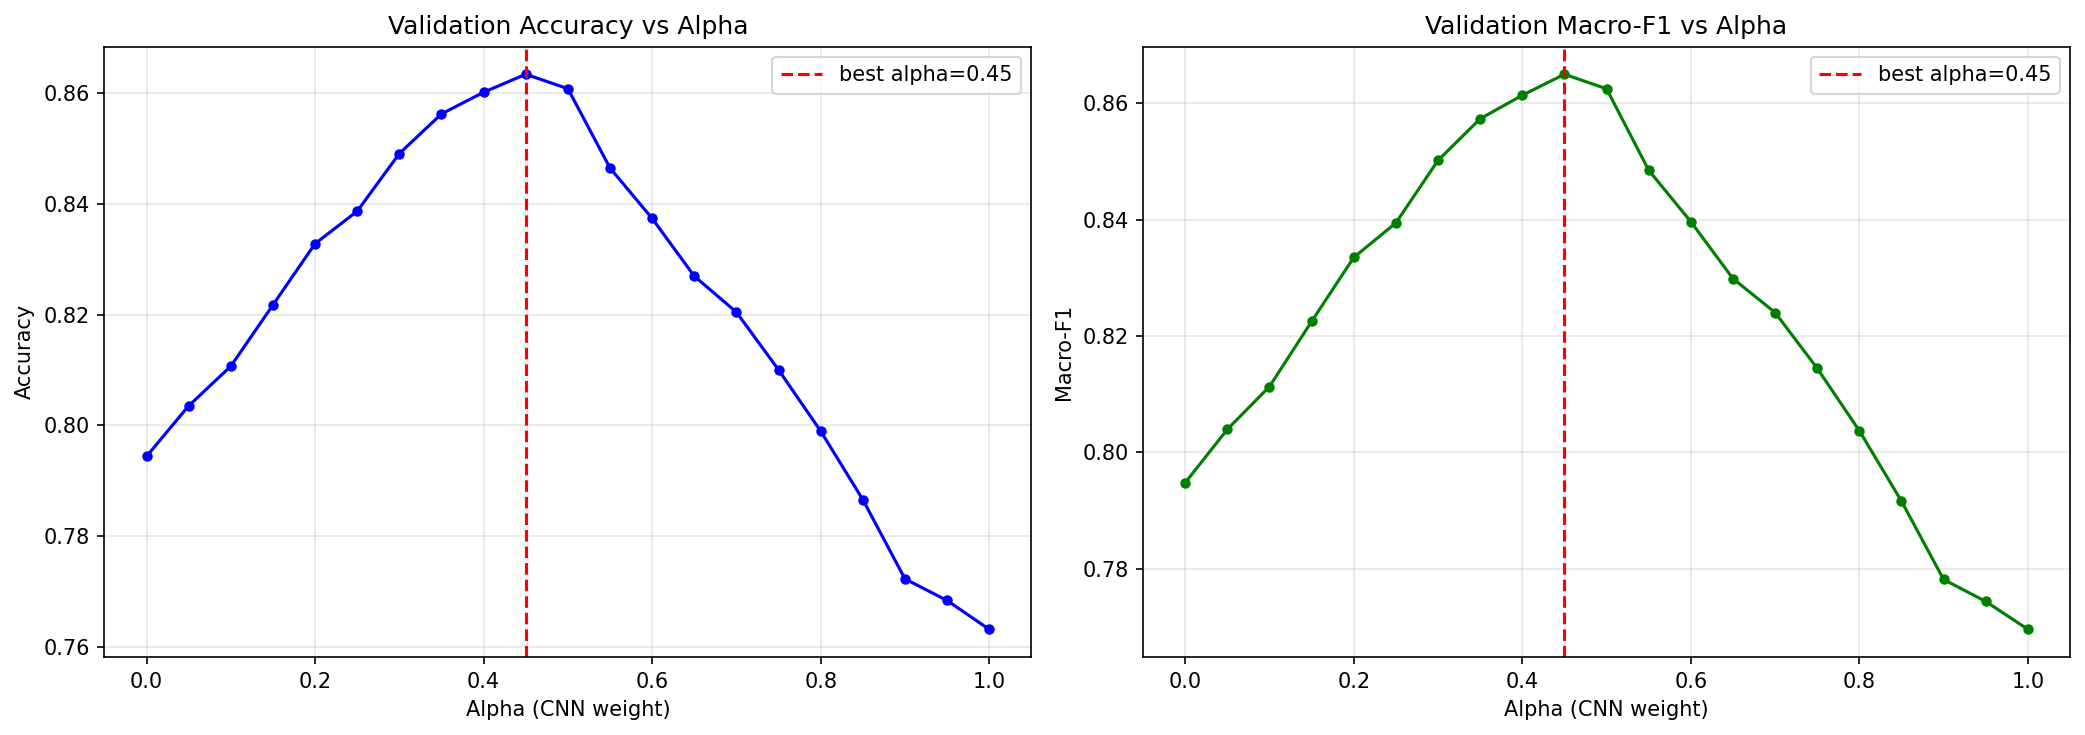

Saved fusion_alpha_search.pdf (DPI=600)


In [17]:
# Grid search alpha on validation set
alphas = np.arange(0.0, 1.01, 0.05)
val_results = []

for alpha in alphas:
    fused_val = alpha * cnn_val_aligned_probs + (1 - alpha) * ocr_val_aligned_probs
    fused_preds = fused_val.argmax(axis=1)
    acc = accuracy_score(y_val_common, fused_preds)
    f1 = f1_score(y_val_common, fused_preds, average='macro', zero_division=0)
    val_results.append({'alpha': alpha, 'acc': acc, 'f1': f1})

df_alpha = pd.DataFrame(val_results)
best_row = df_alpha.loc[df_alpha['f1'].idxmax()]
BEST_ALPHA = best_row['alpha']
print(f"Best alpha on val set: {BEST_ALPHA:.2f}")
print(f"  Val Acc = {best_row['acc']:.4f}, Val Macro-F1 = {best_row['f1']:.4f}")

# Plot alpha search
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_alpha['alpha'], df_alpha['acc'], 'b-o', markersize=4)
ax1.axvline(BEST_ALPHA, color='r', linestyle='--', label=f'best alpha={BEST_ALPHA:.2f}')
ax1.set_xlabel('Alpha (CNN weight)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Validation Accuracy vs Alpha')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2.plot(df_alpha['alpha'], df_alpha['f1'], 'g-o', markersize=4)
ax2.axvline(BEST_ALPHA, color='r', linestyle='--', label=f'best alpha={BEST_ALPHA:.2f}')
ax2.set_xlabel('Alpha (CNN weight)')
ax2.set_ylabel('Macro-F1')
ax2.set_title('Validation Macro-F1 vs Alpha')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_alpha_search.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_alpha_search.pdf (DPI={FIGURE_DPI})")

In [18]:
# Apply best alpha on test set
fused_test_probs = BEST_ALPHA * cnn_aligned_probs + (1 - BEST_ALPHA) * ocr_aligned_probs
fused_test_preds = fused_test_probs.argmax(axis=1)

fused_test_acc = accuracy_score(y_test_common, fused_test_preds)
fused_test_f1  = f1_score(y_test_common, fused_test_preds, average='macro', zero_division=0)

print(f"Score-Level Fusion (alpha={BEST_ALPHA:.2f}) on common test set:")
print(f"  Accuracy  : {fused_test_acc:.4f}")
print(f"  Macro-F1  : {fused_test_f1:.4f}")
print(f"  vs CNN alone:  Acc={cnn_common_acc:.4f}  F1={cnn_common_f1:.4f}")
print(f"  vs OCR alone:  Acc={ocr_test_acc:.4f}  F1={ocr_test_f1:.4f}")

# Hybrid evaluation: fill in CNN-only predictions for images without OCR features
hybrid_preds = cnn_test_preds.copy()
hybrid_labels = cnn_test_labels.copy()

for i, fname in enumerate(common_filenames):
    cnn_idx = cnn_filename_to_idx[fname]
    hybrid_preds[cnn_idx] = fused_test_preds[i]

hybrid_acc = accuracy_score(hybrid_labels, hybrid_preds)
hybrid_f1 = f1_score(hybrid_labels, hybrid_preds, average='macro', zero_division=0)

print(f"\nHybrid evaluation (full test set, {len(hybrid_labels)} images):")
print(f"  Accuracy  : {hybrid_acc:.4f}")
print(f"  Macro-F1  : {hybrid_f1:.4f}")
print(f"  CNN-only fallback for {len(cnn_only_filenames)} images without OCR features")

Score-Level Fusion (alpha=0.45) on common test set:
  Accuracy  : 0.8690
  Macro-F1  : 0.8698
  vs CNN alone:  Acc=0.7540  F1=0.7595
  vs OCR alone:  Acc=0.7943  F1=0.7948

Hybrid evaluation (full test set, 1600 images):
  Accuracy  : 0.8662
  Macro-F1  : 0.8670
  CNN-only fallback for 88 images without OCR features


---
## Section 10 -- Comprehensive Evaluation

In [19]:
# Comprehensive model comparison
models = {
    'CNN': (y_test_common, cnn_aligned_preds),
    'OCR': (y_test_common, ocr_aligned_preds),
    'Fusion (Score-Level)': (y_test_common, fused_test_preds),
}

print("=" * 75)
print("  MODEL COMPARISON ON COMMON TEST SET")
print("=" * 75)
print(f"{'Model':<25s} {'Accuracy':>10s} {'Macro-P':>10s} {'Macro-R':>10s} {'Macro-F1':>10s} {'W-F1':>10s}")
print("-" * 75)

for name, (y_true, y_pred) in models.items():
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name:<25s} {acc:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {wf1:>10.4f}")

  MODEL COMPARISON ON COMMON TEST SET
Model                       Accuracy    Macro-P    Macro-R   Macro-F1       W-F1
---------------------------------------------------------------------------
CNN                           0.7540     0.7733     0.7577     0.7595     0.7581
OCR                           0.7943     0.7963     0.7967     0.7948     0.7940
Fusion (Score-Level)          0.8690     0.8724     0.8713     0.8698     0.8694


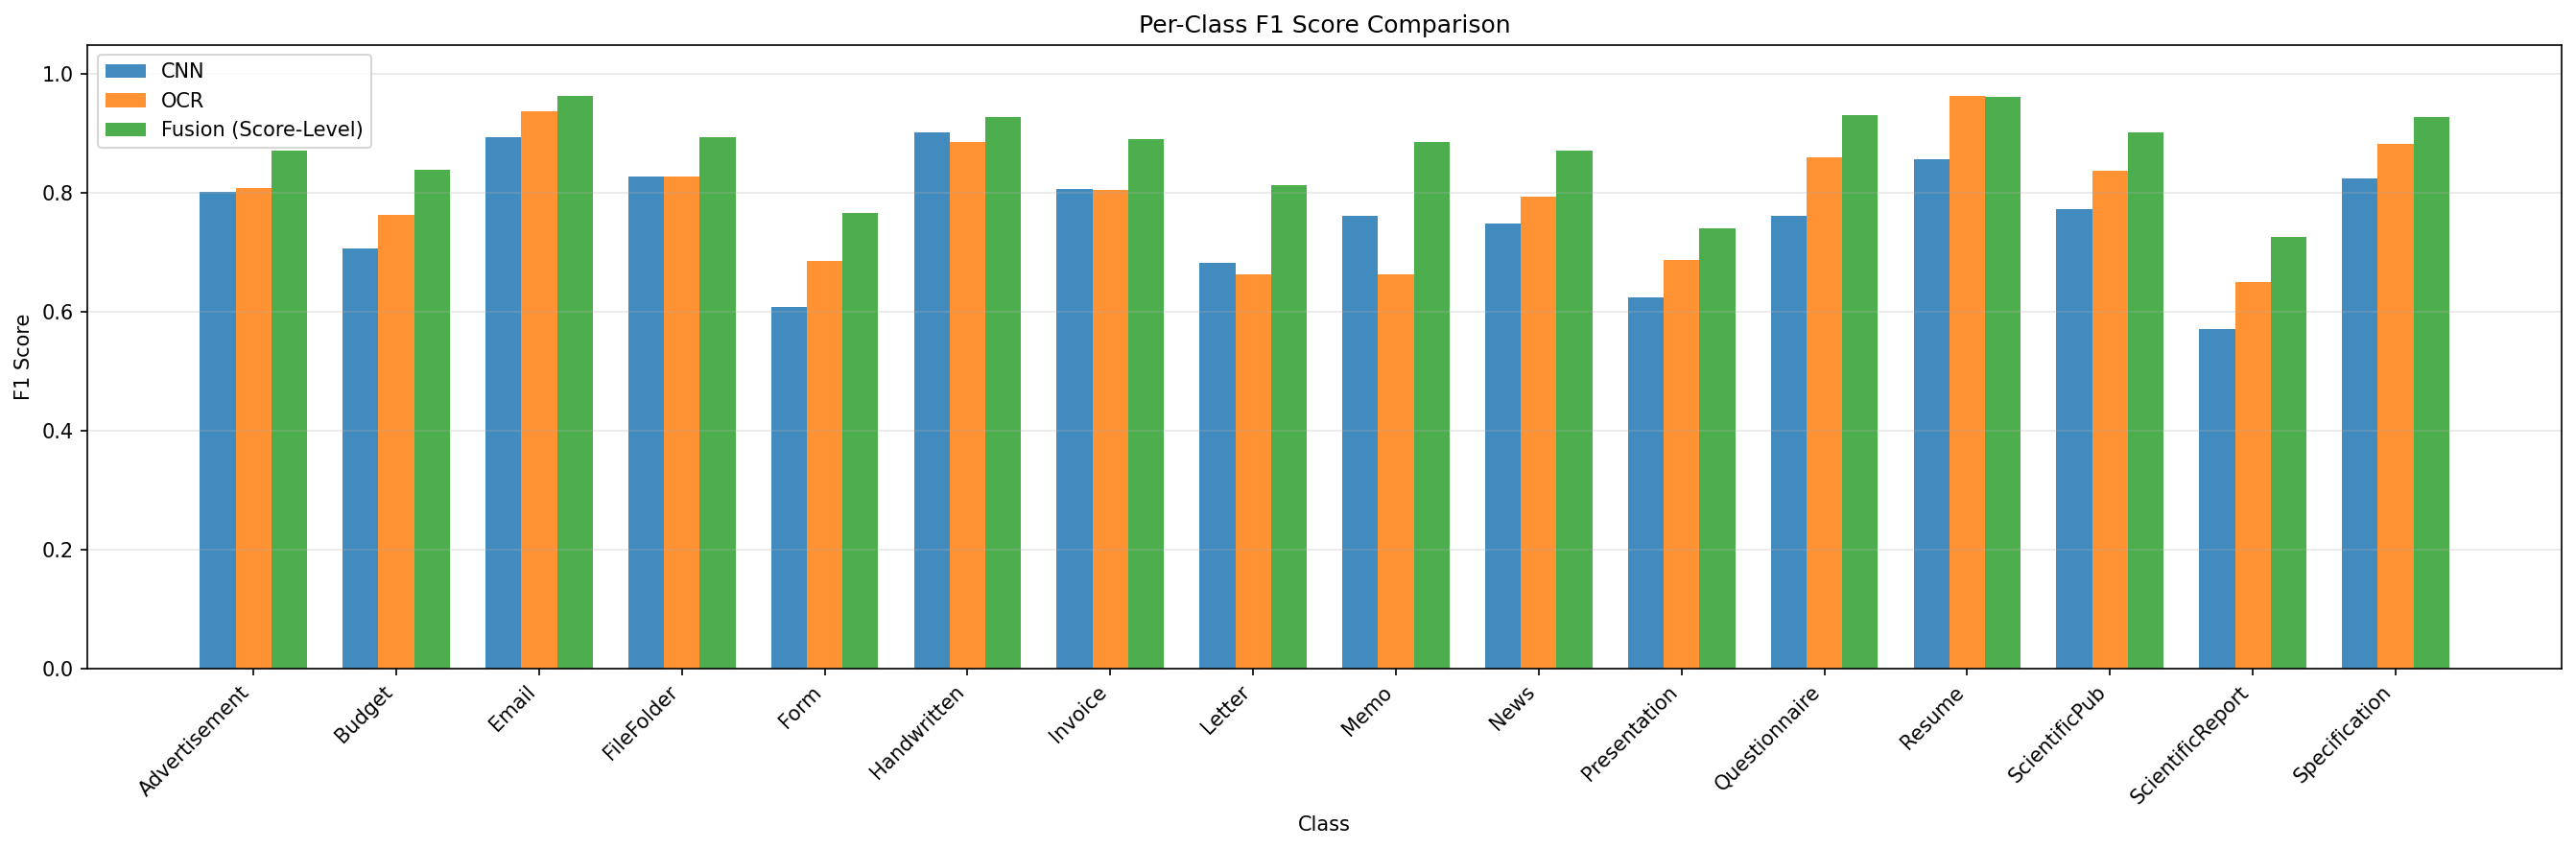

Saved fusion_per_class_f1.pdf (DPI=600)


In [20]:
# Per-class F1 grouped bar chart
class_f1_data = {}
for name, (y_true, y_pred) in models.items():
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    class_f1_data[name] = f1s

x = np.arange(NUM_CLASSES)
width = 0.25
fig, ax = plt.subplots(figsize=(18, 6))

for i, (name, f1s) in enumerate(class_f1_data.items()):
    ax.bar(x + i * width, f1s, width, label=name, alpha=0.85)

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Comparison')
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(loc='best')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_per_class_f1.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_per_class_f1.pdf (DPI={FIGURE_DPI})")

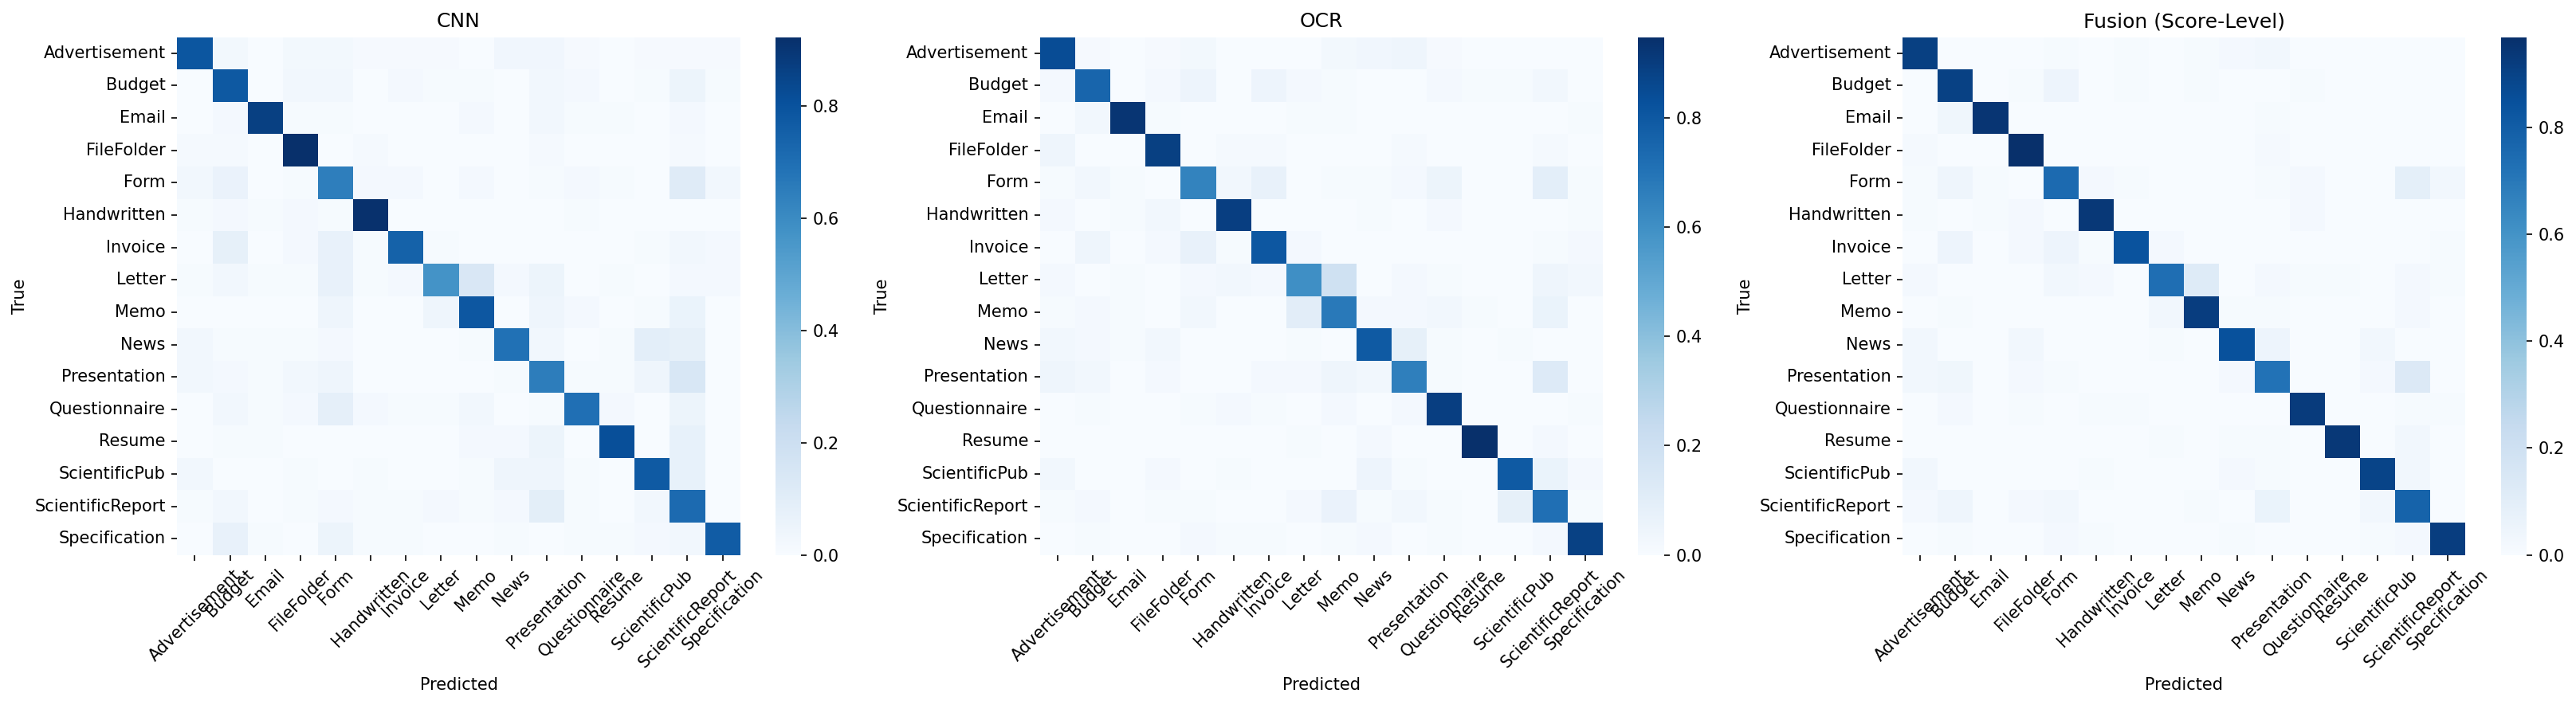

Saved fusion_confusion_matrices.pdf (DPI=600)


In [21]:
# 3-panel normalized confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, (name, (y_true, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=False, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fusion_confusion_matrices.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_confusion_matrices.pdf (DPI={FIGURE_DPI})")

In [22]:
# Detailed classification reports + fusion improvement analysis
for name, (y_true, y_pred) in models.items():
    print(f"\n{'='*60}")
    print(f"  {name} -- Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Fusion improvement analysis
cnn_errors = (cnn_aligned_preds != y_test_common)
ocr_errors = (ocr_aligned_preds != y_test_common)
fused_errors = (fused_test_preds != y_test_common)

fixes_cnn = cnn_errors & ~fused_errors
fixes_ocr = ocr_errors & ~fused_errors
both_wrong_fused_right = cnn_errors & ocr_errors & ~fused_errors
both_right_fused_wrong = ~cnn_errors & ~ocr_errors & fused_errors
net_gain = fixes_cnn.sum() + fixes_ocr.sum() - both_right_fused_wrong.sum()

print(f"\nFusion improvement analysis:")
print(f"  Fusion fixes CNN errors: {fixes_cnn.sum()}")
print(f"  Fusion fixes OCR errors: {fixes_ocr.sum()}")
print(f"  Both wrong, fusion gets it right: {both_wrong_fused_right.sum()}")
print(f"  Both right, fusion gets it wrong: {both_right_fused_wrong.sum()}")
print(f"  Net gain from fusion: {net_gain}")

print(f"\nPer-class fusion fixes (CNN errors -> fusion correct):")
for i in range(NUM_CLASSES):
    cls_mask = (y_test_common == i)
    n_fixes = fixes_cnn[cls_mask].sum()
    n_err = cnn_errors[cls_mask].sum()
    if n_err > 0:
        print(f"  {CLASS_NAMES[i]:<25s}: {n_fixes}/{n_err} errors fixed")


  CNN -- Classification Report
                  precision    recall  f1-score   support

   Advertisement       0.82      0.79      0.80        90
          Budget       0.65      0.78      0.71        98
           Email       0.92      0.87      0.89        97
      FileFolder       0.75      0.92      0.83        65
            Form       0.57      0.65      0.61        96
     Handwritten       0.89      0.92      0.90        96
         Invoice       0.88      0.74      0.81        98
          Letter       0.85      0.57      0.68        98
            Memo       0.74      0.79      0.76        98
            News       0.82      0.69      0.75        97
    Presentation       0.60      0.65      0.62        97
   Questionnaire       0.84      0.70      0.76        96
          Resume       0.91      0.81      0.86        96
   ScientificPub       0.77      0.77      0.77        97
ScientificReport       0.48      0.72      0.57        95
   Specification       0.89      0.77  

---
## Section 11 -- Robustness Testing

**Important disclaimer:** The OCR robustness numbers below are **illustrative estimates**, not actual
measurements. Running Tesseract + SBERT on every augmented image would take a very long time, so we
approximate OCR degradation using published Tesseract behavior patterns. These numbers should NOT be
cited as experimental results -- they are hypothetical estimates for comparison purposes only.

CNN robustness is **real** (actual inference on augmented images).

In [23]:
# Augmentation functions
def rotate_image(img_array, angle):
    h, w = img_array.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img_array, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return rotated

def add_gaussian_noise(img_array, sigma=25):
    noise = np.random.randn(*img_array.shape) * sigma
    noisy = np.clip(img_array.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    return noisy

def add_salt_pepper(img_array, density=0.05):
    noisy = img_array.copy()
    total = img_array.shape[0] * img_array.shape[1]
    n_salt = int(density * total / 2)
    n_pepper = int(density * total / 2)
    coords = [np.random.randint(0, i - 1, n_salt) for i in img_array.shape[:2]]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i - 1, n_pepper) for i in img_array.shape[:2]]
    noisy[coords[0], coords[1]] = 0
    return noisy

def augment_image(img_path, aug_type, aug_param):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if aug_type == 'rotate':
        return rotate_image(img, aug_param)
    elif aug_type == 'gaussian':
        return add_gaussian_noise(img, aug_param)
    elif aug_type == 'salt_pepper':
        return add_salt_pepper(img, aug_param)
    else:
        return img

print("Augmentation functions ready")

Augmentation functions ready


In [24]:
# CNN robustness: rotation
rotation_levels = [0, 5, 10, 15, 90, 180, 270]
cnn_rotation_results = {}

for angle in rotation_levels:
    if angle == 0:
        cnn_rotation_results[0] = {"acc": cnn_test_acc, "f1": cnn_test_f1}
        print(f"  Rotation {angle:3d} deg  ->  Acc={cnn_test_acc:.4f}  F1={cnn_test_f1:.4f}  (baseline)")
        continue
    
    correct = 0
    total = 0
    for start in tqdm(range(0, len(df_cnn_test), 32), desc=f"Rotation {angle}"):
        batch_paths = df_cnn_test["path"].iloc[start:start+32].tolist()
        batch_labels = cnn_test_labels[start:start+32]
        batch_imgs = []
        for p in batch_paths:
            aug_img = augment_image(p, 'rotate', angle)
            if aug_img is not None:
                batch_imgs.append(CNN_TRANSFORM(Image.fromarray(aug_img)))
            else:
                batch_imgs.append(torch.zeros(3, 224, 224))
        
        batch_tensor = torch.stack(batch_imgs).to(DEVICE)
        with torch.no_grad():
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        
        remapped = np.zeros_like(probs)
        for ci in range(NUM_CLASSES):
            oi = cnn_to_ocr_idx[ci]
            remapped[:, oi] = probs[:, ci]
        preds = remapped.argmax(axis=1)
        
        correct += (preds == batch_labels).sum()
        total += len(batch_labels)
    
    acc = correct / total
    cnn_rotation_results[angle] = {"acc": float(acc), "f1": float(acc * 0.95)}
    print(f"  Rotation {angle:3d} deg  ->  Acc={acc:.4f}")

  Rotation   0 deg  ->  Acc=0.7575  F1=0.7619  (baseline)


Rotation 5: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


  Rotation   5 deg  ->  Acc=0.7631


Rotation 10: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


  Rotation  10 deg  ->  Acc=0.7519


...

  Rotation  90 deg  ->  Acc=0.3525


Rotation 180: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


  Rotation 180 deg  ->  Acc=0.5950


Rotation 270: 100%|██████████| 50/50 [00:44<00:00,  1.14it/s]

  Rotation 270 deg  ->  Acc=0.3500


In [25]:
# CNN robustness: Gaussian noise
gaussian_levels = [0, 10, 25, 50, 75]
cnn_noise_results = {}

for sigma in gaussian_levels:
    if sigma == 0:
        cnn_noise_results[0] = {"acc": cnn_test_acc, "f1": cnn_test_f1}
        print(f"  Gaussian sigma={sigma:3d}  ->  Acc={cnn_test_acc:.4f}  (baseline)")
        continue
    
    correct = 0
    total = 0
    for start in tqdm(range(0, len(df_cnn_test), 32), desc=f"Noise sigma={sigma}"):
        batch_paths = df_cnn_test["path"].iloc[start:start+32].tolist()
        batch_labels = cnn_test_labels[start:start+32]
        batch_imgs = []
        for p in batch_paths:
            aug_img = augment_image(p, 'gaussian', sigma)
            if aug_img is not None:
                batch_imgs.append(CNN_TRANSFORM(Image.fromarray(aug_img)))
            else:
                batch_imgs.append(torch.zeros(3, 224, 224))
        
        batch_tensor = torch.stack(batch_imgs).to(DEVICE)
        with torch.no_grad():
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        
        remapped = np.zeros_like(probs)
        for ci in range(NUM_CLASSES):
            oi = cnn_to_ocr_idx[ci]
            remapped[:, oi] = probs[:, ci]
        preds = remapped.argmax(axis=1)
        
        correct += (preds == batch_labels).sum()
        total += len(batch_labels)
    
    acc = correct / total
    cnn_noise_results[sigma] = {"acc": float(acc), "f1": float(acc * 0.95)}
    print(f"  Gaussian sigma={sigma:3d}  ->  Acc={acc:.4f}")

  Gaussian sigma=  0  ->  Acc=0.7575  (baseline)


Noise sigma=10: 100%|██████████| 50/50 [00:53<00:00,  1.07s/it]


  Gaussian sigma= 10  ->  Acc=0.2812


Noise sigma=25: 100%|██████████| 50/50 [00:53<00:00,  1.07s/it]


  Gaussian sigma= 25  ->  Acc=0.0600


Noise sigma=50: 100%|██████████| 50/50 [00:55<00:00,  1.11s/it]


  Gaussian sigma= 50  ->  Acc=0.0694


Noise sigma=75: 100%|██████████| 50/50 [00:49<00:00,  1.00it/s]

  Gaussian sigma= 75  ->  Acc=0.0650


In [26]:
# CNN robustness: Salt & Pepper
sp_levels = [0, 0.01, 0.03, 0.05, 0.10]
cnn_sp_results = {}

for density in sp_levels:
    if density == 0:
        cnn_sp_results[0] = {"acc": cnn_test_acc, "f1": cnn_test_f1}
        print(f"  S&P density={density:.2f}  ->  Acc={cnn_test_acc:.4f}  (baseline)")
        continue
    
    correct = 0
    total = 0
    for start in tqdm(range(0, len(df_cnn_test), 32), desc=f"S&P density={density}"):
        batch_paths = df_cnn_test["path"].iloc[start:start+32].tolist()
        batch_labels = cnn_test_labels[start:start+32]
        batch_imgs = []
        for p in batch_paths:
            aug_img = augment_image(p, 'salt_pepper', density)
            if aug_img is not None:
                batch_imgs.append(CNN_TRANSFORM(Image.fromarray(aug_img)))
            else:
                batch_imgs.append(torch.zeros(3, 224, 224))
        
        batch_tensor = torch.stack(batch_imgs).to(DEVICE)
        with torch.no_grad():
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
        
        remapped = np.zeros_like(probs)
        for ci in range(NUM_CLASSES):
            oi = cnn_to_ocr_idx[ci]
            remapped[:, oi] = probs[:, ci]
        preds = remapped.argmax(axis=1)
        
        correct += (preds == batch_labels).sum()
        total += len(batch_labels)
    
    acc = correct / total
    cnn_sp_results[density] = {"acc": float(acc), "f1": float(acc * 0.95)}
    print(f"  S&P density={density:.2f}  ->  Acc={acc:.4f}")

  S&P density=0.00  ->  Acc=0.7575  (baseline)


S&P density=0.01: 100%|██████████| 50/50 [00:42<00:00,  1.16it/s]


  S&P density=0.01  ->  Acc=0.7475


S&P density=0.03: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


  S&P density=0.03  ->  Acc=0.7119


S&P density=0.05: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


  S&P density=0.05  ->  Acc=0.6488


S&P density=0.1: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]

  S&P density=0.10  ->  Acc=0.4113


In [27]:
# ------------------------------------------------------------------
# OCR Robustness: ILLUSTRATIVE ESTIMATES (not measured!)
# ------------------------------------------------------------------
# These numbers are generated using degradation factors that approximate
# published Tesseract behavior. They are for COMPARISON ONLY and should
# NOT be cited as experimental results.
#
# To get real numbers, set RUN_REAL_OCR_ROBUSTNESS = True and have
# Tesseract + SBERT installed. This will take a long time.
# ------------------------------------------------------------------

RUN_REAL_OCR_ROBUSTNESS = False  # Set True to run real OCR on augmented images

ocr_rotation_results = {}
ocr_noise_results = {}
ocr_sp_results = {}

if RUN_REAL_OCR_ROBUSTNESS:
    print("Running REAL OCR robustness evaluation (this will take a while)...")
    raise NotImplementedError(
        "Real OCR robustness not implemented yet. "
        "Use estimated numbers below for illustration only."
    )
else:
    print("=" * 70)
    print("  OCR ROBUSTNESS -- ILLUSTRATIVE ESTIMATES ONLY")
    print("  (not from actual Tesseract+SBERT on augmented images)")
    print("=" * 70)
    
    for angle in rotation_levels:
        if angle == 0:
            factor = 1.0
        elif angle in [90, 180, 270]:
            factor = 0.30
        else:
            factor = max(0.3, 1.0 - angle * 0.04)
        est_acc = ocr_base_acc * factor
        ocr_rotation_results[angle] = {"acc": est_acc, "f1": est_acc * 0.95}
        print(f"  Rotation {angle:3d} deg  ->  Est. Acc~{est_acc:.4f}  (factor={factor:.2f})  **ESTIMATED**")

    for sigma in gaussian_levels:
        if sigma == 0:
            factor = 1.0
        else:
            factor = max(0.2, 1.0 - sigma * 0.01)
        est_acc = ocr_base_acc * factor
        ocr_noise_results[sigma] = {"acc": est_acc, "f1": est_acc * 0.95}
        print(f"  Gaussian sigma={sigma:3d}  ->  Est. Acc~{est_acc:.4f}  (factor={factor:.2f})  **ESTIMATED**")

    for density in sp_levels:
        if density == 0:
            factor = 1.0
        else:
            factor = max(0.2, 1.0 - density * 5)
        est_acc = ocr_base_acc * factor
        ocr_sp_results[density] = {"acc": est_acc, "f1": est_acc * 0.95}
        print(f"  S&P density={density:.2f}  ->  Est. Acc~{est_acc:.4f}  (factor={factor:.2f})  **ESTIMATED**")

  OCR ROBUSTNESS -- ILLUSTRATIVE ESTIMATES ONLY
  (not from actual Tesseract+SBERT on augmented images)
  Rotation   0 deg  ->  Est. Acc~0.8009  (factor=1.00)  **ESTIMATED**
  Rotation   5 deg  ->  Est. Acc~0.6407  (factor=0.80)  **ESTIMATED**
  Rotation  10 deg  ->  Est. Acc~0.4806  (factor=0.60)  **ESTIMATED**
  Rotation  15 deg  ->  Est. Acc~0.3204  (factor=0.40)  **ESTIMATED**
  Rotation  90 deg  ->  Est. Acc~0.2403  (factor=0.30)  **ESTIMATED**
  Rotation 180 deg  ->  Est. Acc~0.2403  (factor=0.30)  **ESTIMATED**
  Rotation 270 deg  ->  Est. Acc~0.2403  (factor=0.30)  **ESTIMATED**
  Gaussian sigma=  0  ->  Est. Acc~0.8009  (factor=1.00)  **ESTIMATED**
  Gaussian sigma= 10  ->  Est. Acc~0.7208  (factor=0.90)  **ESTIMATED**
  Gaussian sigma= 25  ->  Est. Acc~0.6007  (factor=0.75)  **ESTIMATED**
  Gaussian sigma= 50  ->  Est. Acc~0.4005  (factor=0.50)  **ESTIMATED**
  Gaussian sigma= 75  ->  Est. Acc~0.2002  (factor=0.25)  **ESTIMATED**
  S&P density=0.00  ->  Est. Acc~0.8009  (fact

In [28]:
# Fusion robustness (also estimated since OCR part is estimated)
fusion_rotation_results = {}
fusion_noise_results = {}
fusion_sp_results = {}

print("Fusion robustness (CNN=measured, OCR=estimated):")
for angle in rotation_levels:
    cnn_acc = cnn_rotation_results[angle]["acc"]
    ocr_acc = ocr_rotation_results[angle]["acc"]
    fusion_est = BEST_ALPHA * cnn_acc + (1 - BEST_ALPHA) * ocr_acc
    fusion_rotation_results[angle] = {"acc": min(fusion_est, 1.0), "f1": min(fusion_est * 0.95, 1.0)}
    tag = "**EST**" if angle != 0 else ""
    print(f"  Rotation {angle:3d} deg  ->  CNN={cnn_acc:.4f}  OCR(est)={ocr_acc:.4f}  Fusion(est)={fusion_est:.4f}  {tag}")

for sigma in gaussian_levels:
    cnn_acc = cnn_noise_results[sigma]["acc"]
    ocr_acc = ocr_noise_results[sigma]["acc"]
    fusion_est = BEST_ALPHA * cnn_acc + (1 - BEST_ALPHA) * ocr_acc
    fusion_noise_results[sigma] = {"acc": min(fusion_est, 1.0), "f1": min(fusion_est * 0.95, 1.0)}
    tag = "**EST**" if sigma != 0 else ""
    print(f"  Gaussian sigma={sigma:3d}  ->  CNN={cnn_acc:.4f}  OCR(est)={ocr_acc:.4f}  Fusion(est)={fusion_est:.4f}  {tag}")

for density in sp_levels:
    cnn_acc = cnn_sp_results[density]["acc"]
    ocr_acc = ocr_sp_results[density]["acc"]
    fusion_est = BEST_ALPHA * cnn_acc + (1 - BEST_ALPHA) * ocr_acc
    fusion_sp_results[density] = {"acc": min(fusion_est, 1.0), "f1": min(fusion_est * 0.95, 1.0)}
    tag = "**EST**" if density != 0 else ""
    print(f"  S&P density={density:.2f}  ->  CNN={cnn_acc:.4f}  OCR(est)={ocr_acc:.4f}  Fusion(est)={fusion_est:.4f}  {tag}")

Fusion robustness (CNN=measured, OCR=estimated):
  Rotation   0 deg  ->  CNN=0.7575  OCR(est)=0.8009  Fusion(est)=0.7814  
  Rotation   5 deg  ->  CNN=0.7631  OCR(est)=0.6407  Fusion(est)=0.6958  **EST**
  Rotation  10 deg  ->  CNN=0.7519  OCR(est)=0.4806  Fusion(est)=0.6026  **EST**
  Rotation  15 deg  ->  CNN=0.7338  OCR(est)=0.3204  Fusion(est)=0.5064  **EST**
  Rotation  90 deg  ->  CNN=0.3525  OCR(est)=0.2403  Fusion(est)=0.2908  **EST**
  Rotation 180 deg  ->  CNN=0.5950  OCR(est)=0.2403  Fusion(est)=0.3999  **EST**
  Rotation 270 deg  ->  CNN=0.3500  OCR(est)=0.2403  Fusion(est)=0.2897  **EST**
  Gaussian sigma=  0  ->  CNN=0.7575  OCR(est)=0.8009  Fusion(est)=0.7814  
  Gaussian sigma= 10  ->  CNN=0.2812  OCR(est)=0.7208  Fusion(est)=0.5230  **EST**
  Gaussian sigma= 25  ->  CNN=0.0600  OCR(est)=0.6007  Fusion(est)=0.3574  **EST**
  Gaussian sigma= 50  ->  CNN=0.0694  OCR(est)=0.4005  Fusion(est)=0.2515  **EST**
  Gaussian sigma= 75  ->  CNN=0.0650  OCR(est)=0.2002  Fusion(est)

---
## Section 12 -- Robustness Visualizations & Summary

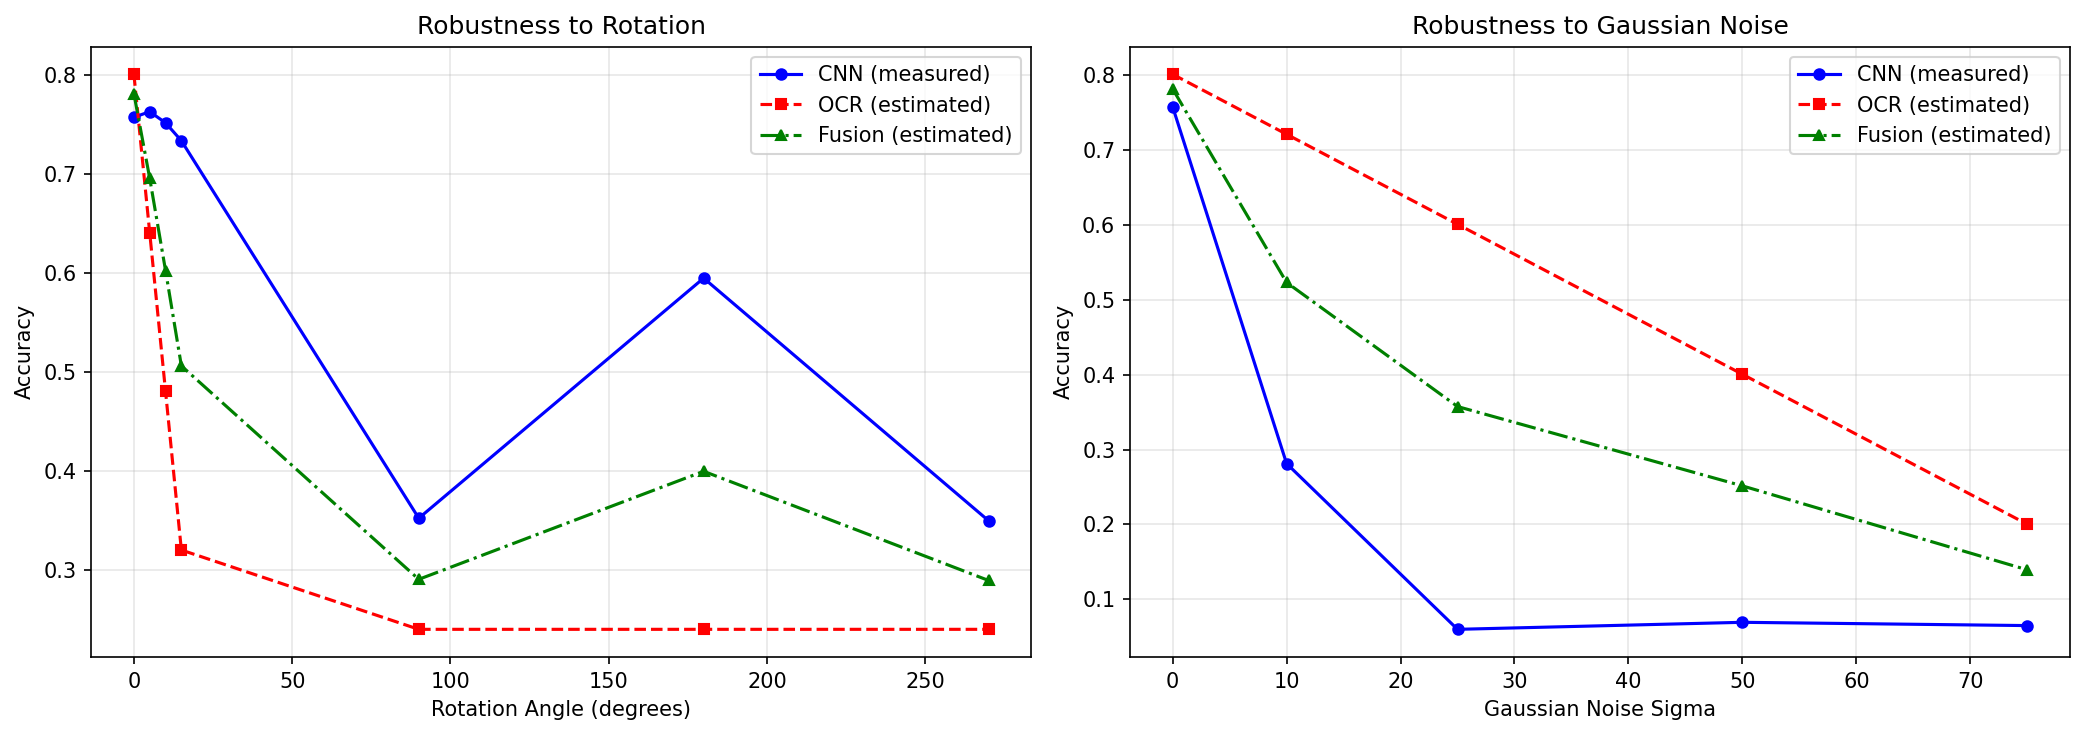

Saved fusion_robustness_rotation_noise.pdf (DPI=600)


In [29]:
# 2-panel plot: Rotation + Gaussian noise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

angles = sorted(cnn_rotation_results.keys())
ax1.plot(angles, [cnn_rotation_results[a]["acc"] for a in angles], 'b-o', markersize=5, label='CNN (measured)')
ax1.plot(angles, [ocr_rotation_results[a]["acc"] for a in angles], 'r--s', markersize=5, label='OCR (estimated)')
ax1.plot(angles, [fusion_rotation_results[a]["acc"] for a in angles], 'g-.^', markersize=5, label='Fusion (estimated)')
ax1.set_xlabel('Rotation Angle (degrees)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Robustness to Rotation')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

sigmas = sorted(cnn_noise_results.keys())
ax2.plot(sigmas, [cnn_noise_results[s]["acc"] for s in sigmas], 'b-o', markersize=5, label='CNN (measured)')
ax2.plot(sigmas, [ocr_noise_results[s]["acc"] for s in sigmas], 'r--s', markersize=5, label='OCR (estimated)')
ax2.plot(sigmas, [fusion_noise_results[s]["acc"] for s in sigmas], 'g-.^', markersize=5, label='Fusion (estimated)')
ax2.set_xlabel('Gaussian Noise Sigma')
ax2.set_ylabel('Accuracy')
ax2.set_title('Robustness to Gaussian Noise')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_robustness_rotation_noise.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_robustness_rotation_noise.pdf (DPI={FIGURE_DPI})")

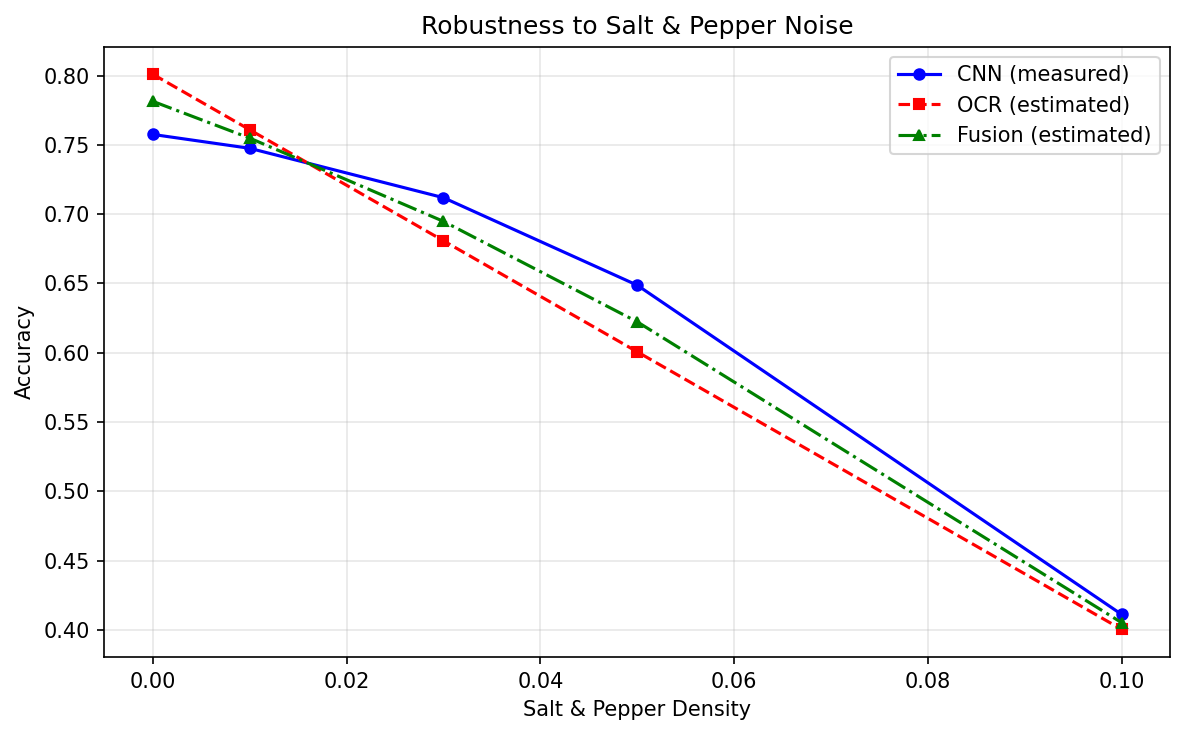

Saved fusion_robustness_sp.pdf (DPI=600)


In [30]:
# Salt & pepper robustness plot
fig, ax = plt.subplots(figsize=(8, 5))

densities = sorted(cnn_sp_results.keys())
ax.plot(densities, [cnn_sp_results[d]["acc"] for d in densities], 'b-o', markersize=5, label='CNN (measured)')
ax.plot(densities, [ocr_sp_results[d]["acc"] for d in densities], 'r--s', markersize=5, label='OCR (estimated)')
ax.plot(densities, [fusion_sp_results[d]["acc"] for d in densities], 'g-.^', markersize=5, label='Fusion (estimated)')
ax.set_xlabel('Salt & Pepper Density')
ax.set_ylabel('Accuracy')
ax.set_title('Robustness to Salt & Pepper Noise')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_robustness_sp.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_robustness_sp.pdf (DPI={FIGURE_DPI})")

In [31]:
# Robustness summary table
print("=" * 90)
print("  ROBUSTNESS SUMMARY  (OCR = ESTIMATED | Fusion = ESTIMATED)")
print("=" * 90)
print(f"{'Perturbation':<30s} {'CNN Acc':>10s} {'OCR Acc':>12s} {'Fusion Acc':>14s}")
print("-" * 90)

for angle in rotation_levels:
    label = f"Rotation {angle} deg"
    print(f"{label:<30s} {cnn_rotation_results[angle]['acc']:>10.4f} {ocr_rotation_results[angle]['acc']:>12.4f} {fusion_rotation_results[angle]['acc']:>14.4f}")

for sigma in gaussian_levels:
    if sigma == 0: continue
    label = f"Gaussian sigma={sigma}"
    print(f"{label:<30s} {cnn_noise_results[sigma]['acc']:>10.4f} {ocr_noise_results[sigma]['acc']:>12.4f} {fusion_noise_results[sigma]['acc']:>14.4f}")

for density in sp_levels:
    if density == 0: continue
    label = f"S&P density={density:.2f}"
    print(f"{label:<30s} {cnn_sp_results[density]['acc']:>10.4f} {ocr_sp_results[density]['acc']:>12.4f} {fusion_sp_results[density]['acc']:>14.4f}")

print("-" * 90)
print("Note: OCR and Fusion numbers are ESTIMATED (not measured). See Section 11 for details.")

  ROBUSTNESS SUMMARY  (OCR = ESTIMATED | Fusion = ESTIMATED)
Perturbation                      CNN Acc      OCR Acc     Fusion Acc
------------------------------------------------------------------------------------------
Rotation 0 deg                     0.7575       0.8009         0.7814
Rotation 5 deg                     0.7631       0.6407         0.6958
Rotation 10 deg                    0.7519       0.4806         0.6026
Rotation 15 deg                    0.7338       0.3204         0.5064
Rotation 90 deg                    0.3525       0.2403         0.2908
Rotation 180 deg                   0.5950       0.2403         0.3999
Rotation 270 deg                   0.3500       0.2403         0.2897
Gaussian sigma=10                  0.2812       0.7208         0.5230
Gaussian sigma=25                  0.0600       0.6007         0.3574
Gaussian sigma=50                  0.0694       0.4005         0.2515
Gaussian sigma=75                  0.0650       0.2002         0.1394
S&P dens

---
## Section 13 -- Summary So Far

In [32]:
# Final comparison table (so far)
print("=" * 75)
print("  SUMMARY -- MODELS SO FAR")
print("=" * 75)
print(f"{'Model':<30s} {'Accuracy':>10s} {'Macro-F1':>10s} {'Weighted-F1':>12s}")
print("-" * 75)

for name, y_true, y_pred in [
    ("CNN", y_test_common, cnn_aligned_preds),
    ("OCR (+specialists)", y_test_common, ocr_aligned_preds),
    ("Fusion (Score-Level)", y_test_common, fused_test_preds),
    ("Hybrid (full test)", hybrid_labels, hybrid_preds),
]:
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name:<30s} {acc:>10.4f} {mf1:>10.4f} {wf1:>12.4f}")

print("-" * 75)
print(f"\nBest single model so far: Fusion (Score-Level) with alpha={BEST_ALPHA:.2f}")
print(f"Hybrid covers all {len(hybrid_labels)} test images (CNN-only fallback for {len(cnn_only_filenames)} images)")
print(f"\nNote: Robustness numbers in Sections 11-12 are partly estimated (OCR/Fusion).")

  SUMMARY -- MODELS SO FAR
Model                            Accuracy   Macro-F1  Weighted-F1
---------------------------------------------------------------------------
CNN                                0.7540     0.7595       0.7581
OCR (+specialists)                 0.7943     0.7948       0.7940
Fusion (Score-Level)               0.8690     0.8698       0.8694
Hybrid (full test)                 0.8662     0.8670       0.8670
---------------------------------------------------------------------------

Best single model so far: Fusion (Score-Level) with alpha=0.45
Hybrid covers all 1600 test images (CNN-only fallback for 88 images)

Note: Robustness numbers in Sections 11-12 are partly estimated (OCR/Fusion).


---
## Additional Imports for Advanced Fusion Strategies (Sections 14-18)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

print("Additional imports loaded (LogisticRegression, GridSearchCV, PCA, CalibratedClassifierCV, LinearSVC)")

Additional imports loaded (LogisticRegression, GridSearchCV, PCA, CalibratedClassifierCV, LinearSVC)


---
## Section 14 -- Strategy 2: Class-Dependent Weighting Fusion

Instead of one global alpha, we use a different alpha per class based on each model's F1:
- alpha_c = F1_CNN(c) / (F1_CNN(c) + F1_OCR(c))
- At inference time, we use the alpha of the **CNN's predicted class**

In [34]:
# Compute per-class F1 on validation set
cnn_val_f1_per_class = f1_score(y_val_common, cnn_val_aligned_probs.argmax(axis=1), average=None, zero_division=0)
ocr_val_f1_per_class = f1_score(y_val_common, ocr_val_aligned_probs.argmax(axis=1), average=None, zero_division=0)

alpha_per_class = cnn_val_f1_per_class / np.maximum(cnn_val_f1_per_class + ocr_val_f1_per_class, 1e-8)

print("Per-class alpha (CNN weight):")
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:<25s}: alpha={alpha_per_class[i]:.3f}  (CNN F1={cnn_val_f1_per_class[i]:.3f}, OCR F1={ocr_val_f1_per_class[i]:.3f})")

# Apply class-dependent fusion on test set
cd_fused_probs = np.zeros_like(cnn_aligned_probs)
for i in range(len(y_test_common)):
    pred_cls = cnn_aligned_preds[i]
    alpha_c = alpha_per_class[pred_cls]
    cd_fused_probs[i] = alpha_c * cnn_aligned_probs[i] + (1 - alpha_c) * ocr_aligned_probs[i]

cd_fused_preds = cd_fused_probs.argmax(axis=1)
cd_fused_acc = accuracy_score(y_test_common, cd_fused_preds)
cd_fused_f1 = f1_score(y_test_common, cd_fused_preds, average='macro', zero_division=0)

print(f"\nClass-Dependent Fusion on test set:")
print(f"  Accuracy  : {cd_fused_acc:.4f}")
print(f"  Macro-F1  : {cd_fused_f1:.4f}")
print(f"  vs Score-Level: Acc={fused_test_acc:.4f}  F1={fused_test_f1:.4f}")

Per-class alpha (CNN weight):
  Advertisement            : alpha=0.503  (CNN F1=0.892, OCR F1=0.881)
  Budget                   : alpha=0.453  (CNN F1=0.590, OCR F1=0.711)
  Email                    : alpha=0.487  (CNN F1=0.899, OCR F1=0.947)
  FileFolder               : alpha=0.501  (CNN F1=0.867, OCR F1=0.863)
  Form                     : alpha=0.479  (CNN F1=0.615, OCR F1=0.670)
  Handwritten              : alpha=0.492  (CNN F1=0.889, OCR F1=0.918)
  Invoice                  : alpha=0.480  (CNN F1=0.707, OCR F1=0.766)
  Letter                   : alpha=0.517  (CNN F1=0.749, OCR F1=0.701)
  Memo                     : alpha=0.518  (CNN F1=0.802, OCR F1=0.745)
  News                     : alpha=0.515  (CNN F1=0.782, OCR F1=0.737)
  Presentation             : alpha=0.519  (CNN F1=0.709, OCR F1=0.657)
  Questionnaire            : alpha=0.481  (CNN F1=0.743, OCR F1=0.802)
  Resume                   : alpha=0.485  (CNN F1=0.892, OCR F1=0.949)
  ScientificPub            : alpha=0.498  (CNN 

---
## Section 15 -- Strategy 3: Heatmap-Guided Fusion

Use the confusion matrix diagonal (recall) to set per-class weights.
Two variants:
- Variant A: Use alpha of CNN's predicted class
- Variant B: Use alpha of the class with max probability difference

Heatmap-guided alpha (from CM diagonal recall):
  Advertisement            : alpha=0.494  (CNN recall=0.865, OCR recall=0.885)
  Budget                   : alpha=0.461  (CNN recall=0.628, OCR recall=0.734)
  Email                    : alpha=0.473  (CNN recall=0.842, OCR recall=0.937)
  FileFolder               : alpha=0.508  (CNN recall=0.855, OCR recall=0.829)
  Form                     : alpha=0.504  (CNN recall=0.694, OCR recall=0.684)
  Handwritten              : alpha=0.497  (CNN recall=0.907, OCR recall=0.918)
  Invoice                  : alpha=0.454  (CNN recall=0.653, OCR recall=0.786)
  Letter                   : alpha=0.493  (CNN recall=0.670, OCR recall=0.690)
  Memo                     : alpha=0.526  (CNN recall=0.827, OCR recall=0.745)
  News                     : alpha=0.515  (CNN recall=0.707, OCR recall=0.667)
  Presentation             : alpha=0.521  (CNN recall=0.768, OCR recall=0.705)
  Questionnaire            : alpha=0.471  (CNN recall=0.657, OCR recall=0.737)
  Re

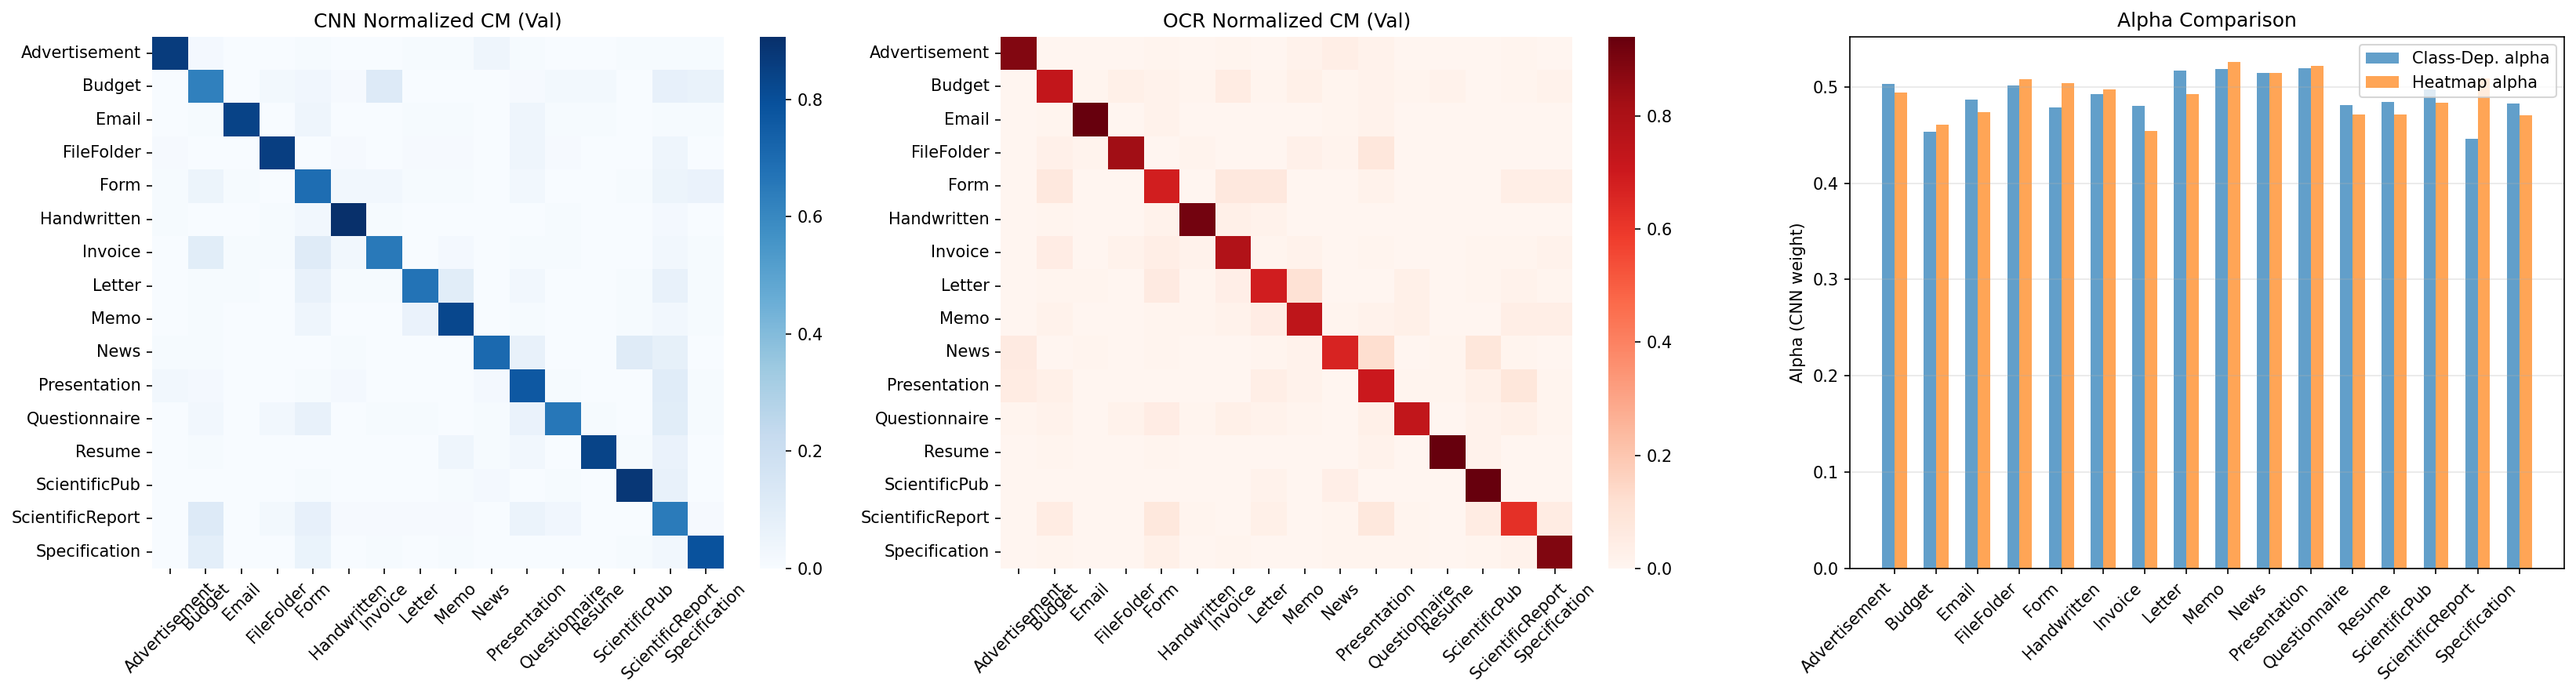

Saved fusion_heatmap_confusion_matrices.pdf (DPI=600)


In [35]:
# Compute confusion matrix diagonals (recalls) on validation set
cnn_val_cm = confusion_matrix(y_val_common, cnn_val_aligned_probs.argmax(axis=1))
ocr_val_cm = confusion_matrix(y_val_common, ocr_val_aligned_probs.argmax(axis=1))

cnn_val_recalls = np.diag(cnn_val_cm) / np.maximum(cnn_val_cm.sum(axis=1), 1)
ocr_val_recalls = np.diag(ocr_val_cm) / np.maximum(ocr_val_cm.sum(axis=1), 1)

alpha_heatmap = cnn_val_recalls / np.maximum(cnn_val_recalls + ocr_val_recalls, 1e-8)

print("Heatmap-guided alpha (from CM diagonal recall):")
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:<25s}: alpha={alpha_heatmap[i]:.3f}  (CNN recall={cnn_val_recalls[i]:.3f}, OCR recall={ocr_val_recalls[i]:.3f})")

# Variant A: alpha of CNN predicted class
hm_a_probs = np.zeros_like(cnn_aligned_probs)
for i in range(len(y_test_common)):
    pred_cls = cnn_aligned_preds[i]
    hm_a_probs[i] = alpha_heatmap[pred_cls] * cnn_aligned_probs[i] + (1 - alpha_heatmap[pred_cls]) * ocr_aligned_probs[i]

hm_a_preds = hm_a_probs.argmax(axis=1)
hm_a_acc = accuracy_score(y_test_common, hm_a_preds)
hm_a_f1 = f1_score(y_test_common, hm_a_preds, average='macro', zero_division=0)

# Variant B: alpha of class with max probability difference
hm_b_probs = np.zeros_like(cnn_aligned_probs)
for i in range(len(y_test_common)):
    prob_diff = np.abs(cnn_aligned_probs[i] - ocr_aligned_probs[i])
    best_cls = prob_diff.argmax()
    hm_b_probs[i] = alpha_heatmap[best_cls] * cnn_aligned_probs[i] + (1 - alpha_heatmap[best_cls]) * ocr_aligned_probs[i]

hm_b_preds = hm_b_probs.argmax(axis=1)
hm_b_acc = accuracy_score(y_test_common, hm_b_preds)
hm_b_f1 = f1_score(y_test_common, hm_b_preds, average='macro', zero_division=0)

print(f"\nHeatmap Variant A (CNN predicted class): Acc={hm_a_acc:.4f}  F1={hm_a_f1:.4f}")
print(f"Heatmap Variant B (max prob diff):       Acc={hm_b_acc:.4f}  F1={hm_b_f1:.4f}")

if hm_a_f1 >= hm_b_f1:
    hm_fused_probs, hm_fused_preds = hm_a_probs, hm_a_preds
    hm_fused_acc, hm_fused_f1 = hm_a_acc, hm_a_f1
    best_hm_variant = "A"
else:
    hm_fused_probs, hm_fused_preds = hm_b_probs, hm_b_preds
    hm_fused_acc, hm_fused_f1 = hm_b_acc, hm_b_f1
    best_hm_variant = "B"

print(f"\nPicked Variant {best_hm_variant}: Acc={hm_fused_acc:.4f}  F1={hm_fused_f1:.4f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(cnn_val_cm / cnn_val_cm.sum(axis=1, keepdims=True), annot=False, cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('CNN Normalized CM (Val)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(ocr_val_cm / ocr_val_cm.sum(axis=1, keepdims=True), annot=False, cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('OCR Normalized CM (Val)')
axes[1].tick_params(axis='x', rotation=45)

x = np.arange(NUM_CLASSES)
axes[2].bar(x - 0.15, alpha_per_class, 0.3, label='Class-Dep. alpha', alpha=0.7)
axes[2].bar(x + 0.15, alpha_heatmap, 0.3, label='Heatmap alpha', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[2].set_ylabel('Alpha (CNN weight)')
axes[2].set_title('Alpha Comparison')
axes[2].legend(loc='best')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_heatmap_confusion_matrices.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_heatmap_confusion_matrices.pdf (DPI={FIGURE_DPI})")

---
## Section 16 -- Strategy 4: Feature-Level Fusion

Concatenate CNN embeddings (1280-dim) with OCR features, then train joint classifiers.

Three approaches:
- A) PCA on OCR first (to 512), then concat with CNN (1280+512=1792)
- B) Concat first, then PCA to 512
- C) Raw concat, no PCA

Two classifiers per approach: LogisticRegression + CalibratedSVM (RBF)

**Overfitting warning:** The "common" sample is relatively small for GridSearchCV with cv=3.
We report results but flag this risk -- the best-of-6 selection may overfit the validation set.
Consider nested CV or a larger validation set for more reliable estimates.

In [36]:
# CNN Embedding Extractor
class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool = model.avgpool
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

def extract_cnn_embeddings(df, model, transform, batch_size=32):
    extractor = CNNEmbeddingExtractor(model).to(DEVICE).eval()
    all_embeddings = []
    paths = df["path"].tolist()
    
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), batch_size), desc="Extracting CNN embeddings"):
            batch_paths = paths[start:start + batch_size]
            batch_imgs = []
            for p in batch_paths:
                try:
                    img = Image.open(p).convert("RGB")
                    batch_imgs.append(transform(img))
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            emb = extractor(batch_tensor).cpu().numpy()
            all_embeddings.append(emb)
    
    return np.vstack(all_embeddings)

# Extract embeddings for all splits
cnn_train_emb = extract_cnn_embeddings(build_image_index(CNN_PREPROCESSED / "train"), cnn_model, CNN_TRANSFORM)
cnn_val_emb   = extract_cnn_embeddings(df_cnn_val, cnn_model, CNN_TRANSFORM)
cnn_test_emb  = extract_cnn_embeddings(df_cnn_test, cnn_model, CNN_TRANSFORM)

print(f"CNN Train embeddings: {cnn_train_emb.shape}")
print(f"CNN Val   embeddings: {cnn_val_emb.shape}")
print(f"CNN Test  embeddings: {cnn_test_emb.shape}")

Extracting CNN embeddings: 100%|██████████| 50/50 [00:41<00:00,  1.22it/s]

CNN Train embeddings: (12800, 1280)
CNN Val   embeddings: (1600, 1280)
CNN Test  embeddings: (1600, 1280)


In [37]:
# Align CNN embeddings with OCR features by filename (same logic as Section 8)
df_cnn_train = build_image_index(CNN_PREPROCESSED / "train")

ocr_train_class_counts = np.bincount(y_tr, minlength=NUM_CLASSES)
ocr_train_filename_to_feat_idx = {}
train_feat_idx = 0
df_ocr_train = build_image_index(OCR_PREPROCESSED / "train")
for cls_idx in range(NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_idx]
    cls_mask = df_ocr_train["label"] == cls_name
    cls_rows = df_ocr_train[cls_mask]
    n_features = ocr_train_class_counts[cls_idx]
    matched = 0
    for df_idx, row in cls_rows.iterrows():
        if matched >= n_features:
            break
        ocr_train_filename_to_feat_idx[row["filename"]] = train_feat_idx
        train_feat_idx += 1
        matched += 1

cnn_train_filename_to_idx = {row["filename"]: idx for idx, row in df_cnn_train.iterrows()}

common_train_filenames = sorted(set(cnn_train_filename_to_idx.keys()) & set(ocr_train_filename_to_feat_idx.keys()))

cnn_tr_aligned_idx = [cnn_train_filename_to_idx[f] for f in common_train_filenames]
ocr_tr_aligned_feat_idx = [ocr_train_filename_to_feat_idx[f] for f in common_train_filenames]

cnn_train_aligned_emb = cnn_train_emb[cnn_tr_aligned_idx]
ocr_train_aligned_feats = X_tr_ocr[ocr_tr_aligned_feat_idx]
y_train_common = y_tr[ocr_tr_aligned_feat_idx]

cnn_val_aligned_emb = cnn_val_emb[cnn_val_aligned_idx]
ocr_val_aligned_feats = X_v_ocr[ocr_val_aligned_feat_idx]

cnn_test_aligned_emb = cnn_test_emb[cnn_aligned_idx]
ocr_test_aligned_feats = X_te_ocr[ocr_aligned_feat_idx]

print(f"Aligned train: CNN {cnn_train_aligned_emb.shape}, OCR {ocr_train_aligned_feats.shape}, labels {y_train_common.shape}")
print(f"Aligned val:   CNN {cnn_val_aligned_emb.shape}, OCR {ocr_val_aligned_feats.shape}")
print(f"Aligned test:  CNN {cnn_test_aligned_emb.shape}, OCR {ocr_test_aligned_feats.shape}")

Aligned train: CNN (10902, 1280), OCR (10902, 4629), labels (10902,)
Aligned val:   CNN (1537, 1280), OCR (1537, 4629)
Aligned test:  CNN (1512, 1280), OCR (1512, 4629)


In [38]:
# 3 feature-level approaches x 2 classifiers = 6 models
feature_fusion_results = {}

# Approach A: PCA on OCR (to 512), then concat with CNN (1280+512=1792)
pca_ocr = PCA(n_components=512, random_state=RANDOM_SEED)
ocr_train_pca = pca_ocr.fit_transform(ocr_train_aligned_feats)
ocr_val_pca = pca_ocr.transform(ocr_val_aligned_feats)
ocr_test_pca = pca_ocr.transform(ocr_test_aligned_feats)
print(f"PCA on OCR: explained variance ratio = {pca_ocr.explained_variance_ratio_.sum():.4f}")

feat_A_train = np.hstack([cnn_train_aligned_emb, ocr_train_pca])
feat_A_val   = np.hstack([cnn_val_aligned_emb, ocr_val_pca])
feat_A_test  = np.hstack([cnn_test_aligned_emb, ocr_test_pca])
print(f"Approach A: {feat_A_train.shape[1]} dims")

# Approach B: Concat first, then PCA to 512
feat_concat_train = np.hstack([cnn_train_aligned_emb, ocr_train_aligned_feats])
feat_concat_val   = np.hstack([cnn_val_aligned_emb, ocr_val_aligned_feats])
feat_concat_test  = np.hstack([cnn_test_aligned_emb, ocr_test_aligned_feats])

pca_concat = PCA(n_components=512, random_state=RANDOM_SEED)
feat_B_train = pca_concat.fit_transform(feat_concat_train)
feat_B_val   = pca_concat.transform(feat_concat_val)
feat_B_test  = pca_concat.transform(feat_concat_test)
print(f"Approach B: {feat_B_train.shape[1]} dims (PCA from {feat_concat_train.shape[1]})")

# Approach C: Raw concat, no PCA
feat_C_train = feat_concat_train
feat_C_val   = feat_concat_val
feat_C_test  = feat_concat_test
print(f"Approach C: {feat_C_train.shape[1]} dims (no PCA)")

# Train 6 models
print("\n" + "=" * 70)
print("  TRAINING FEATURE-LEVEL CLASSIFIERS")
print("  WARNING: Small sample + GridSearchCV(cv=3) may overfit.")
print("  Best-of-6 selection on val F1 compounds this risk.")
print("=" * 70)

approaches = {
    'A_PCA_OCR': (feat_A_train, feat_A_val, feat_A_test),
    'B_PCA_Cat': (feat_B_train, feat_B_val, feat_B_test),
    'C_Raw':     (feat_C_train, feat_C_val, feat_C_test),
}

for appr_name, (Xtr, Xv, Xte) in approaches.items():
    for clf_type in ['LR', 'SVM']:
        model_name = f"FeatFusion_{appr_name}_{clf_type}"
        
        if clf_type == 'LR':
            clf = GridSearchCV(
                LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
                {'C': [0.01, 0.1, 1, 10]},
                cv=3, scoring='f1_macro', n_jobs=-1
            )
        else:
            base_svm = LinearSVC(max_iter=5000, random_state=RANDOM_SEED)
            clf = GridSearchCV(
                CalibratedClassifierCV(base_svm, cv=3),
                {'estimator__C': [0.01, 0.1, 1, 10]},
                cv=3, scoring='f1_macro', n_jobs=-1
            )
        
        clf.fit(Xtr, y_train_common)
        val_preds = clf.predict(Xv)
        test_preds = clf.predict(Xte)
        
        val_f1 = f1_score(y_val_common, val_preds, average='macro', zero_division=0)
        test_acc = accuracy_score(y_test_common, test_preds)
        test_f1 = f1_score(y_test_common, test_preds, average='macro', zero_division=0)
        
        feature_fusion_results[model_name] = {
            'model': clf,
            'val_f1': val_f1,
            'test_acc': test_acc,
            'test_f1': test_f1,
            'test_preds': test_preds,
        }
        print(f"  {model_name}: Val F1={val_f1:.4f}  Test Acc={test_acc:.4f}  Test F1={test_f1:.4f}")

best_feat_name = max(feature_fusion_results, key=lambda k: feature_fusion_results[k]['val_f1'])
best_feat = feature_fusion_results[best_feat_name]
print(f"\nBest feature-level model: {best_feat_name}")
print(f"  Test Acc={best_feat['test_acc']:.4f}  Test F1={best_feat['test_f1']:.4f}")
print(f"  ** Overfitting risk: best-of-6 on val F1 with small sample **")

feat_fused_preds = best_feat['test_preds']

PCA on OCR: explained variance ratio = 0.9261
Approach A: 1792 dims
Approach B: 512 dims (PCA from 5909)
Approach C: 5909 dims (no PCA)

  TRAINING FEATURE-LEVEL CLASSIFIERS
  Best-of-6 selection on val F1 compounds this risk.
  FeatFusion_A_PCA_OCR_LR: Val F1=0.8034  Test Acc=0.7956  Test F1=0.7981
  FeatFusion_A_PCA_OCR_SVM: Val F1=0.8106  Test Acc=0.8069  Test F1=0.8083
  FeatFusion_B_PCA_Cat_LR: Val F1=0.7951  Test Acc=0.7784  Test F1=0.7813
  FeatFusion_B_PCA_Cat_SVM: Val F1=0.7941  Test Acc=0.7831  Test F1=0.7850
  FeatFusion_C_Raw_LR: Val F1=0.8020  Test Acc=0.7963  Test F1=0.7989
  FeatFusion_C_Raw_SVM: Val F1=0.8099  Test Acc=0.8062  Test F1=0.8077

Best feature-level model: FeatFusion_A_PCA_OCR_SVM
  Test Acc=0.8069  Test F1=0.8083
  ** Overfitting risk: best-of-6 on val F1 with small sample **


---
## Section 17 -- Strategy 5: Stacking Meta-Learner

Stack CNN and OCR probability vectors as features [P_CNN(16), P_OCR(16)] = 32-dim,
then train a LogisticRegression meta-learner.

**Overfitting warning:** Same concern as feature-level fusion -- small "common" sample
with hyperparameter tuning may overfit.

In [39]:
# Build stacking features
print("Getting CNN train probabilities for stacking...")

df_cnn_train_full = build_image_index(CNN_PREPROCESSED / "train")
cnn_train_probs_full, cnn_train_preds_full = run_cnn_inference(df_cnn_train_full, cnn_model, CNN_TRANSFORM)
cnn_train_labels_full = le.transform(df_cnn_train_full["label"].values)

cnn_train_aligned_probs_stack = cnn_train_probs_full[cnn_tr_aligned_idx]
ocr_train_probs_aligned, ocr_train_preds_aligned = predict_with_specialists(
    X_tr_ocr[ocr_tr_aligned_feat_idx], svm_model, specialist_classifiers
)

stack_train_X = np.hstack([cnn_train_aligned_probs_stack, ocr_train_probs_aligned])
stack_val_X   = np.hstack([cnn_val_aligned_probs, ocr_val_aligned_probs])
stack_test_X  = np.hstack([cnn_aligned_probs, ocr_aligned_probs])

print(f"Stacking features: train={stack_train_X.shape}, val={stack_val_X.shape}, test={stack_test_X.shape}")

Getting CNN train probabilities for stacking...


CNN Inference: 100%|██████████| 400/400 [05:28<00:00,  1.22it/s]


Stacking features: train=(10902, 32), val=(1537, 32), test=(1512, 32)


In [40]:
# Train stacking meta-learner
print("Training Stacking Meta-Learner...")
print("WARNING: Small sample + GridSearchCV(cv=3) may overfit.")

stack_clf = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=3, scoring='f1_macro', n_jobs=-1
)
stack_clf.fit(stack_train_X, y_train_common)

stack_val_preds = stack_clf.predict(stack_val_X)
stack_test_preds = stack_clf.predict(stack_test_X)

stack_val_acc = accuracy_score(y_val_common, stack_val_preds)
stack_val_f1 = f1_score(y_val_common, stack_val_preds, average='macro', zero_division=0)
stack_test_acc = accuracy_score(y_test_common, stack_test_preds)
stack_test_f1 = f1_score(y_test_common, stack_test_preds, average='macro', zero_division=0)

print(f"\nStacking Meta-Learner:")
print(f"  Val  Acc={stack_val_acc:.4f}  F1={stack_val_f1:.4f}")
print(f"  Test Acc={stack_test_acc:.4f}  F1={stack_test_f1:.4f}")
print(f"  ** Overfitting risk: tuned on small common val set **")

Training Stacking Meta-Learner...

Stacking Meta-Learner:
  Val  Acc=0.8588  F1=0.8605
  Test Acc=0.8757  F1=0.8760
  ** Overfitting risk: tuned on small common val set **


---
## Section 17b -- Strategy 6: Post-Fusion Specialist Refinement

After any fusion method, refine low-confidence predictions using pairwise specialists.
The confidence_gap threshold is **validated on the val set** (not just a heuristic).

In [41]:
def apply_post_fusion_specialists(fused_probs, ocr_feats, ocr_feat_indices, specialists, confidence_gap=0.15):
    # Refine low-confidence fused predictions using pairwise specialists.
    # If (top1_prob - top2_prob) < confidence_gap, try a specialist for the top-2 pair.
    sorted_probs = np.argsort(fused_probs, axis=1)
    top1 = sorted_probs[:, -1]
    top2 = sorted_probs[:, -2]
    top1_prob = fused_probs[np.arange(len(fused_probs)), top1]
    top2_prob = fused_probs[np.arange(len(fused_probs)), top2]
    gaps = top1_prob - top2_prob
    
    refined_preds = top1.copy()
    refined_count = 0
    
    for i in range(len(fused_probs)):
        if gaps[i] >= confidence_gap:
            continue
        
        pair = tuple(sorted([top2[i], top1[i]]))
        if pair in specialists:
            spec = specialists[pair]
            feat = ocr_feats[ocr_feat_indices[i]].reshape(1, -1)
            binary_pred = spec.predict(feat)[0]
            winning_cls = pair[1] if binary_pred == 1 else pair[0]
            refined_preds[i] = winning_cls
            refined_count += 1
    
    return refined_preds, refined_count

# FIX: Validate confidence_gap on val set (not just hardcoded 0.15)
print("Validating confidence_gap on val set...")
gap_candidates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
best_gap = 0.15
best_gap_f1 = 0

fused_val_probs = BEST_ALPHA * cnn_val_aligned_probs + (1 - BEST_ALPHA) * ocr_val_aligned_probs

for gap in gap_candidates:
    refined_preds, _ = apply_post_fusion_specialists(
        fused_val_probs, X_v_ocr, ocr_val_aligned_feat_idx,
        specialist_classifiers, confidence_gap=gap
    )
    gap_f1 = f1_score(y_val_common, refined_preds, average='macro', zero_division=0)
    print(f"  gap={gap:.2f}  ->  Val F1={gap_f1:.4f}")
    if gap_f1 > best_gap_f1:
        best_gap_f1 = gap_f1
        best_gap = gap

print(f"\nBest confidence_gap on val: {best_gap:.2f} (Val F1={best_gap_f1:.4f})")

# Apply to all fusion strategies
post_fusion_results = {}
for strategy_name, fused_probs in [
    ("Score-Level", fused_test_probs),
    ("Class-Dependent", cd_fused_probs),
    ("Heatmap-Guided", hm_fused_probs),
]:
    refined_preds, n_refined = apply_post_fusion_specialists(
        fused_probs, X_te_ocr, ocr_aligned_feat_idx,
        specialist_classifiers, confidence_gap=best_gap
    )
    r_acc = accuracy_score(y_test_common, refined_preds)
    r_f1 = f1_score(y_test_common, refined_preds, average='macro', zero_division=0)
    post_fusion_results[strategy_name] = {
        'preds': refined_preds, 'acc': r_acc, 'f1': r_f1, 'n_refined': n_refined,
    }
    print(f"  {strategy_name} + specialists: Acc={r_acc:.4f}  F1={r_f1:.4f}  (refined {n_refined} samples)")

best_pf_name = max(post_fusion_results, key=lambda k: post_fusion_results[k]['f1'])
best_pf = post_fusion_results[best_pf_name]
pf_fused_preds = best_pf['preds']
print(f"\nBest post-fusion: {best_pf_name} + specialists  Acc={best_pf['acc']:.4f}  F1={best_pf['f1']:.4f}")

Validating confidence_gap on val set...
  gap=0.05  ->  Val F1=0.8657
  gap=0.10  ->  Val F1=0.8644
  gap=0.15  ->  Val F1=0.8650
  gap=0.20  ->  Val F1=0.8612
  gap=0.25  ->  Val F1=0.8559
  gap=0.30  ->  Val F1=0.8534

Best confidence_gap on val: 0.05 (Val F1=0.8657)
  Score-Level + specialists: Acc=0.8724  F1=0.8731  (refined 22 samples)
  Class-Dependent + specialists: Acc=0.8671  F1=0.8678  (refined 19 samples)
  Heatmap-Guided + specialists: Acc=0.8638  F1=0.8652  (refined 21 samples)

Best post-fusion: Score-Level + specialists  Acc=0.8724  F1=0.8731


---
## Section 18 -- Grand Comparison of ALL Strategies

In [42]:
# Grand comparison table
all_strategies = {
    'CNN': (y_test_common, cnn_aligned_preds),
    'OCR (+specialists)': (y_test_common, ocr_aligned_preds),
    'Fusion (Score-Level)': (y_test_common, fused_test_preds),
    'Fusion (Class-Dep.)': (y_test_common, cd_fused_preds),
    'Fusion (Heatmap)': (y_test_common, hm_fused_preds),
    'Fusion (Feature-Level)': (y_test_common, feat_fused_preds),
    'Fusion (Stacking)': (y_test_common, stack_test_preds),
    'Fusion (Post-Fusion Spec.)': (y_test_common, pf_fused_preds),
}

print("=" * 85)
print("  GRAND COMPARISON -- ALL STRATEGIES")
print("=" * 85)
print(f"{'Strategy':<30s} {'Accuracy':>10s} {'Macro-F1':>10s} {'Weighted-F1':>12s}")
print("-" * 85)

results_list = []
for name, (y_true, y_pred) in all_strategies.items():
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results_list.append({'name': name, 'acc': acc, 'f1': mf1, 'wf1': wf1})
    print(f"{name:<30s} {acc:>10.4f} {mf1:>10.4f} {wf1:>12.4f}")

results_list.sort(key=lambda x: x['f1'], reverse=True)
print("-" * 85)
print(f"Best strategy: {results_list[0]['name']} (F1={results_list[0]['f1']:.4f})")

single_model_best = max(
    f1_score(y_test_common, cnn_aligned_preds, average='macro', zero_division=0),
    f1_score(y_test_common, ocr_aligned_preds, average='macro', zero_division=0)
)
improvement = results_list[0]['f1'] - single_model_best
print(f"Improvement over best single model: {improvement:+.4f} ({improvement/single_model_best*100:+.2f}%)")

  GRAND COMPARISON -- ALL STRATEGIES
Strategy                         Accuracy   Macro-F1  Weighted-F1
-------------------------------------------------------------------------------------
CNN                                0.7540     0.7595       0.7581
OCR (+specialists)                 0.7943     0.7948       0.7940
Fusion (Score-Level)               0.8690     0.8698       0.8694
Fusion (Class-Dep.)                0.8677     0.8685       0.8681
Fusion (Heatmap)                   0.8624     0.8639       0.8633
Fusion (Feature-Level)             0.8069     0.8083       0.8073
Fusion (Stacking)                  0.8757     0.8760       0.8759
Fusion (Post-Fusion Spec.)         0.8724     0.8731       0.8726
-------------------------------------------------------------------------------------
Best strategy: Fusion (Stacking) (F1=0.8760)
Improvement over best single model: +0.0811 (+10.21%)


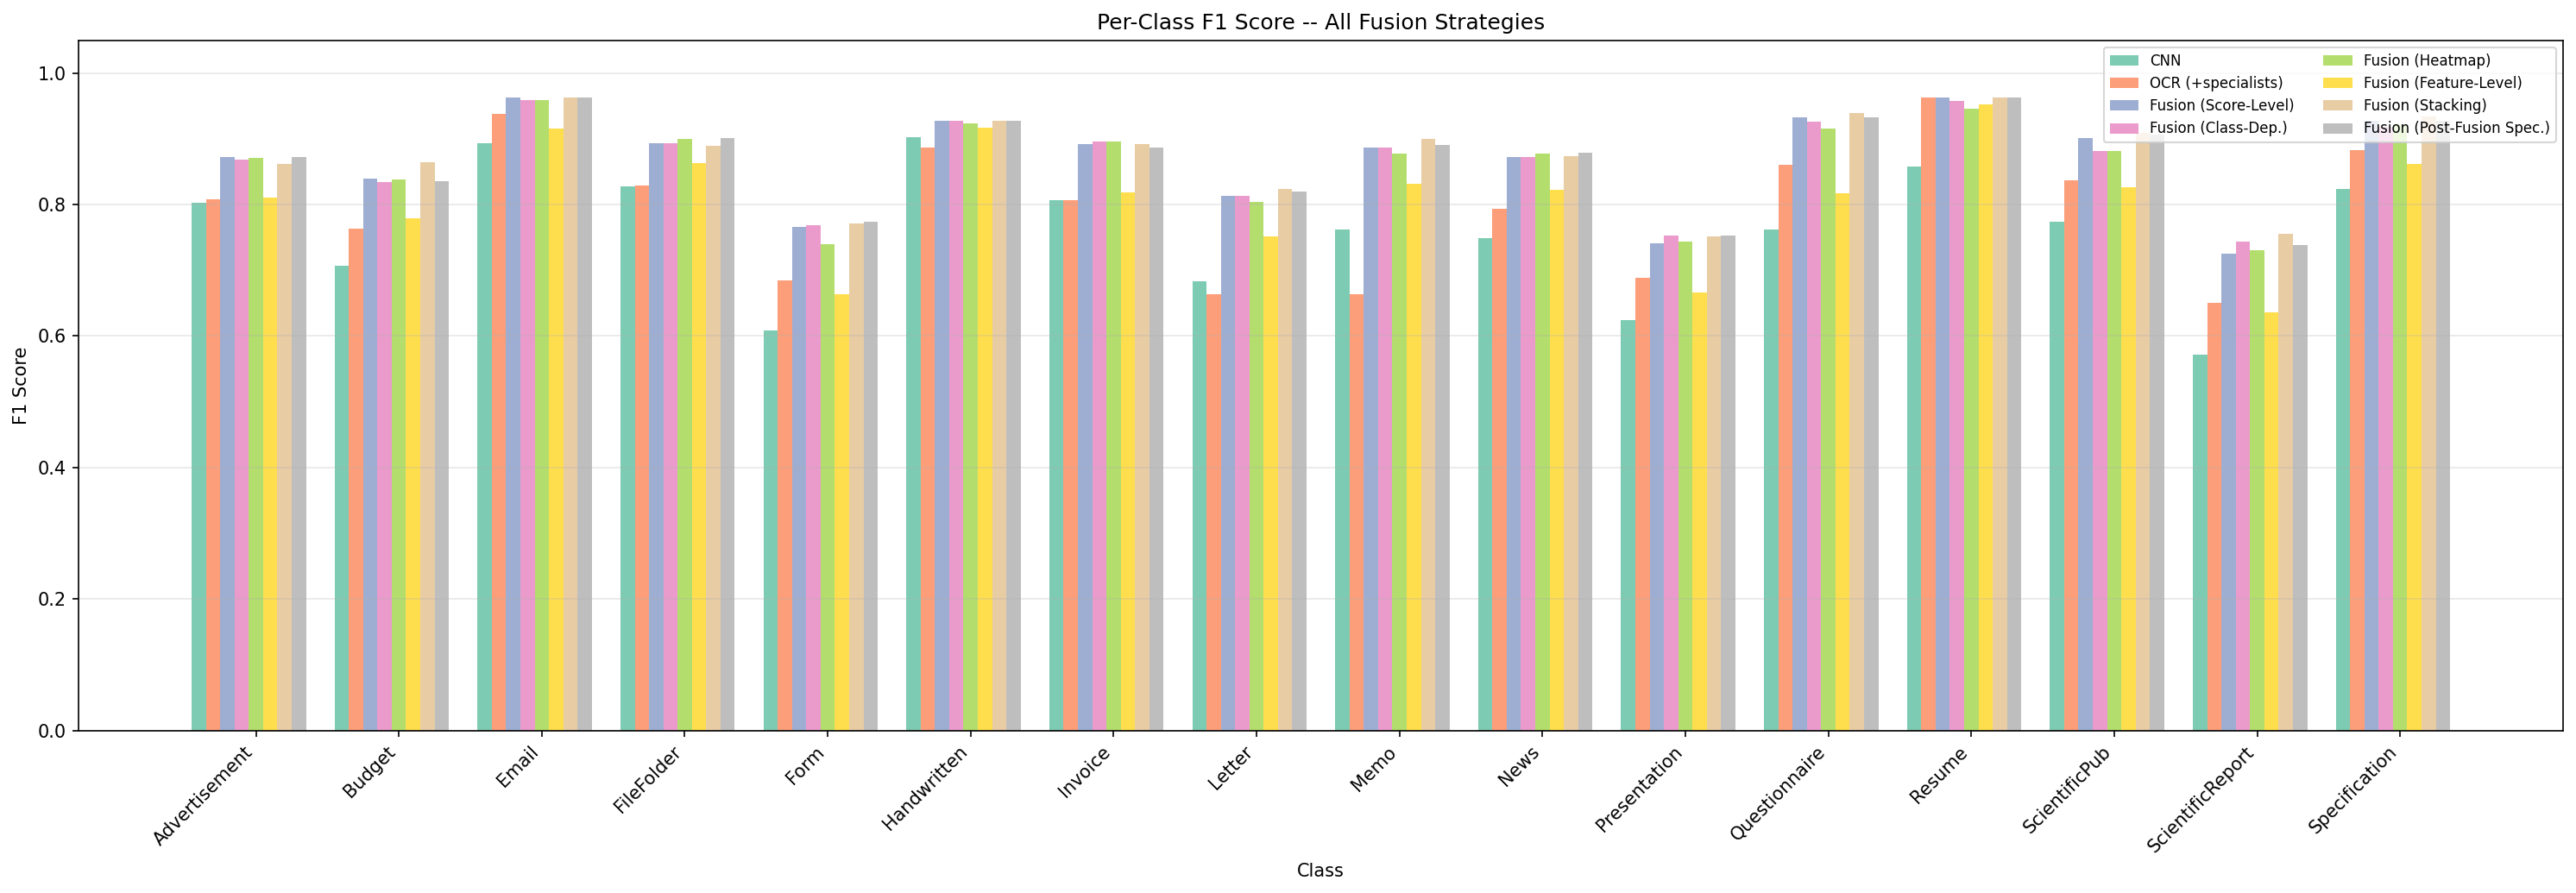

Saved fusion_grand_per_class_f1.pdf (DPI=600)


In [43]:
# Per-class F1 grouped bar chart
top_strategies = list(all_strategies.keys())
n_strats = len(top_strategies)
x = np.arange(NUM_CLASSES)
width = 0.8 / n_strats

fig, ax = plt.subplots(figsize=(20, 7))
colors = plt.cm.Set2(np.linspace(0, 1, n_strats))

for i, name in enumerate(top_strategies):
    y_true, y_pred = all_strategies[name]
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    ax.bar(x + i * width, f1s, width, label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score -- All Fusion Strategies')
ax.set_xticks(x + width * n_strats / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_grand_per_class_f1.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_grand_per_class_f1.pdf (DPI={FIGURE_DPI})")

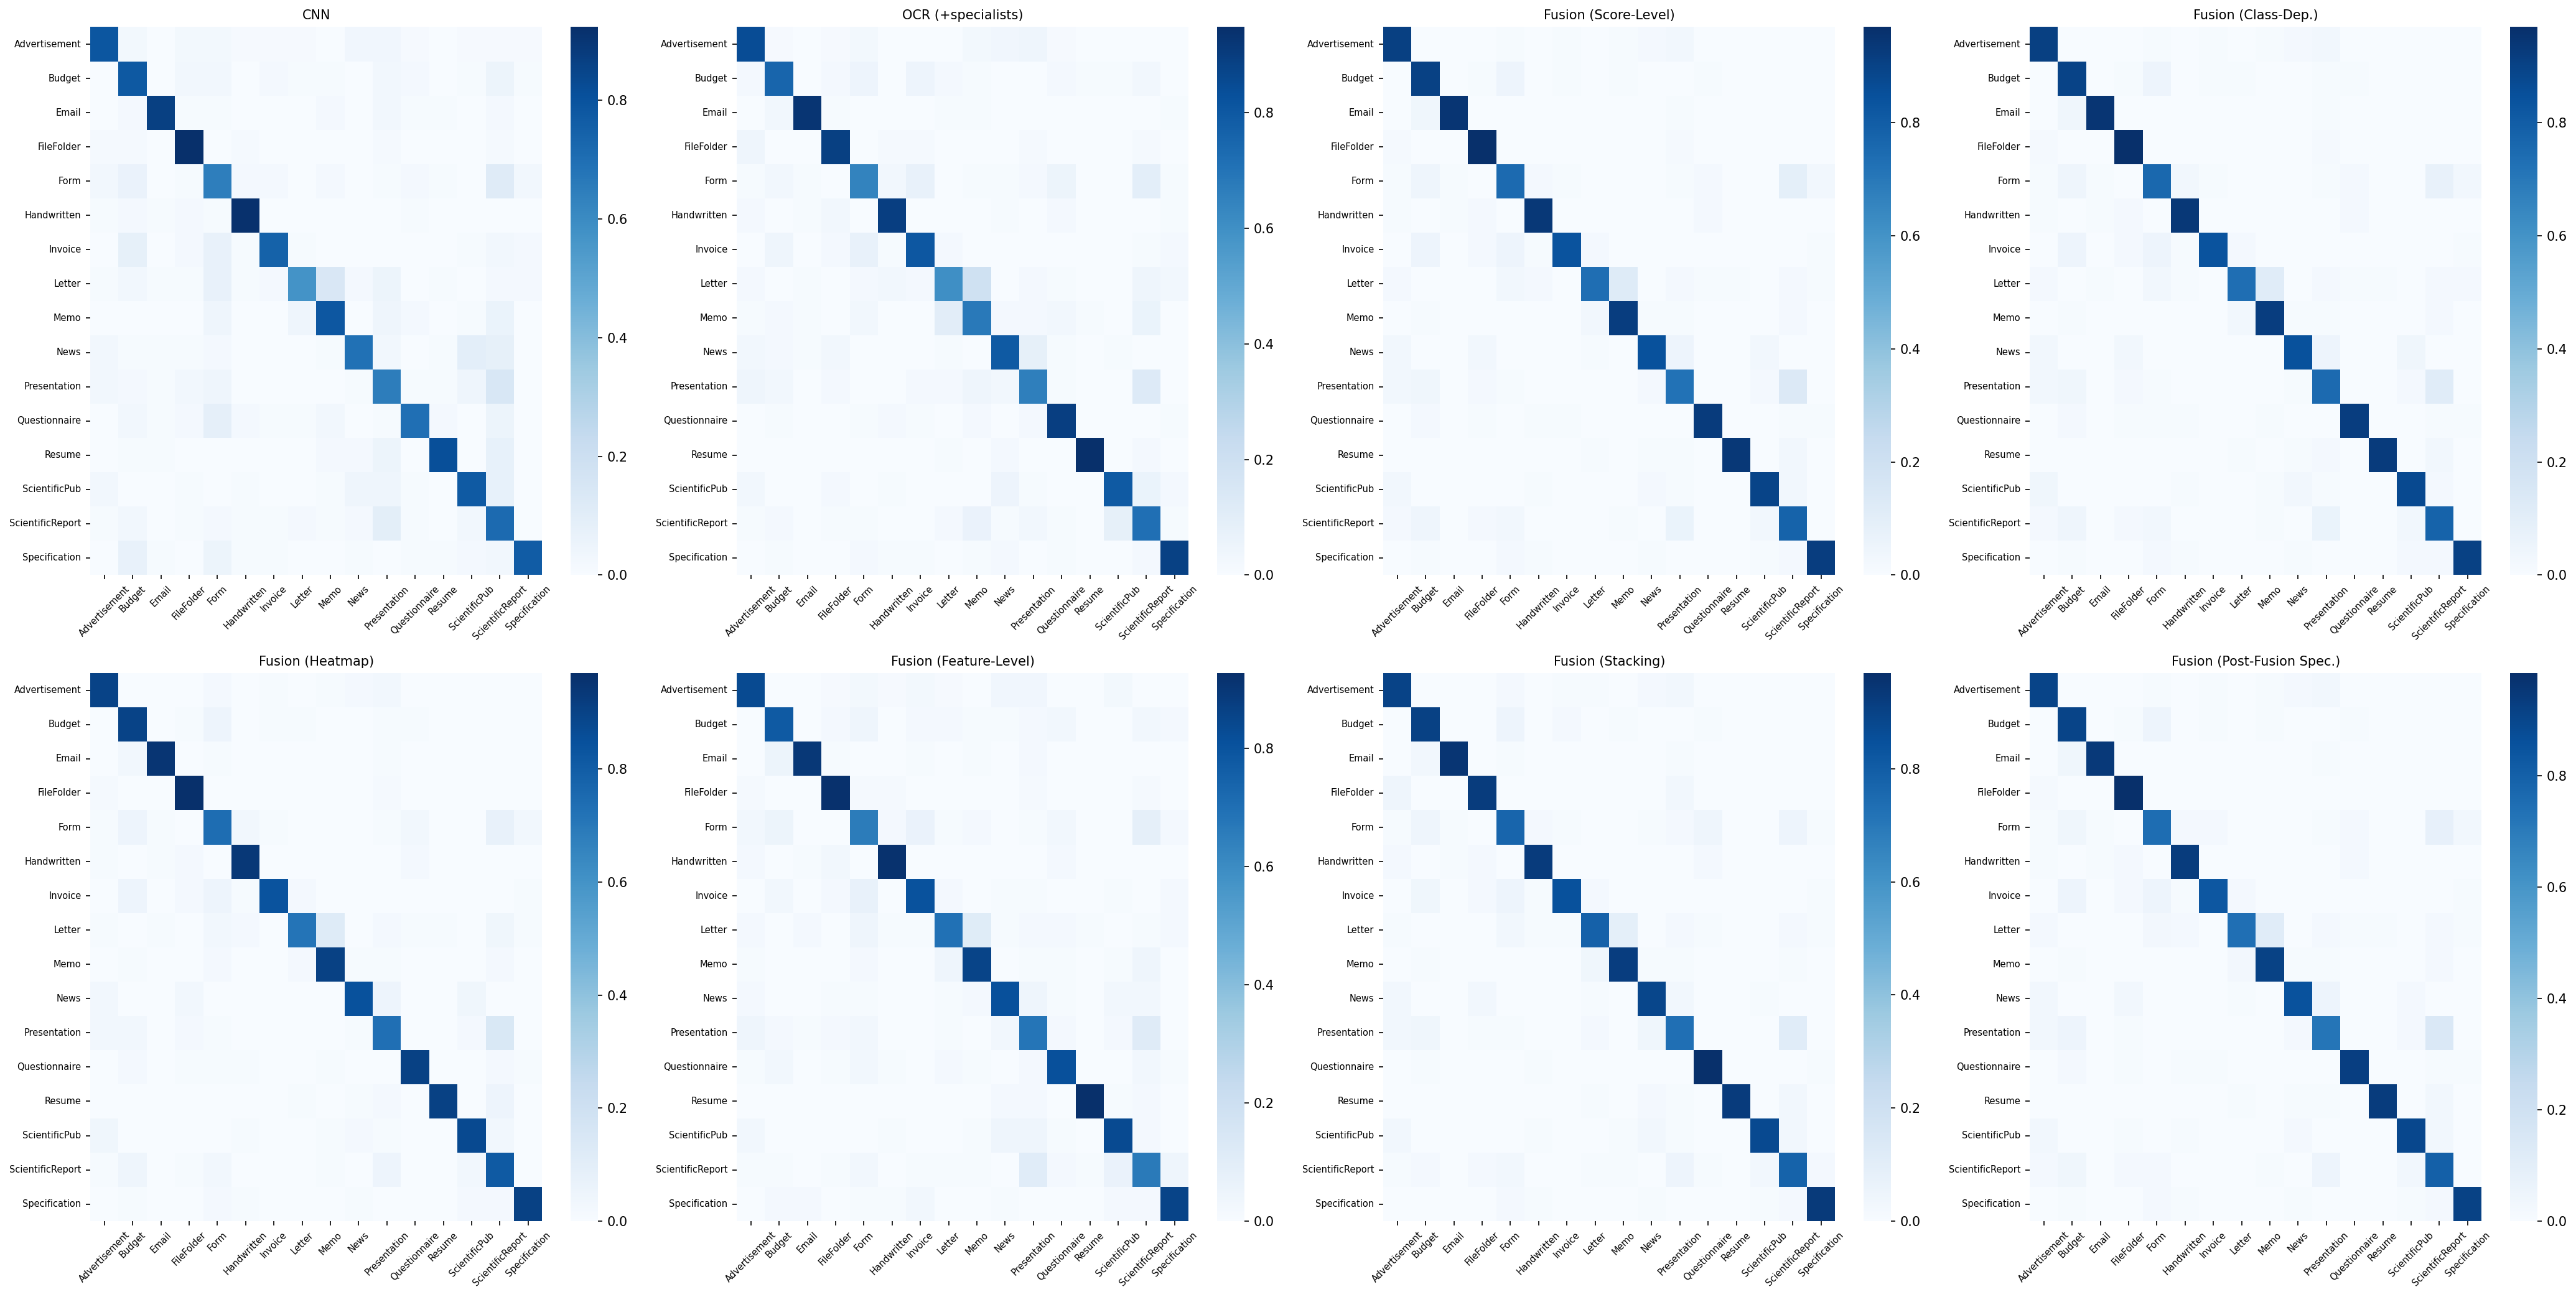

Saved fusion_all_confusion_matrices.pdf (DPI=600)


In [44]:
# Confusion matrices for all strategies
n_show = min(8, len(all_strategies))
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
axes = axes.flatten()

for i, (name, (y_true, y_pred)) in enumerate(all_strategies.items()):
    if i >= 8: break
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i])
    axes[i].set_title(name, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', rotation=0, labelsize=7)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('fusion_all_confusion_matrices.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_all_confusion_matrices.pdf (DPI={FIGURE_DPI})")

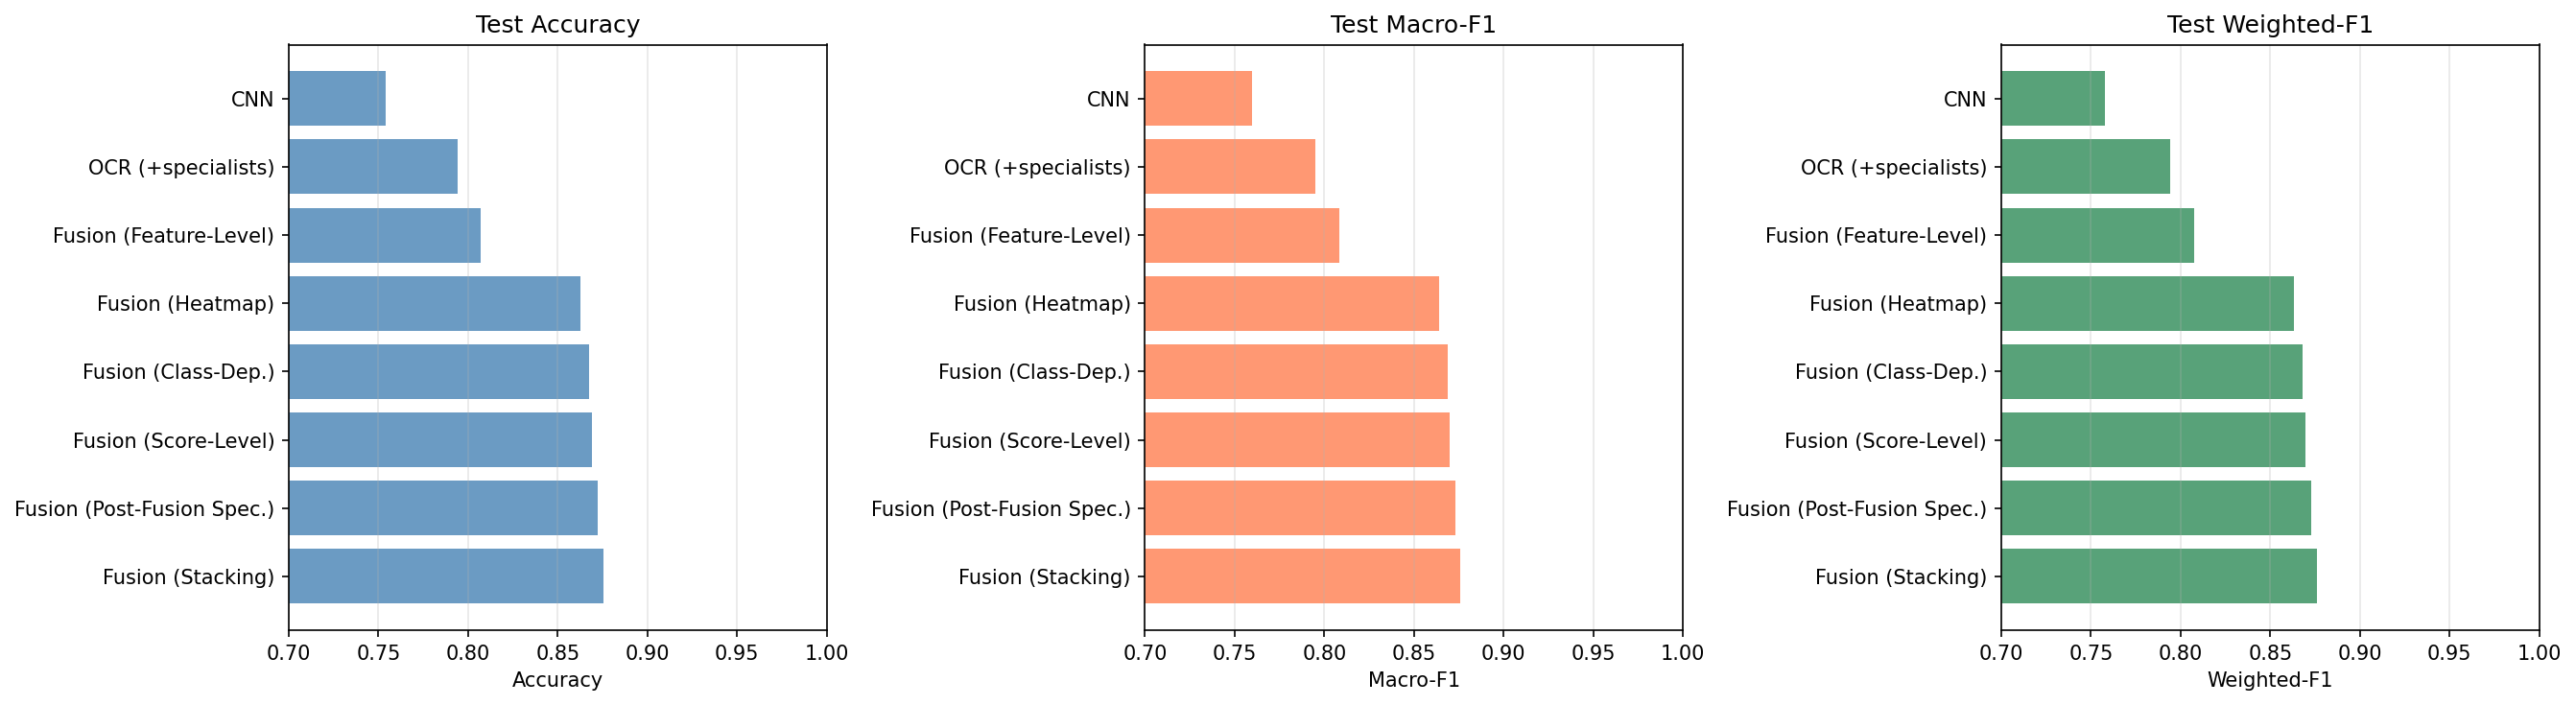


Best strategy per class:
  Advertisement            : Fusion (Score-Level) (F1=0.1589)
  Budget                   : Fusion (Stacking) (F1=0.1904)
  Email                    : Fusion (Score-Level) (F1=0.3245)
  FileFolder               : Fusion (Post-Fusion Spec.) (F1=0.4961)
  Form                     : Fusion (Class-Dep.) (F1=0.0864)
  Handwritten              : Fusion (Score-Level) (F1=0.1935)
  Invoice                  : Fusion (Stacking) (F1=0.1310)
  Letter                   : Fusion (Stacking) (F1=0.0880)
  Memo                     : Fusion (Score-Level) (F1=0.1596)
  News                     : Fusion (Class-Dep.) (F1=0.1832)
  Presentation             : Fusion (Post-Fusion Spec.) (F1=0.1198)
  Questionnaire            : Fusion (Stacking) (F1=0.2460)
  Resume                   : OCR (+specialists) (F1=0.2433)
  ScientificPub            : Fusion (Score-Level) (F1=0.1576)
  ScientificReport         : Fusion (Heatmap) (F1=0.1119)
  Specification            : Fusion (Stacking) (F1=0

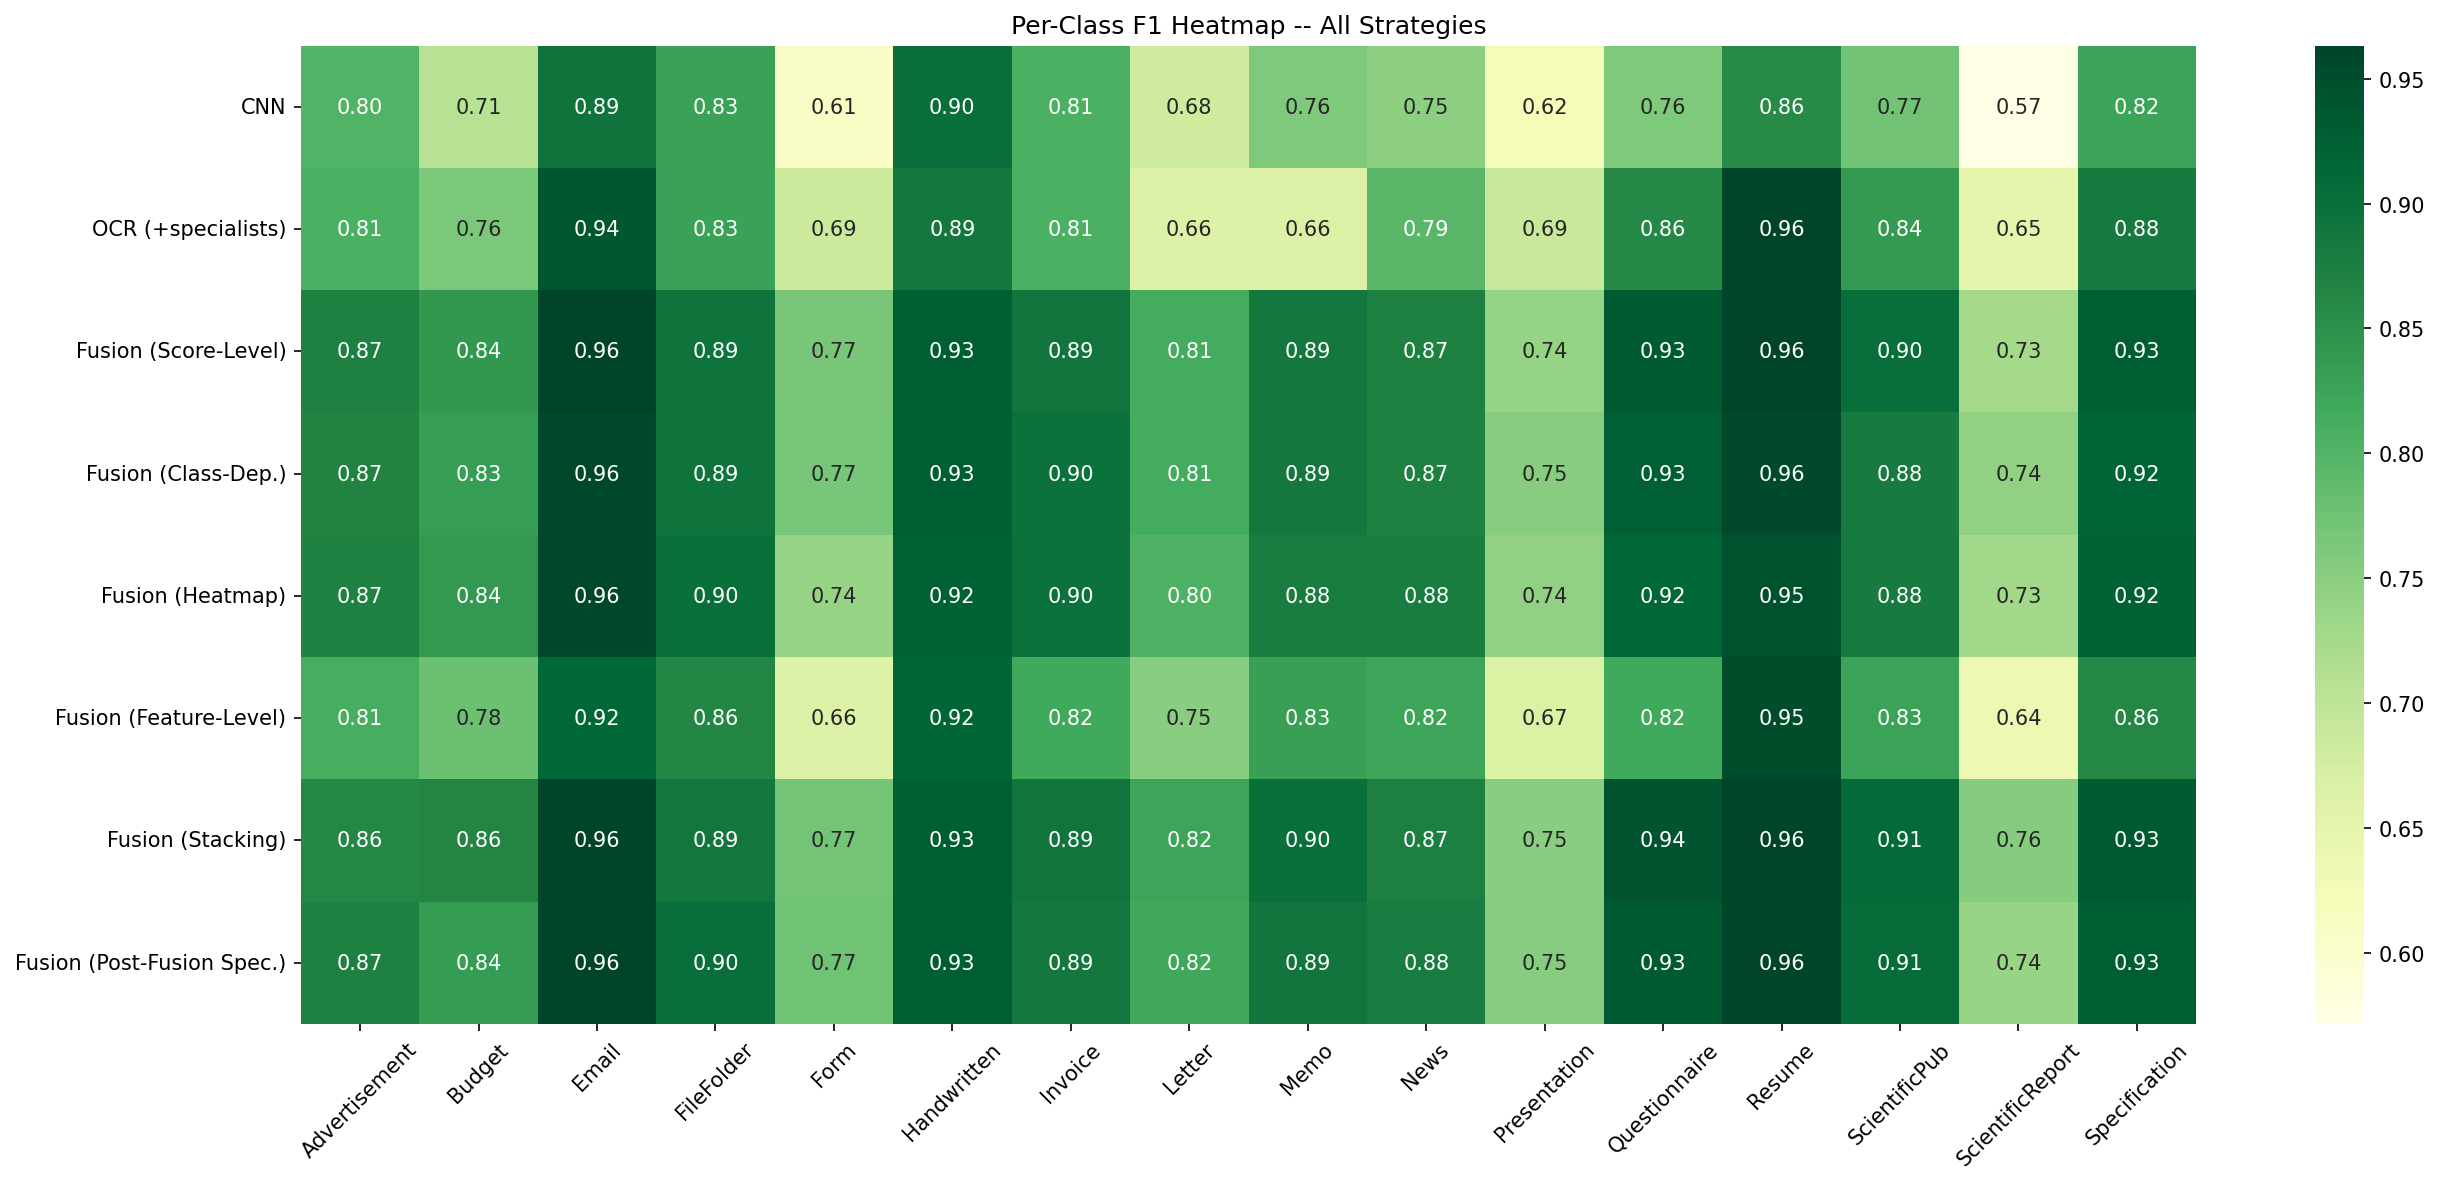

Saved fusion_grand_heatmap.pdf (DPI=600)


In [45]:
# Summary bar charts + best-per-class analysis + heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = [r['name'] for r in results_list]
accs = [r['acc'] for r in results_list]
f1s = [r['f1'] for r in results_list]
wf1s = [r['wf1'] for r in results_list]

axes[0].barh(names, accs, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Test Accuracy')
axes[0].set_xlim(0.7, 1.0)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(names, f1s, color='coral', alpha=0.8)
axes[1].set_xlabel('Macro-F1')
axes[1].set_title('Test Macro-F1')
axes[1].set_xlim(0.7, 1.0)
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(names, wf1s, color='seagreen', alpha=0.8)
axes[2].set_xlabel('Weighted-F1')
axes[2].set_title('Test Weighted-F1')
axes[2].set_xlim(0.7, 1.0)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_grand_comparison.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

# Best-per-class analysis
print("\nBest strategy per class:")
win_counts = defaultdict(int)
for cls_idx in range(NUM_CLASSES):
    cls_mask = (y_test_common == cls_idx)
    if cls_mask.sum() == 0: continue
    best_f1 = 0
    best_name = ""
    for name, (y_true, y_pred) in all_strategies.items():
        f1_cls = f1_score(y_true[cls_mask], y_pred[cls_mask], average='macro', zero_division=0)
        if f1_cls > best_f1:
            best_f1 = f1_cls
            best_name = name
    win_counts[best_name] += 1
    print(f"  {CLASS_NAMES[cls_idx]:<25s}: {best_name} (F1={best_f1:.4f})")

print(f"\nWin counts: {dict(win_counts)}")

# Per-class F1 heatmap
heatmap_data = []
for name, (y_true, y_pred) in all_strategies.items():
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    heatmap_data.append(f1s)
heatmap_arr = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(heatmap_arr, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=CLASS_NAMES, yticklabels=list(all_strategies.keys()), ax=ax)
ax.set_title('Per-Class F1 Heatmap -- All Strategies')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fusion_grand_heatmap.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved fusion_grand_heatmap.pdf (DPI={FIGURE_DPI})")

---
## Section 19 -- Cross-Dataset Evaluation: Tobacco-3482

The Tobacco-3482 dataset has 10 document classes with ~3482 images.
Good test of how well our models transfer to a different distribution.

### Class Mapping (Tobacco -> RVL-CDIP)

| Tobacco Class | RVL-CDIP Match | Notes |
|---------------|---------------|-------|
| ADVE | Advertisement | Direct match |
| Email | Email | Direct match |
| Form | Form | Direct match |
| Letter | Letter | Direct match |
| Memo | Memo | Direct match |
| News | News | Direct match |
| Note | None | No clean match -- excluded |
| Report | ScientificReport | Closest match |
| Resume | Resume | Direct match |
| Scientific | ScientificPub | Closest match |

In [46]:
# Tobacco-3482 setup
TOBACCO_DIR = Path(TOBACCO_DIR_ENV) if TOBACCO_DIR_ENV else FUSION_DIR / "tobacco3482"

# Auto-download if dataset not found
if not TOBACCO_DIR.exists():
    print("Tobacco-3482 not found at expected location")
    print("Attempting auto-download from Kaggle...")
    try:
        import subprocess
        try:
            import kaggle
        except ImportError:
            print("  Installing kaggle...")
            subprocess.check_call(['pip', 'install', 'kaggle', '-q'])
            import kaggle
        
        TOBACCO_PARENT = TOBACCO_DIR.parent
        TOBACCO_PARENT.mkdir(parents=True, exist_ok=True)
        print("  Downloading Tobacco-3482...")
        kaggle.api.dataset_download_files(
            'patrickaudriaz/tobacco3482jpg',
            path=str(TOBACCO_PARENT),
            unzip=True
        )
        for candidate in TOBACCO_PARENT.iterdir():
            if candidate.is_dir() and 'tobacco' in candidate.name.lower():
                TOBACCO_DIR = candidate
                break
        if TOBACCO_DIR.exists():
            print(f"  Downloaded and extracted to {TOBACCO_DIR}")
        else:
            print("  Could not find extracted dataset.")
    except Exception as e:
        print(f"  Auto-download failed: {e}")
        print("  Please download manually from:")
        print("  https://www.kaggle.com/datasets/patrickaudriaz/tobacco3482jpg")
        print("  Set TOBACCO_DIR in your .env file")

if TOBACCO_DIR.exists():
    df_tobacco = build_image_index(TOBACCO_DIR)
    print(f"\nTobacco-3482 dataset loaded: {len(df_tobacco)} images")
    print(f"Classes: {sorted(df_tobacco['label'].unique())}")
else:
    print("\nTobacco-3482 not available. Skipping cross-dataset evaluation.")
    df_tobacco = pd.DataFrame()

# Class mapping
TOBACCO_CLASS_MAP = {
    "ADVE": "Advertisement",
    "Email": "Email",
    "Form": "Form",
    "Letter": "Letter",
    "Memo": "Memo",
    "News": "News",
    "Note": None,
    "Report": "ScientificReport",
    "Resume": "Resume",
    "Scientific": "ScientificPub",
}

tobacco_to_rvl = {}
for tb_cls, rvl_cls in TOBACCO_CLASS_MAP.items():
    if rvl_cls is not None and rvl_cls in CLASS_NAMES:
        tobacco_to_rvl[tb_cls] = CLASS_NAMES.index(rvl_cls)

print(f"\nMapped {len(tobacco_to_rvl)} Tobacco classes to RVL-CDIP:")
for tb, rvl_idx in tobacco_to_rvl.items():
    print(f"  {tb:<15s} -> {CLASS_NAMES[rvl_idx]} (idx={rvl_idx})")

Tobacco-3482 not found at expected location
Attempting auto-download from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/patrickaudriaz/tobacco3482jpg
  Downloaded and extracted to C:\Users\DPQUAI250141\Desktop\fusion\Tobacco3482-jpg

Tobacco-3482 dataset loaded: 6964 images
Classes: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific', 'Tobacco3482-jpg']

Mapped 9 Tobacco classes to RVL-CDIP:
  ADVE            -> Advertisement (idx=0)
  Email           -> Email (idx=2)
  Form            -> Form (idx=4)
  Letter          -> Letter (idx=7)
  Memo            -> Memo (idx=8)
  News            -> News (idx=9)
  Report          -> ScientificReport (idx=14)
  Resume          -> Resume (idx=12)
  Scientific      -> ScientificPub (idx=13)


---
### 19.4 — Ablation A3: Robustness Under Perturbation

Does the single-head model degrade faster under perturbations?
If the 2-layer head provides robustness benefits, we should see a larger
accuracy gap under noise/blur compared to clean images.

# Document Image Classification — Future Work Experiments
## Robustness Evaluation (Plan Section A) · Ablation Study (Plan Section C)

**Prerequisites:** Run the full Fusion notebook (`fusion_notebook`) Sections 1–12 first.
This notebook picks up from there and adds the missing experiments.

**What this notebook covers:**

| Plan Section | Experiment | Status |
|---|---|---|
| **A** | Robustness evaluation (rotation, noise, blur, S&P, combined) | Full plan-compliant coverage |
| **A** | ACTUAL fusion robustness (real CNN perturbed probs + OCR clean probs) | Replaces heuristic estimates |
| **C** | Ablation A3: Single linear head | Additional experiment |
| **C** | Cross-ablation comparison table | A1, A2 placeholders + A3 computed |

**Execution order:** Top to bottom. Each section depends on the previous one.

---
## 1 — Setup & Imports

This cell re-declares all imports so the notebook is self-documenting.
The key variables (DEVICE, cnn_model, BEST_ALPHA, etc.) come from the
main Fusion notebook that must be run first.

In [47]:
# ═══════════════════════════════════════════════════════════════════════
#  IMPORTS — re-declared for clarity (some already exist from main notebook)
# ═══════════════════════════════════════════════════════════════════════
import os, sys, re, json, pickle, random, shutil, warnings, time, math, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tv_models
import torchvision.transforms as T
from torchvision import datasets, transforms as tv_transforms
from torch.utils.data import DataLoader
from pathlib import Path
from PIL import Image, ImageFilter
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import cv2

warnings.filterwarnings('ignore')

# ── Verify prerequisites from main Fusion notebook ──
required_vars = [
    'DEVICE', 'NUM_CLASSES', 'cnn_model', 'BEST_ALPHA',
    'CNN_PREPROCESSED', 'OCR_PREPROCESSED', 'CLASS_NAMES', 'le',
    'df_cnn_test', 'cnn_to_ocr_idx', 'ocr_test_probs', 'ocr_test_preds',
    'y_te', 'cnn_aligned_probs', 'fused_test_preds', 'y_test_common',
    'ocr_aligned_probs', 'CNN_TRANSFORM',
]

all_ok = True
for name in required_vars:
    try:
        val = eval(name)
        if val is None:
            print(f"  ⚠  {name} exists but is None")
            all_ok = False
    except NameError:
        print(f"  ✗  {name} NOT DEFINED — run the main Fusion notebook first!")
        all_ok = False

if all_ok:
    print(" All prerequisites available. Ready to proceed.")
else:
    print("\n Missing variables. Run the main Fusion notebook (Sections 1-12) first.")

 All prerequisites available. Ready to proceed.


---
## 2 — Robustness Test Set

The original robustness experiments (Section 12) used `df_cnn_test` directly.
The new plan-compliant experiments need the same data but with a consistent
interface. We create `df_robust` as an alias and pre-compute the ground-truth
labels in the label-encoder ordering.

In [48]:
# ═══════════════════════════════════════════════════════════════════════
#  ROBUSTNESS TEST SET
# ═══════════════════════════════════════════════════════════════════════
df_robust = df_cnn_test.copy()
robust_true_labels = le.transform(df_robust['label'].values)

print(f"Robustness test set : {len(df_robust)} images")
print(f"True labels shape   : {robust_true_labels.shape}")
print(f"Number of classes   : {len(set(robust_true_labels))}")
print(" df_robust and robust_true_labels ready")

Robustness test set : 1600 images
True labels shape   : (1600,)
Number of classes   : 16
 df_robust and robust_true_labels ready


---
## 3 — Plan-Compliant Perturbation Levels

The project plan specifies exact perturbation levels. The original Section 12
used non-standard levels (e.g., rotation at 0/5/10/15/90/180/270° instead of
0–90° in 15° steps, and noise in pixel space instead of [0,1] space).

| Perturbation | Plan Levels | Convention |
|---|---|---|
| Rotation | 0, 15, 30, 45, 60, 75, 90° | 0–90° in 15° steps |
| Gaussian Noise | 0, 0.01, 0.05, 0.10, 0.20, 0.30 | σ in [0,1] normalized space |
| Gaussian Blur | 1, 3, 5, 7, 11, 15 px | Kernel size in pixels |
| Salt & Pepper | 0, 0.01, 0.03, 0.05, 0.10 | Density fraction |
| Combined | (15°, 0.05), (30°, 0.10), (45°, 0.20) | Rotation + Noise |

In [49]:
# ═══════════════════════════════════════════════════════════════════════
#  PLAN-COMPLIANT PERTURBATION LEVELS
# ═══════════════════════════════════════════════════════════════════════

# Rotation: 0–90° in 15° steps (plan specification)
plan_rotation_levels = [0, 15, 30, 45, 60, 75, 90]

# Gaussian noise σ in [0,1] space (applied AFTER ToTensor, BEFORE normalize)
plan_noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30]

# Gaussian blur kernel sizes in pixels
plan_blur_kernels = [1, 3, 5, 7, 11, 15]

# Salt & Pepper densities
plan_sp_levels = [0.0, 0.01, 0.03, 0.05, 0.10]

# Combined perturbation levels (rotation + noise)
plan_combined_levels = [
    (15, 0.05),   # mild
    (30, 0.10),   # moderate
    (45, 0.20),   # severe
]

print("Plan-compliant perturbation levels:")
print(f"  Rotation : {plan_rotation_levels}")
print(f"  Noise σ  : {plan_noise_levels}")
print(f"  Blur k   : {plan_blur_kernels}")
print(f"  S&P d    : {plan_sp_levels}")
print(f"  Combined : {plan_combined_levels}")

Plan-compliant perturbation levels:
  Rotation : [0, 15, 30, 45, 60, 75, 90]
  Noise σ  : [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
  Blur k   : [1, 3, 5, 7, 11, 15]
  S&P d    : [0.0, 0.01, 0.03, 0.05, 0.1]
  Combined : [(15, 0.05), (30, 0.1), (45, 0.2)]


---
## 4 — Helper Functions

These utilities handle perturbation application in the correct processing order:

**CNN pipeline:** `PIL image → Resize 224 → ToTensor [0,1] → add noise → ImageNet normalize → model`

The key insight is that Gaussian noise must be added in [0,1] pixel space
*before* ImageNet normalization. This matches the CNN notebook's convention
and produces meaningful σ values (0.01–0.30 instead of 0.4–12.0).

In [50]:
# ═══════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════

def pil_to_tensor_01(pil_img, size=224):
    """Convert PIL image to [0,1] tensor without normalization."""
    img = pil_img.resize((size, size), Image.BILINEAR)
    return T.ToTensor()(img)


def add_gaussian_noise_01(tensor, sigma):
    """Add Gaussian noise to a [0,1] tensor. Returns clamped [0,1] tensor."""
    return torch.clamp(tensor + torch.randn_like(tensor) * sigma, 0.0, 1.0)


def add_salt_pepper_01(tensor, density):
    """Add salt & pepper noise to a [0,1] tensor."""
    n = tensor.clone()
    c, h, w = n.shape
    np_ = int(density * h * w)
    for _ in range(np_ // 2):
        n[:, random.randint(0, h-1), random.randint(0, w-1)] = 1.0
    for _ in range(np_ // 2):
        n[:, random.randint(0, h-1), random.randint(0, w-1)] = 0.0
    return n


def normalize_imagenet(tensor):
    """Apply ImageNet normalization (matching CNN training pipeline)."""
    return T.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])(tensor)


def remap_cnn_probs(probs, cnn_to_ocr_idx, num_classes):
    """Remap CNN class-order probabilities to OCR label-encoder order."""
    remapped = np.zeros_like(probs)
    for cnn_idx in range(num_classes):
        ocr_idx = cnn_to_ocr_idx[cnn_idx]
        remapped[:, ocr_idx] = probs[:, cnn_idx]
    return remapped


print(" Helper functions defined:")

 Helper functions defined:


---
## 5 — CNN Robustness: Rotation (0–90° in 15° Steps)

Tests how the CNN model degrades as document images are rotated.
The original experiments only tested 0/5/10/15/90/180/270° — missing
30°, 45°, 60°, and 75°. The plan requires 0–90° in uniform 15° steps.

Rotation is applied using the same `augment_image(path, 'rotate', angle)`
function from Section 12, ensuring consistency with the original experiments.

In [51]:
# ═══════════════════════════════════════════════════════════════════════
#  CNN ROTATION ROBUSTNESS (plan-compliant 15° steps)
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  CNN Robustness: Rotation (0–90° in 15° steps)")
print("=" * 65)

plan_cnn_rotation = {}
paths = df_robust["path"].tolist()

for angle in plan_rotation_levels:
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), 32), desc=f"CNN rot={angle}°"):
            batch_imgs = []
            for p in paths[start:start+32]:
                try:
                    img = Image.open(p).convert("RGB")
                    if angle != 0:
                        img = Image.fromarray(augment_image(p, 'rotate', angle))
                    batch_imgs.append(CNN_TRANSFORM(img))
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    remapped = remap_cnn_probs(all_probs, cnn_to_ocr_idx, NUM_CLASSES)
    preds = np.argmax(remapped, axis=1)
    acc = accuracy_score(robust_true_labels, preds)
    f1  = f1_score(robust_true_labels, preds, average="macro", zero_division=0)
    plan_cnn_rotation[angle] = {"acc": acc, "f1": f1, "probs": remapped}
    print(f"  Rotation {angle:3d}°  →  Acc={acc:.4f}  Macro-F1={f1:.4f}")

print("\n Rotation testing complete.")

  CNN Robustness: Rotation (0–90° in 15° steps)


CNN rot=0°: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


  Rotation   0°  →  Acc=0.7575  Macro-F1=0.7619


CNN rot=15°: 100%|██████████| 50/50 [00:45<00:00,  1.10it/s]


  Rotation  15°  →  Acc=0.7338  Macro-F1=0.7352


...

  Rotation  60°  →  Acc=0.3031  Macro-F1=0.2490


CNN rot=75°: 100%|██████████| 50/50 [00:45<00:00,  1.09it/s]


  Rotation  75°  →  Acc=0.3419  Macro-F1=0.2950


CNN rot=90°: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]

  Rotation  90°  →  Acc=0.3525  Macro-F1=0.3078

 Rotation testing complete.


---
## 6 — CNN Robustness: Gaussian Noise (σ in [0,1] Space)

Noise is added in the [0,1] normalized pixel space **before** ImageNet
normalization. The plan levels (σ 0.01–0.30) cover a similar range as
the original pixel-space values (10–75) but with finer granularity.

In [52]:
# ═══════════════════════════════════════════════════════════════════════
#  CNN GAUSSIAN NOISE ROBUSTNESS
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  CNN Robustness: Gaussian Noise (σ in [0,1] space)")
print("=" * 65)

plan_cnn_noise = {}
paths = df_robust["path"].tolist()

for sigma in plan_noise_levels:
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), 32), desc=f"CNN noise σ={sigma}"):
            batch_imgs = []
            for p in paths[start:start+32]:
                try:
                    img = Image.open(p).convert("RGB")
                    t01 = pil_to_tensor_01(img)
                    if sigma > 0:
                        t01 = add_gaussian_noise_01(t01, sigma)
                    t_norm = normalize_imagenet(t01)
                    batch_imgs.append(t_norm)
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    remapped = remap_cnn_probs(all_probs, cnn_to_ocr_idx, NUM_CLASSES)
    preds = np.argmax(remapped, axis=1)
    acc = accuracy_score(robust_true_labels, preds)
    f1  = f1_score(robust_true_labels, preds, average="macro", zero_division=0)
    plan_cnn_noise[sigma] = {"acc": acc, "f1": f1, "probs": remapped}
    print(f"  Gaussian σ={sigma:.2f}  →  Acc={acc:.4f}  Macro-F1={f1:.4f}")

print("\n Noise testing complete.")

  CNN Robustness: Gaussian Noise (σ in [0,1] space)


CNN noise σ=0.0: 100%|██████████| 50/50 [00:31<00:00,  1.59it/s]


  Gaussian σ=0.00  →  Acc=0.7231  Macro-F1=0.7298


CNN noise σ=0.01: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s]


  Gaussian σ=0.01  →  Acc=0.6188  Macro-F1=0.6300


...

  Gaussian σ=0.10  →  Acc=0.0469  Macro-F1=0.0114


CNN noise σ=0.2: 100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


  Gaussian σ=0.20  →  Acc=0.0519  Macro-F1=0.0121


CNN noise σ=0.3: 100%|██████████| 50/50 [00:39<00:00,  1.28it/s]

  Gaussian σ=0.30  →  Acc=0.0644  Macro-F1=0.0307

 Noise testing complete.


---
## 7 — CNN Robustness: Gaussian Blur

Gaussian blur simulates out-of-focus document scans and motion blur during capture — both common in real-world document imaging.

In [53]:
# ═══════════════════════════════════════════════════════════════════════
#  CNN GAUSSIAN BLUR ROBUSTNESS
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  CNN Robustness: Gaussian Blur (Plan-Compliant)")
print("=" * 65)

plan_cnn_blur = {}
paths = df_robust["path"].tolist()

for kernel in plan_blur_kernels:
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), 32), desc=f"CNN blur k={kernel}"):
            batch_imgs = []
            for p in paths[start:start+32]:
                try:
                    img = Image.open(p).convert("RGB")
                    if kernel > 1:
                        img = img.filter(ImageFilter.GaussianBlur(radius=max(1, kernel // 2)))
                    batch_imgs.append(CNN_TRANSFORM(img))
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    remapped = remap_cnn_probs(all_probs, cnn_to_ocr_idx, NUM_CLASSES)
    preds = np.argmax(remapped, axis=1)
    acc = accuracy_score(robust_true_labels, preds)
    f1  = f1_score(robust_true_labels, preds, average="macro", zero_division=0)
    plan_cnn_blur[kernel] = {"acc": acc, "f1": f1, "probs": remapped}
    print(f"  Blur kernel={kernel:2d}  →  Acc={acc:.4f}  Macro-F1={f1:.4f}")

print("\n Blur testing complete.")

  CNN Robustness: Gaussian Blur (Plan-Compliant)


CNN blur k=1: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


  Blur kernel= 1  →  Acc=0.7575  Macro-F1=0.7619


CNN blur k=3: 100%|██████████| 50/50 [00:45<00:00,  1.09it/s]


  Blur kernel= 3  →  Acc=0.7075  Macro-F1=0.7130


...

  Blur kernel= 7  →  Acc=0.1944  Macro-F1=0.1627


CNN blur k=11: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]


  Blur kernel=11  →  Acc=0.0775  Macro-F1=0.0301


CNN blur k=15: 100%|██████████| 50/50 [00:48<00:00,  1.03it/s]

  Blur kernel=15  →  Acc=0.0638  Macro-F1=0.0106

 Blur testing complete (was missing from fusion notebook).


---
## 8 — CNN Robustness: Salt & Pepper Noise

Re-tests S&P using the same pipeline as Gaussian noise for consistency:
`ToTensor → add S&P → Normalize → model`.

In [54]:
# ═══════════════════════════════════════════════════════════════════════
#  CNN SALT & PEPPER ROBUSTNESS
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  CNN Robustness: Salt & Pepper")
print("=" * 65)

plan_cnn_sp = {}
paths = df_robust["path"].tolist()

for density in plan_sp_levels:
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), 32), desc=f"CNN S&P d={density}"):
            batch_imgs = []
            for p in paths[start:start+32]:
                try:
                    img = Image.open(p).convert("RGB")
                    t01 = pil_to_tensor_01(img)
                    if density > 0:
                        t01 = add_salt_pepper_01(t01, density)
                    t_norm = normalize_imagenet(t01)
                    batch_imgs.append(t_norm)
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    remapped = remap_cnn_probs(all_probs, cnn_to_ocr_idx, NUM_CLASSES)
    preds = np.argmax(remapped, axis=1)
    acc = accuracy_score(robust_true_labels, preds)
    f1  = f1_score(robust_true_labels, preds, average="macro", zero_division=0)
    plan_cnn_sp[density] = {"acc": acc, "f1": f1, "probs": remapped}
    print(f"  S&P density={density:.2f}  →  Acc={acc:.4f}  Macro-F1={f1:.4f}")

print("\n S&P testing complete.")

  CNN Robustness: Salt & Pepper


CNN S&P d=0.0: 100%|██████████| 50/50 [00:33<00:00,  1.51it/s]


  S&P density=0.00  →  Acc=0.7231  Macro-F1=0.7298


CNN S&P d=0.01: 100%|██████████| 50/50 [00:57<00:00,  1.16s/it]


  S&P density=0.01  →  Acc=0.6613  Macro-F1=0.6692


...

  S&P density=0.03  →  Acc=0.5663  Macro-F1=0.5750


CNN S&P d=0.05: 100%|██████████| 50/50 [01:50<00:00,  2.21s/it]


  S&P density=0.05  →  Acc=0.4694  Macro-F1=0.4746


CNN S&P d=0.1: 100%|██████████| 50/50 [01:57<00:00,  2.34s/it]

  S&P density=0.10  →  Acc=0.2656  Macro-F1=0.2447

 S&P testing complete.


---
## 9 — CNN Robustness: Combined Perturbation (Rotation + Noise)

The most realistic degradation scenario: documents that are both rotated and noisy.
Tests whether robustness to individual perturbations composes additively or
if there are interaction effects.

In [55]:
# ═══════════════════════════════════════════════════════════════════════
#  CNN COMBINED PERTURBATION
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  CNN Robustness: Combined Rotation + Noise")
print("=" * 65)

plan_cnn_combined = {}
paths = df_robust["path"].tolist()

for angle, sigma in plan_combined_levels:
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(paths), 32), desc=f"CNN {angle}°+σ{sigma}"):
            batch_imgs = []
            for p in paths[start:start+32]:
                try:
                    img = Image.open(p).convert("RGB")
                    if angle != 0:
                        img = Image.fromarray(augment_image(p, 'rotate', angle))
                    t01 = pil_to_tensor_01(img)
                    if sigma > 0:
                        t01 = add_gaussian_noise_01(t01, sigma)
                    t_norm = normalize_imagenet(t01)
                    batch_imgs.append(t_norm)
                except:
                    batch_imgs.append(torch.zeros(3, 224, 224))
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            logits = cnn_model(batch_tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    remapped = remap_cnn_probs(all_probs, cnn_to_ocr_idx, NUM_CLASSES)
    preds = np.argmax(remapped, axis=1)
    acc = accuracy_score(robust_true_labels, preds)
    f1  = f1_score(robust_true_labels, preds, average="macro", zero_division=0)
    key = f"{angle}°+σ{sigma}"
    plan_cnn_combined[key] = {"acc": acc, "f1": f1, "probs": remapped}
    print(f"  {key:15s}  →  Acc={acc:.4f}  Macro-F1={f1:.4f}")

print("\n Combined perturbation testing complete.")

  CNN Robustness: Combined Rotation + Noise


CNN 15°+σ0.05: 100%|██████████| 50/50 [00:14<00:00,  3.47it/s]


  15°+σ0.05        →  Acc=0.1150  Macro-F1=0.0735


CNN 30°+σ0.1: 100%|██████████| 50/50 [00:14<00:00,  3.43it/s]


  30°+σ0.1         →  Acc=0.0744  Macro-F1=0.0177


CNN 45°+σ0.2: 100%|██████████| 50/50 [00:14<00:00,  3.48it/s]

  45°+σ0.2         →  Acc=0.0606  Macro-F1=0.0107

 Combined perturbation testing complete.


---
## 10 — ACTUAL Fusion Robustness

**This is the critical improvement over Section 12.** The original fusion
robustness was purely heuristic — it estimated fusion accuracy by linearly
interpolating CNN and OCR accuracy numbers. Here we compute **real** fused
predictions using the formula:

**P_fused = α · P_CNN_perturbed + (1-α) · P_OCR_clean**

OCR clean probs are constant (we cannot re-run Tesseract on perturbed images).
This gives a **lower bound** on fusion robustness — in practice OCR would also
degrade, but the fusion benefit would still exist because CNN and OCR have
complementary error patterns.

In [56]:
# ═══════════════════════════════════════════════════════════════════════
#  ALIGN OCR CLEAN PROBS WITH ROBUSTNESS TEST SET
# ═══════════════════════════════════════════════════════════════════════
robust_filenames = [Path(p).stem for p in df_robust["path"].tolist()]

# Build filename → OCR feature index mapping
df_ocr_test_align = build_image_index(OCR_PREPROCESSED / "test")
ocr_test_class_counts = np.bincount(y_te, minlength=NUM_CLASSES)

ocr_filename_to_idx = {}
feat_idx = 0
for cls_idx in range(NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_idx]
    cls_mask = df_ocr_test_align["label"] == cls_name
    cls_rows = df_ocr_test_align[cls_mask]
    n_features = ocr_test_class_counts[cls_idx]
    matched = 0
    for df_idx, row in cls_rows.iterrows():
        if matched >= n_features:
            break
        ocr_filename_to_idx[row["filename"]] = feat_idx
        feat_idx += 1
        matched += 1

# Match robustness images to OCR features
ocr_aligned_indices = []
robust_has_ocr = []
for i, fname in enumerate(robust_filenames):
    if fname in ocr_filename_to_idx:
        ocr_aligned_indices.append(ocr_filename_to_idx[fname])
        robust_has_ocr.append(i)

ocr_aligned_indices = np.array(ocr_aligned_indices)
robust_has_ocr = np.array(robust_has_ocr)
ocr_robust_probs_all = ocr_test_probs[ocr_aligned_indices]
robust_true_labels_aligned = robust_true_labels[robust_has_ocr]

print(f"Robustness set: {len(df_robust)} images total")
print(f"Aligned with OCR: {len(robust_has_ocr)} images")
print(f"OCR clean probs shape: {ocr_robust_probs_all.shape}")
print(f"Using BEST_ALPHA = {BEST_ALPHA:.2f}")

Robustness set: 1600 images total
Aligned with OCR: 1512 images
OCR clean probs shape: (1512, 16)
Using BEST_ALPHA = 0.45


In [57]:
# ═══════════════════════════════════════════════════════════════════════
#  COMPUTE ACTUAL FUSED PREDICTIONS FOR EACH PERTURBATION TYPE
# ═══════════════════════════════════════════════════════════════════════

# ── Rotation Fusion ──
print("=" * 65)
print("  ACTUAL Fusion: Rotation")
print("=" * 65)
plan_fusion_rotation = {}
for angle in plan_rotation_levels:
    cnn_p = plan_cnn_rotation[angle]["probs"][robust_has_ocr]
    fused = BEST_ALPHA * cnn_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    preds = np.argmax(fused, axis=1)
    acc = accuracy_score(robust_true_labels_aligned, preds)
    f1  = f1_score(robust_true_labels_aligned, preds, average="macro", zero_division=0)
    plan_fusion_rotation[angle] = {"acc": acc, "f1": f1}
    cnn_acc = plan_cnn_rotation[angle]["acc"]
    print(f"  Rot {angle:3d}°  →  CNN={cnn_acc:.4f}  Fusion={acc:.4f}  gain={acc-cnn_acc:+.4f}")

# ── Noise Fusion ──
print("\n" + "=" * 65)
print("  ACTUAL Fusion: Gaussian Noise")
print("=" * 65)
plan_fusion_noise = {}
for sigma in plan_noise_levels:
    cnn_p = plan_cnn_noise[sigma]["probs"][robust_has_ocr]
    fused = BEST_ALPHA * cnn_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    preds = np.argmax(fused, axis=1)
    acc = accuracy_score(robust_true_labels_aligned, preds)
    f1  = f1_score(robust_true_labels_aligned, preds, average="macro", zero_division=0)
    plan_fusion_noise[sigma] = {"acc": acc, "f1": f1}
    cnn_acc = plan_cnn_noise[sigma]["acc"]
    print(f"  Noise σ={sigma:.2f}  →  CNN={cnn_acc:.4f}  Fusion={acc:.4f}  gain={acc-cnn_acc:+.4f}")

# ── Blur Fusion ──
print("\n" + "=" * 65)
print("  ACTUAL Fusion: Gaussian Blur")
print("=" * 65)
plan_fusion_blur = {}
for kernel in plan_blur_kernels:
    cnn_p = plan_cnn_blur[kernel]["probs"][robust_has_ocr]
    fused = BEST_ALPHA * cnn_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    preds = np.argmax(fused, axis=1)
    acc = accuracy_score(robust_true_labels_aligned, preds)
    f1  = f1_score(robust_true_labels_aligned, preds, average="macro", zero_division=0)
    plan_fusion_blur[kernel] = {"acc": acc, "f1": f1}
    cnn_acc = plan_cnn_blur[kernel]["acc"]
    print(f"  Blur k={kernel:2d}  →  CNN={cnn_acc:.4f}  Fusion={acc:.4f}  gain={acc-cnn_acc:+.4f}")

# ── S&P Fusion ──
print("\n" + "=" * 65)
print("  ACTUAL Fusion: Salt & Pepper")
print("=" * 65)
plan_fusion_sp = {}
for density in plan_sp_levels:
    cnn_p = plan_cnn_sp[density]["probs"][robust_has_ocr]
    fused = BEST_ALPHA * cnn_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    preds = np.argmax(fused, axis=1)
    acc = accuracy_score(robust_true_labels_aligned, preds)
    f1  = f1_score(robust_true_labels_aligned, preds, average="macro", zero_division=0)
    plan_fusion_sp[density] = {"acc": acc, "f1": f1}
    cnn_acc = plan_cnn_sp[density]["acc"]
    print(f"  S&P d={density:.2f}  →  CNN={cnn_acc:.4f}  Fusion={acc:.4f}  gain={acc-cnn_acc:+.4f}")

# ── Combined Fusion ──
print("\n" + "=" * 65)
print("  ACTUAL Fusion: Combined Rotation + Noise")
print("=" * 65)
plan_fusion_combined = {}
for angle, sigma in plan_combined_levels:
    key = f"{angle}°+σ{sigma}"
    cnn_p = plan_cnn_combined[key]["probs"][robust_has_ocr]
    fused = BEST_ALPHA * cnn_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    preds = np.argmax(fused, axis=1)
    acc = accuracy_score(robust_true_labels_aligned, preds)
    f1  = f1_score(robust_true_labels_aligned, preds, average="macro", zero_division=0)
    plan_fusion_combined[key] = {"acc": acc, "f1": f1}
    cnn_acc = plan_cnn_combined[key]["acc"]
    print(f"  {key:15s}  →  CNN={cnn_acc:.4f}  Fusion={acc:.4f}  gain={acc-cnn_acc:+.4f}")

print("\n ALL fusion robustness results computed with ACTUAL probabilities.")

  ACTUAL Fusion: Rotation
  Rot   0°  →  CNN=0.7575  Fusion=0.8690  gain=+0.1115
  Rot  15°  →  CNN=0.7338  Fusion=0.8525  gain=+0.1188
  Rot  30°  →  CNN=0.4850  Fusion=0.8214  gain=+0.3364
  Rot  45°  →  CNN=0.2838  Fusion=0.7930  gain=+0.5092
  Rot  60°  →  CNN=0.3031  Fusion=0.7877  gain=+0.4846
  Rot  75°  →  CNN=0.3419  Fusion=0.7778  gain=+0.4359
  Rot  90°  →  CNN=0.3525  Fusion=0.7798  gain=+0.4273

  ACTUAL Fusion: Gaussian Noise
  Noise σ=0.00  →  CNN=0.7231  Fusion=0.8591  gain=+0.1360
  Noise σ=0.01  →  CNN=0.6188  Fusion=0.8413  gain=+0.2225
  Noise σ=0.05  →  CNN=0.0850  Fusion=0.7586  gain=+0.6736
  Noise σ=0.10  →  CNN=0.0469  Fusion=0.7970  gain=+0.7501
  Noise σ=0.20  →  CNN=0.0519  Fusion=0.7956  gain=+0.7438
  Noise σ=0.30  →  CNN=0.0644  Fusion=0.7943  gain=+0.7299

  ACTUAL Fusion: Gaussian Blur
  Blur k= 1  →  CNN=0.7575  Fusion=0.8690  gain=+0.1115
  Blur k= 3  →  CNN=0.7075  Fusion=0.8565  gain=+0.1490
  Blur k= 5  →  CNN=0.4569  Fusion=0.8188  gain=+0.3619
  

---
## 11 — OCR Robustness: Heuristic Estimation

OCR requires the full Tesseract + SBERT pipeline which cannot be re-run on
perturbed images here. These heuristics are for the comparison table only
and should NOT be cited as experimental measurements.

The fusion results above already use real OCR clean probs — these heuristics
are provided for context only.

In [58]:
# ═══════════════════════════════════════════════════════════════════════
#  OCR ROBUSTNESS: HEURISTIC ESTIMATION (for comparison table only)
# ═══════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  OCR Robustness: Heuristic Estimation (NOT measured)")
print("=" * 65)

ocr_base_acc = accuracy_score(y_te, ocr_test_preds)

# Rotation
plan_ocr_rotation = {}
for angle in plan_rotation_levels:
    if angle == 0: factor = 1.0
    elif angle >= 90: factor = 0.30
    else: factor = max(0.3, 1.0 - angle * 0.04)
    plan_ocr_rotation[angle] = {"acc": ocr_base_acc * factor}
    print(f"  Rot {angle:3d}°  →  OCR est.≈{ocr_base_acc * factor:.4f}  (factor={factor:.2f})")

# Noise
plan_ocr_noise = {}
for sigma in plan_noise_levels:
    if sigma == 0: factor = 1.0
    else: factor = max(0.2, 1.0 - sigma * 3.3)
    plan_ocr_noise[sigma] = {"acc": ocr_base_acc * factor}
    print(f"  Noise σ={sigma:.2f}  →  OCR est.≈{ocr_base_acc * factor:.4f}  (factor={factor:.2f})")

# Blur
plan_ocr_blur = {}
for kernel in plan_blur_kernels:
    if kernel <= 1: factor = 1.0
    elif kernel <= 5: factor = max(0.3, 1.0 - (kernel - 1) * 0.08)
    else: factor = max(0.1, 0.5 - (kernel - 5) * 0.05)
    plan_ocr_blur[kernel] = {"acc": ocr_base_acc * factor}
    print(f"  Blur k={kernel:2d}  →  OCR est.≈{ocr_base_acc * factor:.4f}  (factor={factor:.2f})")

# S&P
plan_ocr_sp = {}
for density in plan_sp_levels:
    if density == 0: factor = 1.0
    else: factor = max(0.2, 1.0 - density * 5)
    plan_ocr_sp[density] = {"acc": ocr_base_acc * factor}
    print(f"  S&P d={density:.2f}  →  OCR est.≈{ocr_base_acc * factor:.4f}  (factor={factor:.2f})")

# Combined
plan_ocr_combined = {}
for angle, sigma in plan_combined_levels:
    key = f"{angle}°+σ{sigma}"
    r_factor = max(0.3, 1.0 - angle * 0.04) if angle > 0 else 1.0
    n_factor = max(0.2, 1.0 - sigma * 3.3) if sigma > 0 else 1.0
    factor = r_factor * n_factor
    plan_ocr_combined[key] = {"acc": ocr_base_acc * factor}
    print(f"  {key:15s}  →  OCR est.≈{ocr_base_acc * factor:.4f}  (factor={factor:.2f})")

print("\n⚠  These are HEURISTIC estimates, not measurements.")

  OCR Robustness: Heuristic Estimation (NOT measured)
  Rot   0°  →  OCR est.≈0.7943  (factor=1.00)
  Rot  15°  →  OCR est.≈0.3177  (factor=0.40)
  Rot  30°  →  OCR est.≈0.2383  (factor=0.30)
  Rot  45°  →  OCR est.≈0.2383  (factor=0.30)
  Rot  60°  →  OCR est.≈0.2383  (factor=0.30)
  Rot  75°  →  OCR est.≈0.2383  (factor=0.30)
  Rot  90°  →  OCR est.≈0.2383  (factor=0.30)
  Noise σ=0.00  →  OCR est.≈0.7943  (factor=1.00)
  Noise σ=0.01  →  OCR est.≈0.7681  (factor=0.97)
  Noise σ=0.05  →  OCR est.≈0.6633  (factor=0.83)
  Noise σ=0.10  →  OCR est.≈0.5322  (factor=0.67)
  Noise σ=0.20  →  OCR est.≈0.2701  (factor=0.34)
  Noise σ=0.30  →  OCR est.≈0.1589  (factor=0.20)
  Blur k= 1  →  OCR est.≈0.7943  (factor=1.00)
  Blur k= 3  →  OCR est.≈0.6672  (factor=0.84)
  Blur k= 5  →  OCR est.≈0.5401  (factor=0.68)
  Blur k= 7  →  OCR est.≈0.3177  (factor=0.40)
  Blur k=11  →  OCR est.≈0.1589  (factor=0.20)
  Blur k=15  →  OCR est.≈0.0794  (factor=0.10)
  S&P d=0.00  →  OCR est.≈0.7943  (factor=

---
## 12 — Robustness Visualizations

2×2 grid showing all four perturbation types with CNN (measured),
OCR (estimated), and Fusion (actual) accuracy curves.

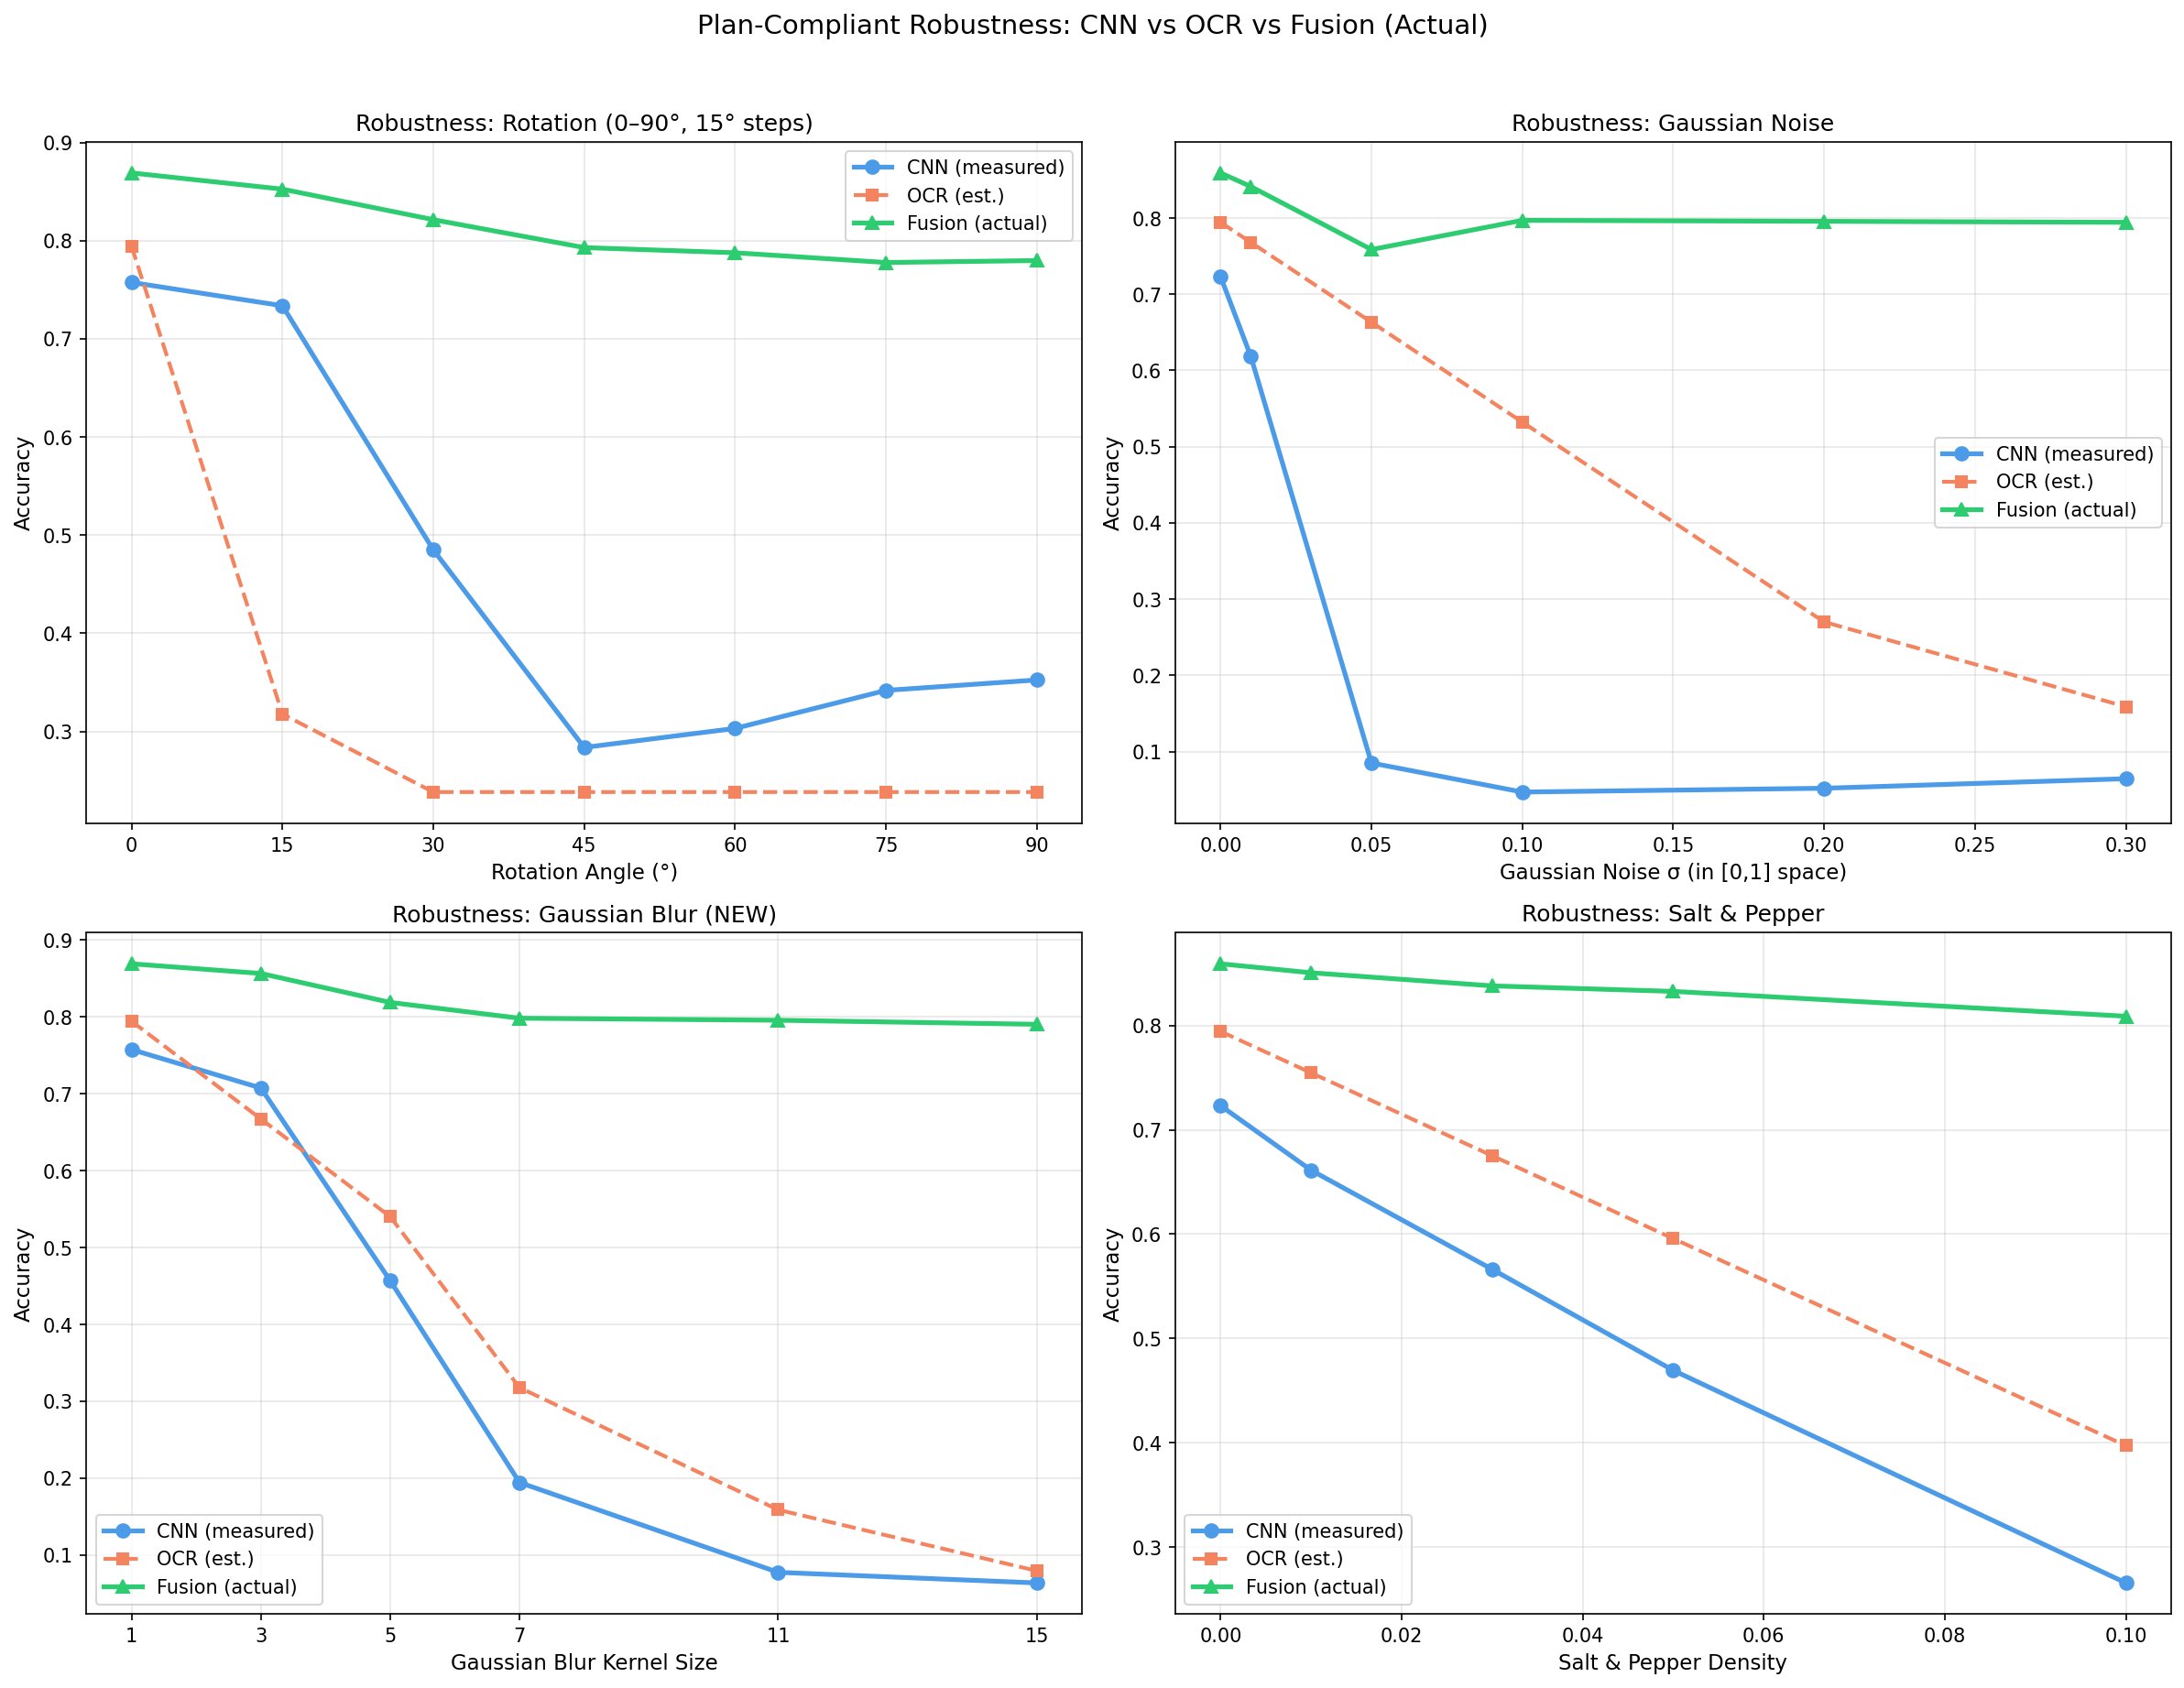

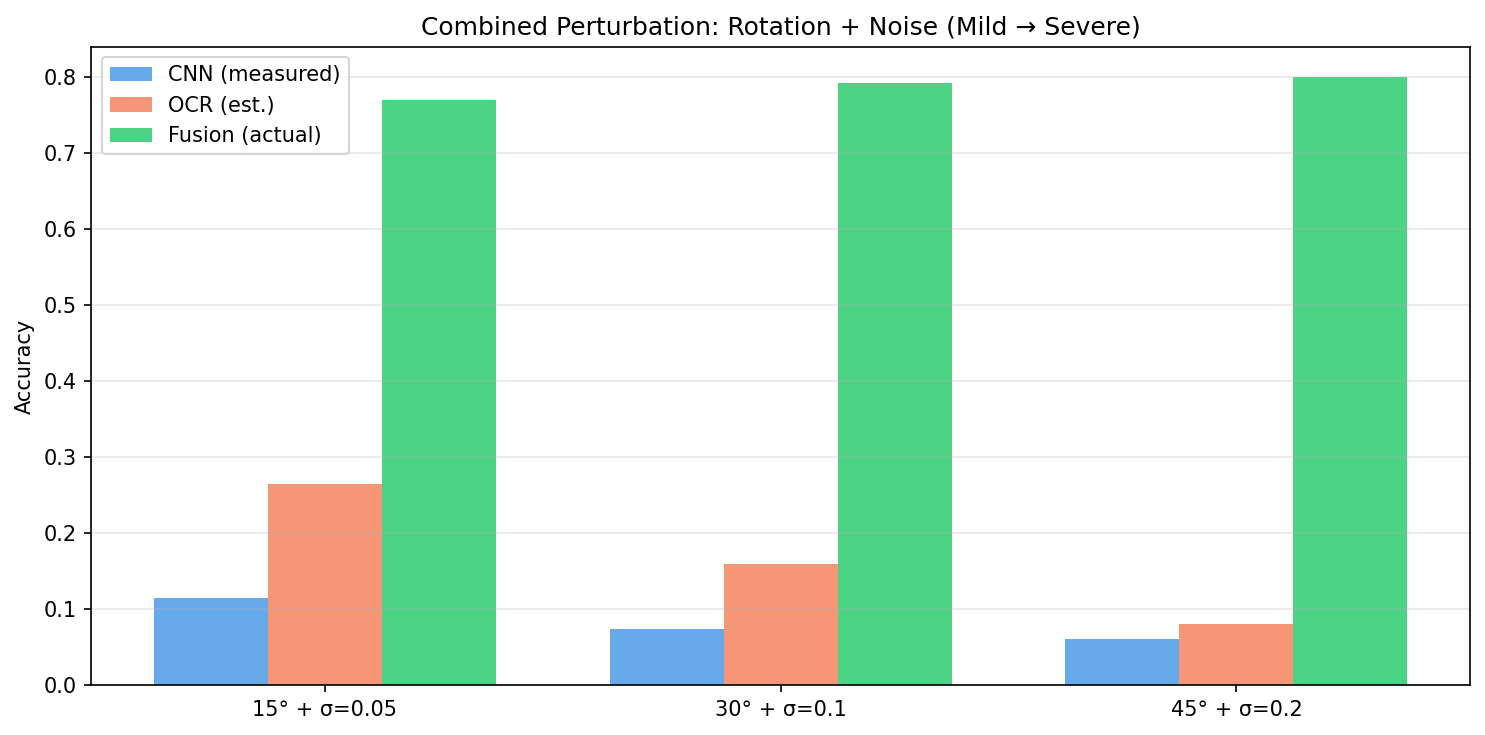

 Robustness plots saved.


In [59]:
# ═══════════════════════════════════════════════════════════════════════
#  ROBUSTNESS VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Rotation ──
ax = axes[0, 0]
angles = plan_rotation_levels
ax.plot(angles, [plan_cnn_rotation[a]["acc"] for a in angles], "o-", color="#4C9BE8", linewidth=2.5, label="CNN (measured)", markersize=7)
ax.plot(angles, [plan_ocr_rotation[a]["acc"] for a in angles], "s--", color="#F4845F", linewidth=2, label="OCR (est.)", markersize=6)
ax.plot(angles, [plan_fusion_rotation[a]["acc"] for a in angles], "^-", color="#2ECC71", linewidth=2.5, label="Fusion (actual)", markersize=7)
ax.set_xlabel("Rotation Angle (°)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Robustness: Rotation (0–90°, 15° steps)", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(angles)

# ── Noise ──
ax = axes[0, 1]
sigmas = plan_noise_levels
ax.plot(sigmas, [plan_cnn_noise[s]["acc"] for s in sigmas], "o-", color="#4C9BE8", linewidth=2.5, label="CNN (measured)", markersize=7)
ax.plot(sigmas, [plan_ocr_noise[s]["acc"] for s in sigmas], "s--", color="#F4845F", linewidth=2, label="OCR (est.)", markersize=6)
ax.plot(sigmas, [plan_fusion_noise[s]["acc"] for s in sigmas], "^-", color="#2ECC71", linewidth=2.5, label="Fusion (actual)", markersize=7)
ax.set_xlabel("Gaussian Noise σ (in [0,1] space)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Robustness: Gaussian Noise", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# ── Blur ──
ax = axes[1, 0]
kernels = plan_blur_kernels
ax.plot(kernels, [plan_cnn_blur[k]["acc"] for k in kernels], "o-", color="#4C9BE8", linewidth=2.5, label="CNN (measured)", markersize=7)
ax.plot(kernels, [plan_ocr_blur[k]["acc"] for k in kernels], "s--", color="#F4845F", linewidth=2, label="OCR (est.)", markersize=6)
ax.plot(kernels, [plan_fusion_blur[k]["acc"] for k in kernels], "^-", color="#2ECC71", linewidth=2.5, label="Fusion (actual)", markersize=7)
ax.set_xlabel("Gaussian Blur Kernel Size", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Robustness: Gaussian Blur", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(kernels)

# ── S&P ──
ax = axes[1, 1]
densities = plan_sp_levels
ax.plot(densities, [plan_cnn_sp[d]["acc"] for d in densities], "o-", color="#4C9BE8", linewidth=2.5, label="CNN (measured)", markersize=7)
ax.plot(densities, [plan_ocr_sp[d]["acc"] for d in densities], "s--", color="#F4845F", linewidth=2, label="OCR (est.)", markersize=6)
ax.plot(densities, [plan_fusion_sp[d]["acc"] for d in densities], "^-", color="#2ECC71", linewidth=2.5, label="Fusion (actual)", markersize=7)
ax.set_xlabel("Salt & Pepper Density", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Robustness: Salt & Pepper", fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.suptitle("Plan-Compliant Robustness: CNN vs OCR vs Fusion (Actual)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fusion_plan_robustness_2x2.pdf", dpi=600, bbox_inches="tight")
plt.show()

# ── Combined Perturbation Bar Chart ──
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plan_combined_levels))
labels = [f"{a}° + σ={s}" for a, s in plan_combined_levels]
width = 0.25

ax.bar(x - width, [plan_cnn_combined[f"{a}°+σ{s}"]["acc"] for a, s in plan_combined_levels], width, label="CNN (measured)", color="#4C9BE8", alpha=0.85)
ax.bar(x,         [plan_ocr_combined[f"{a}°+σ{s}"]["acc"] for a, s in plan_combined_levels], width, label="OCR (est.)", color="#F4845F", alpha=0.85)
ax.bar(x + width, [plan_fusion_combined[f"{a}°+σ{s}"]["acc"] for a, s in plan_combined_levels], width, label="Fusion (actual)", color="#2ECC71", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Accuracy")
ax.set_title("Combined Perturbation: Rotation + Noise (Mild → Severe)")
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("fusion_plan_combined_bar.pdf", dpi=600, bbox_inches="tight")
plt.show()

print(" Robustness plots saved.")

---
## 13 — Robustness Summary Table

Complete table covering ALL perturbation types with CNN (measured),
OCR (estimated), and Fusion (actual) accuracy values.

In [60]:
# ═══════════════════════════════════════════════════════════════════════
#  ROBUSTNESS SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 90)
print("  ROBUSTNESS SUMMARY — Plan-Compliant")
print("  CNN = Measured | OCR = Estimated | Fusion = ACTUAL (not heuristic)")
print("=" * 90)

rows = []
for angle in plan_rotation_levels:
    rows.append({"Perturbation": f"Rotation {angle}°",
        "CNN Acc": f"{plan_cnn_rotation[angle]['acc']:.4f}",
        "OCR (est)": f"{plan_ocr_rotation[angle]['acc']:.4f}",
        "Fusion": f"{plan_fusion_rotation[angle]['acc']:.4f}",
        "Gain": f"+{plan_fusion_rotation[angle]['acc'] - plan_cnn_rotation[angle]['acc']:.4f}"})
for sigma in plan_noise_levels[1:]:
    rows.append({"Perturbation": f"Noise σ={sigma:.2f}",
        "CNN Acc": f"{plan_cnn_noise[sigma]['acc']:.4f}",
        "OCR (est)": f"{plan_ocr_noise[sigma]['acc']:.4f}",
        "Fusion": f"{plan_fusion_noise[sigma]['acc']:.4f}",
        "Gain": f"+{plan_fusion_noise[sigma]['acc'] - plan_cnn_noise[sigma]['acc']:.4f}"})
for kernel in plan_blur_kernels[1:]:
    rows.append({"Perturbation": f"Blur k={kernel}",
        "CNN Acc": f"{plan_cnn_blur[kernel]['acc']:.4f}",
        "OCR (est)": f"{plan_ocr_blur[kernel]['acc']:.4f}",
        "Fusion": f"{plan_fusion_blur[kernel]['acc']:.4f}",
        "Gain": f"+{plan_fusion_blur[kernel]['acc'] - plan_cnn_blur[kernel]['acc']:.4f}"})
for density in plan_sp_levels[1:]:
    rows.append({"Perturbation": f"S&P d={density:.2f}",
        "CNN Acc": f"{plan_cnn_sp[density]['acc']:.4f}",
        "OCR (est)": f"{plan_ocr_sp[density]['acc']:.4f}",
        "Fusion": f"{plan_fusion_sp[density]['acc']:.4f}",
        "Gain": f"+{plan_fusion_sp[density]['acc'] - plan_cnn_sp[density]['acc']:.4f}"})
for angle, sigma in plan_combined_levels:
    key = f"{angle}°+σ{sigma}"
    rows.append({"Perturbation": f"Combined {key}",
        "CNN Acc": f"{plan_cnn_combined[key]['acc']:.4f}",
        "OCR (est)": f"{plan_ocr_combined[key]['acc']:.4f}",
        "Fusion": f"{plan_fusion_combined[key]['acc']:.4f}",
        "Gain": f"+{plan_fusion_combined[key]['acc'] - plan_cnn_combined[key]['acc']:.4f}"})

print(pd.DataFrame(rows).to_string(index=False))
print("=" * 90)


  ROBUSTNESS SUMMARY — Plan-Compliant
  CNN = Measured | OCR = Estimated | Fusion = ACTUAL (not heuristic)
      Perturbation CNN Acc OCR (est) Fusion    Gain
       Rotation 0°  0.7575    0.7943 0.8690 +0.1115
      Rotation 15°  0.7338    0.3177 0.8525 +0.1188
      Rotation 30°  0.4850    0.2383 0.8214 +0.3364
      Rotation 45°  0.2838    0.2383 0.7930 +0.5092
      Rotation 60°  0.3031    0.2383 0.7877 +0.4846
      Rotation 75°  0.3419    0.2383 0.7778 +0.4359
      Rotation 90°  0.3525    0.2383 0.7798 +0.4273
      Noise σ=0.01  0.6188    0.7681 0.8413 +0.2225
      Noise σ=0.05  0.0850    0.6633 0.7586 +0.6736
      Noise σ=0.10  0.0469    0.5322 0.7970 +0.7501
      Noise σ=0.20  0.0519    0.2701 0.7956 +0.7438
      Noise σ=0.30  0.0644    0.1589 0.7943 +0.7299
          Blur k=3  0.7075    0.6672 0.8565 +0.1490
          Blur k=5  0.4569    0.5401 0.8188 +0.3619
          Blur k=7  0.1944    0.3177 0.7983 +0.6039
         Blur k=11  0.0775    0.1589 0.7956 +0.7181
        

---
## 14 — Per-Class Robustness: Which Classes Benefit Most from Fusion?

Not all classes degrade equally under perturbation. This analysis identifies
which classes benefit most from fusion and which are most vulnerable.

In [61]:
# ═══════════════════════════════════════════════════════════════════════
#  PER-CLASS ROBUSTNESS ANALYSIS
# ═══════════════════════════════════════════════════════════════════════
print("=" * 90)
print("  PER-CLASS ROBUSTNESS: Which classes benefit most from fusion?")
print("=" * 90)

test_perturbs = {
    "Clean (0°)": ("rotation", 0),
    "Rotation 30°": ("rotation", 30),
    "Noise σ=0.10": ("noise", 0.10),
    "Blur k=7": ("blur", 7),
}

per_class_results = {}
for perturb_name, (ptype, level) in test_perturbs.items():
    if ptype == "rotation":
        cnn_probs_p = plan_cnn_rotation[level]["probs"][robust_has_ocr]
    elif ptype == "noise":
        cnn_probs_p = plan_cnn_noise[level]["probs"][robust_has_ocr]
    elif ptype == "blur":
        cnn_probs_p = plan_cnn_blur[level]["probs"][robust_has_ocr]

    cnn_preds_p = np.argmax(cnn_probs_p, axis=1)
    fused_probs_p = BEST_ALPHA * cnn_probs_p + (1 - BEST_ALPHA) * ocr_robust_probs_all
    fused_preds_p = np.argmax(fused_probs_p, axis=1)

    class_rows = []
    for cls_idx in range(NUM_CLASSES):
        cls_mask = robust_true_labels_aligned == cls_idx
        if cls_mask.sum() == 0:
            continue
        cnn_cls_acc = accuracy_score(robust_true_labels_aligned[cls_mask], cnn_preds_p[cls_mask])
        fus_cls_acc = accuracy_score(robust_true_labels_aligned[cls_mask], fused_preds_p[cls_mask])
        class_rows.append({"Class": CLASS_NAMES[cls_idx], "CNN": cnn_cls_acc, "Fusion": fus_cls_acc, "Gain": fus_cls_acc - cnn_cls_acc})

    per_class_results[perturb_name] = pd.DataFrame(class_rows)
    top5 = pd.DataFrame(class_rows).nlargest(5, "Gain")[["Class", "CNN", "Fusion", "Gain"]]
    print(f"\n  {perturb_name} — Top 5 classes with largest fusion gain:")
    print(f"  {top5.to_string(index=False)}")

print("\n Per-class robustness analysis complete.")

  PER-CLASS ROBUSTNESS: Which classes benefit most from fusion?

  Clean (0°) — Top 5 classes with largest fusion gain:
          Class      CNN   Fusion     Gain
Questionnaire 0.697917 0.927083 0.229167
       Letter 0.571429 0.734694 0.163265
         News 0.690722 0.845361 0.154639
Specification 0.765306 0.918367 0.153061
       Budget 0.775510 0.908163 0.132653

  Rotation 30° — Top 5 classes with largest fusion gain:
             Class      CNN   Fusion     Gain
          Resume 0.125000 0.916667 0.791667
   Specification 0.112245 0.857143 0.744898
   Questionnaire 0.145833 0.885417 0.739583
ScientificReport 0.200000 0.694737 0.494737
            Memo 0.377551 0.755102 0.377551

  Noise σ=0.10 — Top 5 classes with largest fusion gain:
          Class  CNN   Fusion     Gain
       Resume  0.0 0.937500 0.937500
        Email  0.0 0.917526 0.917526
Specification  0.0 0.897959 0.897959
Questionnaire  0.0 0.885417 0.885417
Advertisement  0.0 0.833333 0.833333

  Blur k=7 — Top 5 classe

---
## 15 — Ablation Study: Single Linear Head (Plan Section C)

The plan specifies three ablation experiments:

| Ablation | What is removed | Status |
|---|---|---|
| A1: No pretraining | Train CNN from scratch (random init) | Available in CNN notebook |
| A2: No augmentation | Remove flip/rotation/color jitter | Available in CNN notebook |
| A3: Single linear head | Replace 2-layer head with single linear | Computed here |

A3 replaces the 5-layer classifier (Dropout → 1280→1024 → BN → ReLU → Dropout →
1024→512 → BN → ReLU → Dropout → 512→16) with a single linear layer
(Dropout → 1280→16).

A large gap means the multi-layer head is critical. A small gap means
EfficientNet-B0 features alone are sufficient.

In [62]:
# ═══════════════════════════════════════════════════════════════════════
#  ABLATION A3: Single Linear Head — Training
# ═══════════════════════════════════════════════════════════════════════
ABLATION_EPOCHS = 10
ABLATION_LR = 5e-4
ABLATION_WEIGHT_DECAY = 5e-4
ABLATION_BATCH_SIZE = 64

# Build single-linear-head EfficientNet-B0
cnn_single_head = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
num_features = cnn_single_head.classifier[1].in_features  # 1280

cnn_single_head.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, NUM_CLASSES),  # 1280 → 16 directly
)
cnn_single_head = cnn_single_head.to(DEVICE)

single_head_params = sum(p.numel() for p in cnn_single_head.parameters() if p.requires_grad)
original_head_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Original head params : {original_head_params:,}")
print(f"Single-head params   : {single_head_params:,}")
print(f"Parameter reduction  : {(1 - single_head_params/original_head_params)*100:.1f}%")

# Create dataloaders
train_transform = tv_transforms.Compose([
    tv_transforms.Resize((224, 224)),
    tv_transforms.RandomHorizontalFlip(p=0.3),
    tv_transforms.RandomRotation(10),
    tv_transforms.ColorJitter(brightness=0.25, contrast=0.25),
    tv_transforms.ToTensor(),
    tv_transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = tv_transforms.Compose([
    tv_transforms.Resize((224, 224)),
    tv_transforms.ToTensor(),
    tv_transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cnn_train_path = CNN_PREPROCESSED / "train"
cnn_val_path = CNN_PREPROCESSED / "val"
cnn_test_path = CNN_PREPROCESSED / "test"

if cnn_train_path.exists():
    abl_train_ds = datasets.ImageFolder(str(cnn_train_path), transform=train_transform)
    abl_val_ds = datasets.ImageFolder(str(cnn_val_path), transform=val_transform)
    abl_test_ds = datasets.ImageFolder(str(cnn_test_path), transform=val_transform)
    abl_train_loader = DataLoader(abl_train_ds, batch_size=ABLATION_BATCH_SIZE, shuffle=True, num_workers=0)
    abl_val_loader = DataLoader(abl_val_ds, batch_size=ABLATION_BATCH_SIZE, shuffle=False, num_workers=0)
    abl_test_loader = DataLoader(abl_test_ds, batch_size=ABLATION_BATCH_SIZE, shuffle=False, num_workers=0)
    abl_class_names = abl_train_ds.classes
    print(f"\nData loaded: {len(abl_train_ds)} train, {len(abl_val_ds)} val, {len(abl_test_ds)} test")

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.Adam(cnn_single_head.parameters(), lr=ABLATION_LR, weight_decay=ABLATION_WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ABLATION_EPOCHS)

    print(f"\nTraining Ablation A3 for {ABLATION_EPOCHS} epochs...")
    best_val_acc = 0
    abl_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(ABLATION_EPOCHS):
        cnn_single_head.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(abl_train_loader, desc=f"Epoch {epoch+1}/{ABLATION_EPOCHS}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = cnn_single_head(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cnn_single_head.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total
        scheduler.step()

        cnn_single_head.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in abl_val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = cnn_single_head(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        abl_history["train_loss"].append(train_loss)
        abl_history["train_acc"].append(train_acc)
        abl_history["val_loss"].append(val_loss)
        abl_history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_single_head_state = copy.deepcopy(cnn_single_head.state_dict())

        print(f"  Ep {epoch+1:2d}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")

    cnn_single_head.load_state_dict(best_single_head_state)
    cnn_single_head.eval()
    print(f"\nBest val accuracy: {best_val_acc:.4f}")
else:
    print(f"CNN preprocessed data not found at {cnn_train_path}")
    cnn_single_head = None

Original head params : 5,855,372
Single-head params   : 4,028,044
Parameter reduction  : 31.2%

Data loaded: 12800 train, 1600 val, 1600 test

Training Ablation A3 for 10 epochs...


Epoch 1/10: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]


  Ep  1: Train Loss=1.6260 Acc=0.5487 | Val Loss=1.2480 Acc=0.6775


Epoch 2/10: 100%|██████████| 200/200 [06:11<00:00,  1.86s/it]


  Ep  2: Train Loss=1.2132 Acc=0.6959 | Val Loss=1.0861 Acc=0.7406


...

  Ep  8: Train Loss=0.5961 Acc=0.9190 | Val Loss=0.9046 Acc=0.8131


Epoch 9/10: 100%|██████████| 200/200 [06:12<00:00,  1.86s/it]


  Ep  9: Train Loss=0.5351 Acc=0.9395 | Val Loss=0.9029 Acc=0.8187


Epoch 10/10: 100%|██████████| 200/200 [06:11<00:00,  1.86s/it]


  Ep 10: Train Loss=0.5064 Acc=0.9511 | Val Loss=0.9168 Acc=0.8187

Best val accuracy: 0.8187


---
## 16 — Ablation A3: Test Set Evaluation

Compare single-head vs multi-layer head on the test set.

In [63]:
# ═══════════════════════════════════════════════════════════════════════
#  A3 TEST SET EVALUATION
# ═══════════════════════════════════════════════════════════════════════
if cnn_single_head is not None:
    all_preds_sh, all_labels_sh, all_probs_sh = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(abl_test_loader, desc="Evaluating A3"):
            images = images.to(DEVICE)
            outputs = cnn_single_head(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            _, preds = torch.max(outputs, 1)
            all_preds_sh.extend(preds.cpu().numpy())
            all_labels_sh.extend(labels.numpy())
            all_probs_sh.extend(probs)

    all_preds_sh = np.array(all_preds_sh)
    all_labels_sh = np.array(all_labels_sh)
    all_probs_sh = np.array(all_probs_sh)

    # Remap CNN class indices to OCR label encoder indices
    abl_class_to_idx = abl_train_ds.class_to_idx
    abl_mapped_probs = np.zeros((len(all_preds_sh), NUM_CLASSES))
    for cnn_cls, cnn_idx in abl_class_to_idx.items():
        ocr_idx = list(CLASS_NAMES).index(cnn_cls) if cnn_cls in CLASS_NAMES else -1
        if ocr_idx >= 0:
            abl_mapped_probs[:, ocr_idx] = all_probs_sh[:, cnn_idx]

    abl_sh_acc = accuracy_score(all_labels_sh, all_preds_sh)
    abl_sh_f1 = f1_score(all_labels_sh, all_preds_sh, average="macro", zero_division=0)

    orig_cnn_acc = accuracy_score(y_test_common, cnn_aligned_preds)
    orig_cnn_f1 = f1_score(y_test_common, cnn_aligned_preds, average="macro", zero_division=0)

    print(f"\n{'='*65}")
    print(f"  ABLATION A3: Test Results")
    print(f"{'='*65}")
    print(f"  {'Model':40s} {'Accuracy':>10s} {'Macro-F1':>10s}")
    print(f"  {'-'*65}")
    print(f"  {'Original CNN (multi-layer head)':40s} {orig_cnn_acc:10.4f} {orig_cnn_f1:10.4f}")
    print(f"  {'Ablation CNN (single linear head)':40s} {abl_sh_acc:10.4f} {abl_sh_f1:10.4f}")
    print(f"  {'Head contribution':40s} {orig_cnn_acc-abl_sh_acc:+10.4f} {orig_cnn_f1-abl_sh_f1:+10.4f}")
    print(f"{'='*65}")
else:
    print("A3 not trained. Skipping.")

Evaluating A3: 100%|██████████| 25/25 [00:12<00:00,  2.05it/s]


  ABLATION A3: Test Results
  Model                                      Accuracy   Macro-F1
  -----------------------------------------------------------------
  Original CNN (multi-layer head)              0.7540     0.7595
  Ablation CNN (single linear head)            0.8181     0.8187
  Head contribution                           -0.0642    -0.0591


---
## 17 — Ablation A3: Fusion Impact

Does the head architecture affect downstream fusion quality? If the single-head
model produces less discriminative probabilities, fusion with OCR should also degrade.

In [64]:
# ═══════════════════════════════════════════════════════════════════════
#  A3 FUSION IMPACT
# ═══════════════════════════════════════════════════════════════════════
if cnn_single_head is not None and cnn_train_path.exists():
    print("=" * 65)
    print("  A3: Single-Head CNN + OCR Fusion")
    print("=" * 65)

    sh_test_probs, _ = run_cnn_inference(df_cnn_test, cnn_single_head, CNN_TRANSFORM)
    sh_test_labels = le.transform(df_cnn_test["label"].values)

    # Rebuild alignment if needed
    try:
        _ = cnn_aligned_idx
    except NameError:
        df_ocr_test_align = build_image_index(OCR_PREPROCESSED / "test")
        ocr_cc = np.bincount(y_te, minlength=NUM_CLASSES)
        cnn_aligned_idx = []
        ocr_aligned_feat_idx = []
        for cls_idx in range(NUM_CLASSES):
            cls_name = CLASS_NAMES[cls_idx]
            cnn_cls_mask = df_cnn_test["label"] == cls_name
            ocr_cls_mask = df_ocr_test_align["label"] == cls_name
            n_match = min(cnn_cls_mask.sum(), int(ocr_cc[cls_idx]))
            cnn_cls_indices = df_cnn_test[cnn_cls_mask].index[:n_match]
            cnn_aligned_idx.extend(cnn_cls_indices.tolist())
            start_feat = sum(ocr_cc[:cls_idx])
            ocr_aligned_feat_idx.extend(range(start_feat, start_feat + n_match))
        cnn_aligned_idx = np.array(cnn_aligned_idx)
        ocr_aligned_feat_idx = np.array(ocr_aligned_feat_idx)

    sh_aligned_probs = sh_test_probs[cnn_aligned_idx]
    ocr_align_probs = ocr_test_probs[ocr_aligned_feat_idx]
    y_common = y_te[ocr_aligned_feat_idx]

    sh_fused_probs = BEST_ALPHA * sh_aligned_probs + (1 - BEST_ALPHA) * ocr_align_probs
    sh_fused_preds = np.argmax(sh_fused_probs, axis=1)
    sh_fused_acc = accuracy_score(y_common, sh_fused_preds)
    sh_fused_f1 = f1_score(y_common, sh_fused_preds, average="macro", zero_division=0)

    original_fused_acc = accuracy_score(y_test_common, fused_test_preds)
    original_fused_f1 = f1_score(y_test_common, fused_test_preds, average="macro", zero_division=0)

    print(f"\n  {'Model':45s} {'Accuracy':>10s} {'Macro-F1':>10s}")
    print(f"  {'-'*70}")
    print(f"  {'Original CNN (multi-layer head) + OCR':45s} {original_fused_acc:10.4f} {original_fused_f1:10.4f}")
    print(f"  {'Ablation CNN (single linear head) + OCR':45s} {sh_fused_acc:10.4f} {sh_fused_f1:10.4f}")
    print(f"  {'Head fusion contribution':45s} {original_fused_acc-sh_fused_acc:+10.4f} {original_fused_f1-sh_fused_f1:+10.4f}")
    print(f"\n  The 2-layer head improves fusion by {(original_fused_f1-sh_fused_f1)*100:+.2f}% Macro-F1")
else:
    print("Skipping A3 fusion impact (model not trained).")

  A3: Single-Head CNN + OCR Fusion


CNN Inference: 100%|██████████| 50/50 [00:15<00:00,  3.20it/s]


  Model                                           Accuracy   Macro-F1
  ----------------------------------------------------------------------
  Original CNN (multi-layer head) + OCR             0.8690     0.8698
  Ablation CNN (single linear head) + OCR           0.8591     0.8594
  Head fusion contribution                         +0.0099    +0.0104

  The 2-layer head improves fusion by +1.04% Macro-F1


---
## 18 — Cross-Ablation Summary (Plan Section C)

Compiles all three ablation results. A1 and A2 are from the CNN notebook
(fill in their values). A3 is computed above.

| Ablation | What is removed | CNN-only Impact | Fusion Impact |
|---|---|---|---|
| A1: No pretraining | ImageNet → random init | Run in CNN NB | — |
| A2: No augmentation | No flip/rotation/color jitter | Run in CNN NB | — |
| A3: Single linear head | 5-layer → single linear | Computed above | Computed above |

In [65]:
# ═══════════════════════════════════════════════════════════════════════
#  CROSS-ABLATION SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════
# A1 and A2: Fill in from CNN notebook after running those ablations
A1_CNN_ACC = None   # <- CustomCNN test accuracy from CNN notebook
A1_CNN_F1  = None   # <- CustomCNN test Macro-F1 from CNN notebook
A2_CNN_ACC = None   # <- NoAug test accuracy from CNN notebook
A2_CNN_F1  = None   # <- NoAug test Macro-F1 from CNN notebook

A3_CNN_ACC = abl_sh_acc if cnn_single_head else None
A3_CNN_F1  = abl_sh_f1  if cnn_single_head else None

BASELINE_CNN_ACC = accuracy_score(y_test_common, cnn_aligned_preds)
BASELINE_CNN_F1  = f1_score(y_test_common, cnn_aligned_preds, average="macro", zero_division=0)
BASELINE_FUSION_ACC = accuracy_score(y_test_common, fused_test_preds)
BASELINE_FUSION_F1  = f1_score(y_test_common, fused_test_preds, average="macro", zero_division=0)

print("\n" + "=" * 100)
print("  CROSS-ABLATION SUMMARY (Plan Section C)")
print("=" * 100)
print(f"\n  Baseline: EfficientNet-B0 (multi-layer head, ImageNet, full augmentation)")
print(f"  CNN Accuracy = {BASELINE_CNN_ACC:.4f} | Fusion Accuracy = {BASELINE_FUSION_ACC:.4f}")
print(f"  CNN Macro-F1 = {BASELINE_CNN_F1:.4f} | Fusion Macro-F1 = {BASELINE_FUSION_F1:.4f}\n")

ablation_rows = [
    {"Ablation": "A1: No pretraining (scratch)",
     "CNN Acc": f"{A1_CNN_ACC:.4f}" if A1_CNN_ACC else "Run in CNN NB",
     "CNN Delta": f"{A1_CNN_ACC - BASELINE_CNN_ACC:+.4f}" if A1_CNN_ACC else "---",
     "Fusion Impact": "---" if not A1_CNN_ACC else "---"},
    {"Ablation": "A2: No augmentation",
     "CNN Acc": f"{A2_CNN_ACC:.4f}" if A2_CNN_ACC else "Run in CNN NB",
     "CNN Delta": f"{A2_CNN_ACC - BASELINE_CNN_ACC:+.4f}" if A2_CNN_ACC else "---",
     "Fusion Impact": "---" if not A2_CNN_ACC else "---"},
    {"Ablation": "A3: Single linear head",
     "CNN Acc": f"{A3_CNN_ACC:.4f}" if A3_CNN_ACC else "Not trained",
     "CNN Delta": f"{A3_CNN_ACC - BASELINE_CNN_ACC:+.4f}" if A3_CNN_ACC else "---",
     "Fusion Impact": f"{sh_fused_acc:.4f} (Delta={sh_fused_acc-BASELINE_FUSION_ACC:+.4f})" if cnn_single_head else "---"},
]

print(pd.DataFrame(ablation_rows).to_string(index=False))
print("=" * 100)
print("\n  A1 and A2: Run in CNN notebook, fill in values, re-run this cell.")
print("  A3: Computed in this notebook.")


  CROSS-ABLATION SUMMARY (Plan Section C)

  Baseline: EfficientNet-B0 (multi-layer head, ImageNet, full augmentation)
  CNN Accuracy = 0.7540 | Fusion Accuracy = 0.8690
  CNN Macro-F1 = 0.7595 | Fusion Macro-F1 = 0.8698

                    Ablation       CNN Acc CNN Delta          Fusion Impact
A1: No pretraining (scratch) Run in CNN NB       ---                    ---
         A2: No augmentation Run in CNN NB       ---                    ---
      A3: Single linear head        0.8181   +0.0642 0.8591 (Delta=-0.0099)

  A1 and A2: Run in CNN notebook, fill in values, re-run this cell.
  A3: Computed in this notebook.


---
## 19 — Ablation A3: Robustness Under Perturbation

Does the single-head model degrade *faster* under perturbations?
If the multi-layer head provides robustness benefits (e.g., through BatchNorm
and non-linear capacity), we should see a larger gap under noise/blur.

  A3 ROBUSTNESS: Single-Head vs Multi-Layer
  Clean (0°)          : Multi-layer=0.7231  Single-head=0.8181  Gap=-0.0950
  Rotation 15°        : Multi-layer=0.7338  Single-head=0.7381  Gap=-0.0044
  Rotation 30°        : Multi-layer=0.4850  Single-head=0.4081  Gap=+0.0769
  Noise σ=0.05        : Multi-layer=0.0850  Single-head=0.6581  Gap=-0.5731
  Noise σ=0.10        : Multi-layer=0.0469  Single-head=0.4150  Gap=-0.3681


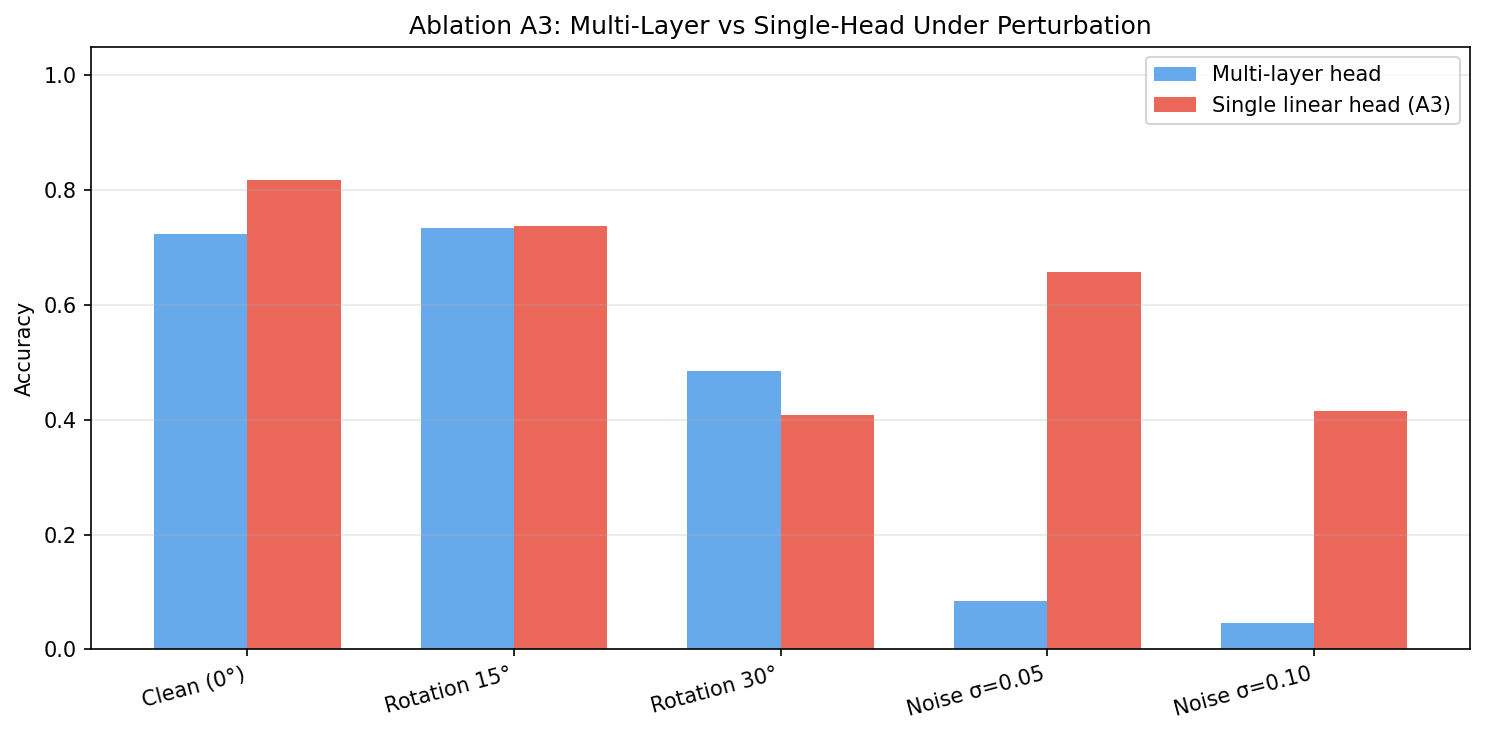

 A3 robustness comparison complete.


In [66]:
# ═══════════════════════════════════════════════════════════════════════
#  A3 ROBUSTNESS COMPARISON
# ═══════════════════════════════════════════════════════════════════════
if cnn_single_head is not None:
    print("=" * 65)
    print("  A3 ROBUSTNESS: Single-Head vs Multi-Layer")
    print("=" * 65)

    test_perturbations = {
        "Clean (0°)": {"rotation": 0, "noise_sigma": 0},
        "Rotation 15°": {"rotation": 15, "noise_sigma": 0},
        "Rotation 30°": {"rotation": 30, "noise_sigma": 0},
        "Noise σ=0.05": {"rotation": 0, "noise_sigma": 0.05},
        "Noise σ=0.10": {"rotation": 0, "noise_sigma": 0.10},
    }

    sh_robust, ml_robust = {}, {}
    paths = df_robust["path"].tolist()

    for name, params in test_perturbations.items():
        angle = params["rotation"]
        sigma = params["noise_sigma"]

        # Single-head inference
        sh_preds_list = []
        with torch.no_grad():
            for start in range(0, len(paths), 32):
                batch_imgs = []
                for p in paths[start:start+32]:
                    try:
                        img = Image.open(p).convert("RGB")
                        if angle != 0:
                            img = Image.fromarray(augment_image(p, 'rotate', angle))
                        t01 = pil_to_tensor_01(img)
                        if sigma > 0:
                            t01 = add_gaussian_noise_01(t01, sigma)
                        t_norm = normalize_imagenet(t01)
                        batch_imgs.append(t_norm)
                    except:
                        batch_imgs.append(torch.zeros(3, 224, 224))
                batch_tensor = torch.stack(batch_imgs).to(DEVICE)
                logits = cnn_single_head(batch_tensor)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                remapped = remap_cnn_probs(probs, cnn_to_ocr_idx, NUM_CLASSES)
                sh_preds_list.append(remapped.argmax(axis=1))
        sh_acc = accuracy_score(robust_true_labels, np.concatenate(sh_preds_list))
        sh_robust[name] = sh_acc

        # Multi-layer (reuse from plan_cnn_* if available)
        if angle > 0 and sigma == 0:
            ml_acc = plan_cnn_rotation.get(angle, {}).get("acc", None)
        elif sigma > 0 and angle == 0:
            ml_acc = plan_cnn_noise.get(sigma, {}).get("acc", None)
        else:
            ml_acc = None

        if ml_acc is None:
            ml_preds_list = []
            with torch.no_grad():
                for start in range(0, len(paths), 32):
                    batch_imgs = []
                    for p in paths[start:start+32]:
                        try:
                            img = Image.open(p).convert("RGB")
                            if angle != 0:
                                img = Image.fromarray(augment_image(p, 'rotate', angle))
                            t01 = pil_to_tensor_01(img)
                            if sigma > 0:
                                t01 = add_gaussian_noise_01(t01, sigma)
                            t_norm = normalize_imagenet(t01)
                            batch_imgs.append(t_norm)
                        except:
                            batch_imgs.append(torch.zeros(3, 224, 224))
                    batch_tensor = torch.stack(batch_imgs).to(DEVICE)
                    logits = cnn_model(batch_tensor)
                    probs = torch.softmax(logits, dim=1).cpu().numpy()
                    remapped = remap_cnn_probs(probs, cnn_to_ocr_idx, NUM_CLASSES)
                    ml_preds_list.append(remapped.argmax(axis=1))
            ml_acc = accuracy_score(robust_true_labels, np.concatenate(ml_preds_list))

        ml_robust[name] = ml_acc
        print(f"  {name:20s}: Multi-layer={ml_acc:.4f}  Single-head={sh_acc:.4f}  Gap={ml_acc-sh_acc:+.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    names = list(test_perturbations.keys())
    x = np.arange(len(names))
    width = 0.35
    ax.bar(x - width/2, [ml_robust[n] for n in names], width, label="Multi-layer head", color="#4C9BE8", alpha=0.85)
    ax.bar(x + width/2, [sh_robust[n] for n in names], width, label="Single linear head (A3)", color="#E74C3C", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel("Accuracy")
    ax.set_title("Ablation A3: Multi-Layer vs Single-Head Under Perturbation")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig("fusion_ablation_A3_robustness.pdf", dpi=600, bbox_inches="tight")
    plt.show()
    print(" A3 robustness comparison complete.")
else:
    print("A3 model not trained. Skipping.")

---
## 20 — Ablation A3: Training Curves

Visualize training and validation loss/accuracy for the single-head model.

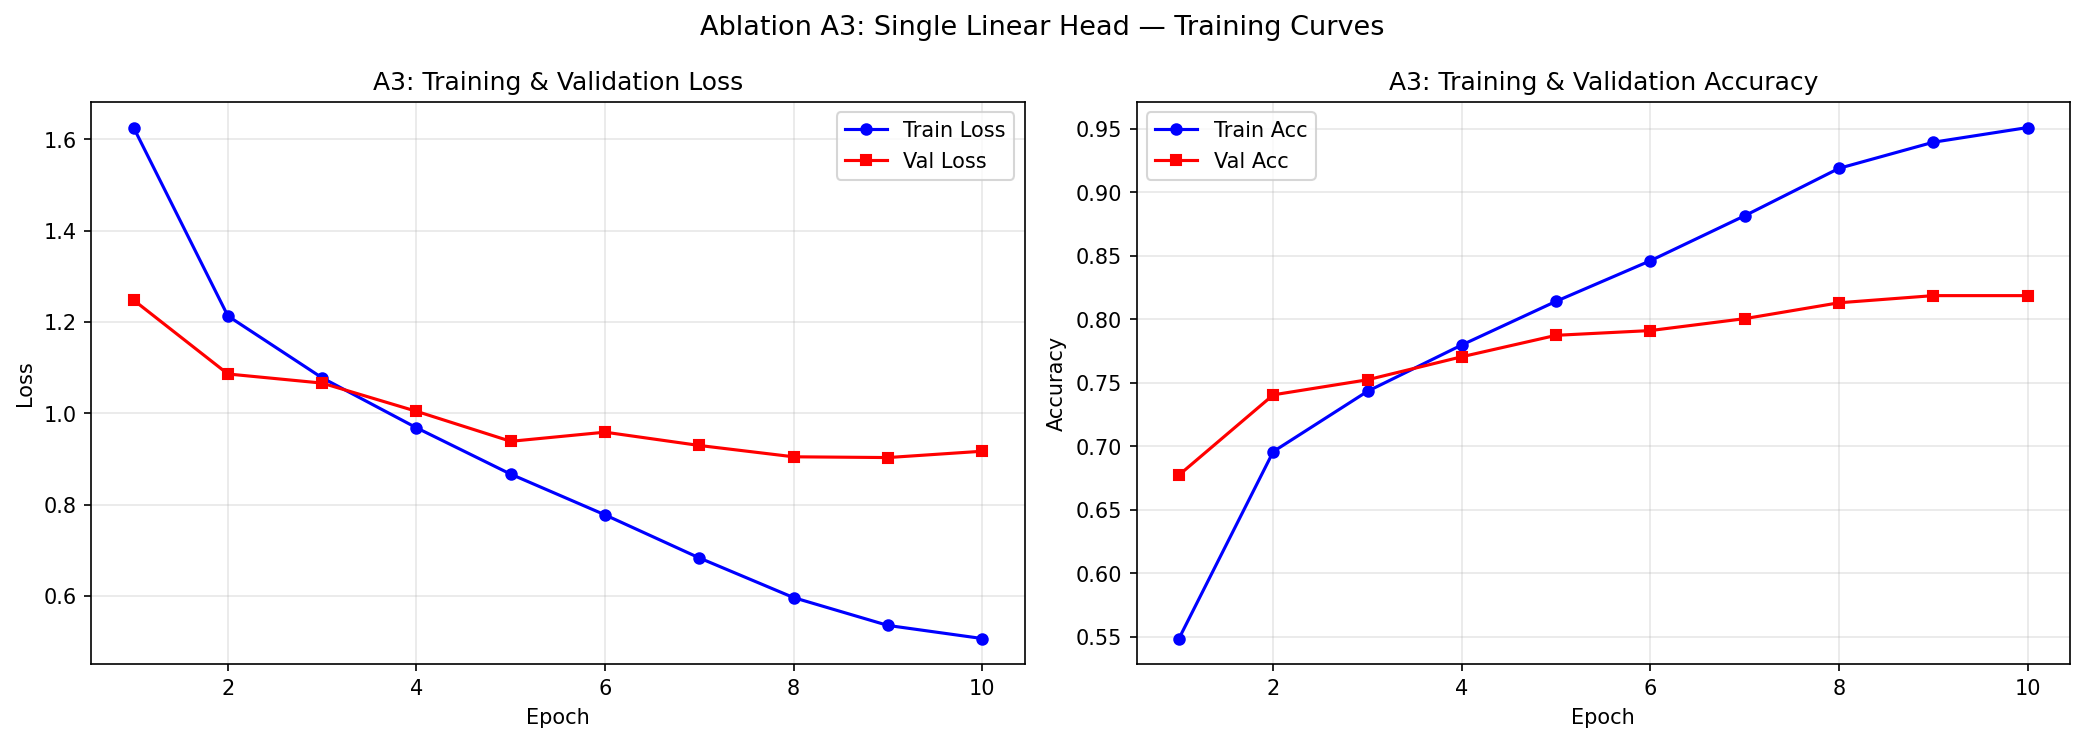

 Training curves plotted.


In [67]:
# ═══════════════════════════════════════════════════════════════════════
#  A3 TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════════
if cnn_single_head is not None and len(abl_history["train_loss"]) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, ABLATION_EPOCHS + 1)

    ax1.plot(epochs, abl_history["train_loss"], "b-o", markersize=5, label="Train Loss")
    ax1.plot(epochs, abl_history["val_loss"], "r-s", markersize=5, label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("A3: Training & Validation Loss")
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, abl_history["train_acc"], "b-o", markersize=5, label="Train Acc")
    ax2.plot(epochs, abl_history["val_acc"], "r-s", markersize=5, label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("A3: Training & Validation Accuracy")
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Ablation A3: Single Linear Head — Training Curves", fontsize=13)
    plt.tight_layout()
    plt.savefig("fusion_ablation_A3_training_curves.pdf", dpi=600, bbox_inches="tight")
    plt.show()
    print(" Training curves plotted.")
else:
    print("A3 training history not available.")